# <center> K-Means Clustering - Allrecipes.com <center>

### Question:
> How effectively can K-Means clustering be applied to segment recipes, based on macronutrient composition and total recipe recreation time, to support time-constrained individuals in making nutritionally informed choices?
***


In this project I set out to explore **how effectively K-Means clustering can segment recipes, based on macronutrient composition and total recipe recreation time, to support time-constrained individuals in making nutritionally informed choices**. I worked with a dataset of scraped Allrecipes.com recipe submissions to combine behavioural variables (*active and passive time*), proportional macronutrient values and serving size to identify meaningful recipe groupings.

I carried out extensive exploratory data analysis (EDA) and data cleansing which included handling missing values, removal of implausible entries, and exclusion of extreme macronutrient outliers. I created behavioural time features (*active and passive time*), resulting in the production of a final dataset of **13,659** recipes. Most feature selection and data manipulation took place during this early exploratory stage of the project, prior to scaling and modelling, with additional optimisation conducted during the model development, where I tested a variety of feature combinations and *k*-values.

After scaling the numeric variables and evaluating multiple configurations using inertia, silhouette scores and Principal Component Analysis (PCA), I found that ***k = 5*** using **6** feature columns produced the best balance of interpretability and performance, this included the addition of serving size into the model which was initially an unexpected behavioural pattern on top of the original project's intention. As I noted in the full report, this setup gave enough clusters to answer the question while still producing coherent, meaningful groups. The resulting clusters captured clear behavioural and nutritional patterns reflected in the key components of time investment (quick vs slow vs multi-week), recipe-size (everyday meals vs large-scale preserves), macronutrient structure (low-carb/high-protein vs high-carb desserts) and culinary style (Mediterranean foods, comfort foods and preserved foods), reflecting predictable clustering structure rather than random variation. This process allowed me to develop a list of cluster theme keywords which I then attached to the dataframe, these keywords could be used in many ways for developing tools for the website users, discussed below.

To validate themes, I manually reviewed **5** recipes per cluster against their Allrecipes.com recipe pages. Four clusters showed very strong alignment with minor overlap where recipes shared similar structural features. This confirmed that the clusters were robust, interpretable and grounded in real cooking behaviour (time-taken, macronutrient content and recipe size).

These results show that the clusters could support potential practical applications for the marketing department as well as users of large cooking platforms, for example enabling the provision of **personalised recipe recommendations** based on a user's saved/favourited/reviewed recipes, similar to playlist-style systems used by Spotify or suggested shopping items used by Amazon. The clustering model could also be used to provide **meal-planning tools, nutritional guidance or automatic tagging**, grouping similar recipes together on the site by using the profile of the recipes rather than user suggested groupings given in the submissions.

There are limitations to this modelling process which include:
- missing time fields that are available on the website but not in the scraped data,
- the assumptions of K-Means,
- the loss of nuance in PCA,
- and the fact that macronutrient percentages don't reflect absolute values.

This project demonstrates that K-Means can successfully segment recipes into meaningful behavioural and nutritional groups, providing a strong foundation for improving recipe discovery by users and personalisation in recipe recommendation on large cooking platforms.
***
<br>
<br>

#### What is K-Means Clustering?
*[Massaron and Mueller (2025)](https://learning.oreilly.com/library/view/machine-learning-for/9781394373222/)* describe K-Means clustering as an unsupervised learning algorithm designed to divide a population of data items, placing similar data items together into groups/clusters. The value of *k* describes the number of clusters/groups, and therefore the number of cluster centroids, each representing the mean position of the data items within that cluster. The algorithm repeatedly assigns each data item to the nearest centroid and then recalculates the centroids based on the updated assignment of data items to centroids. This process cycles continuously, iterating through the recalculation of clusters and centroids until the model stabilises and settles on a distribution. The goal of K-Means clustering is to produce clusters such that data items within each cluster are closer to the centroid of their own cluster than to the centroids of other clusters. To find the optimal value for *k* in this analysis the elbow and silhouette methods will be used but first the data will be loaded, explored and cleansed.

***
<br>

## 1. Libraries, Data Loading and Helper Functions

In [1]:
# Standard library
import os                                         # File and directory operations
import sys                                        # Gives access to Python's system-level variables and functions
import math                                       # Provides mathematical functions (ceil, floor, sqrt, etc.) used for deciding the num of colS/rows to use for plotting boxplots

# Add the project root (one level up from the notebook) to the Python path this is to allow the src/ .py files to run.
sys.path.append(os.path.abspath(".."))
import src                                        # Imports the project's src package, which contains all helper functions (cleaning, plotting, clustering etc.)

# Core libraries
import pandas as pd                               # DataFrame manipulation and tabular data handling
import numpy as np                                # Numerical operations (arrays, vectorised maths)
import matplotlib.pyplot as plt                   # Static plotting used in this script for the text analysis bar plots
import seaborn as sns                             # Statistical visualisation

# For timing processes
import time                                       # Use start=time.time() function/operation end=time.time() then use print(f"XXXX time: {end - start:.3f} seconds")
                                                  # to show the time it took to complete the function/operation of XXXX. 

# Clustering libraries
from sklearn.cluster import KMeans                # K-Means clustering algorithm
from sklearn.metrics import silhouette_score      # Silhouette score for assessing the fitness of the clustering model


# Text analysis
#import nltk                                      # Natural Language Toolkit (NLTK)
from nltk.stem import WordNetLemmatizer           # For lemmatizing words during text analysis section

# These files may need uncommenting to make the code run
#nltk.download('wordnet')                          # Dictionary required for text analysis
#nltk.download('omw-1.4')                          # Dictionary required for text analysis
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS  # For removing stopwords
from collections import Counter                   # For counting the word frequencies

# Import src helper functions
from src import (
    headline_figures,                       # Dataset summary helper (utils.py)
    clean_column_headers,                   # Column cleaning helper (utils.py)
    clean_column_contents,                  # Cleans content cleaning helper (utils.py)
    display_html,                           # Displays a table with clickable links (utils.py)
    add_unique_id,                          # Creates a monotonic id (utils.py)
    plot_hist_and_box,                      # Histogram + boxplot helper (visualisation.py)
    time_columns,                           # Time columns helper (utils.py)
    time_columns_with_url,                  # Time columns with url helper (utils.py)
    time_columns_extended,                  # Time columns with url and time behaviour columns helper (utils.py)
    plot_interactive_scatter_with_ref_line, # Interactive scatterplot with red y=x reference line (visualisation.py)
    scale_features,                         # Feature scaling helper (clustering.py)
    plot_bar_counts,                        # Bar chart helper (visualisation.py)
    plot_kmeans_inertia,                    # Elbow plot helper (clustering.py)
    plot_kmeans_silhouette,                 # Silhouette plot helper (clustering.py)
    fit_kmeans_and_assign_labels,           # K-Means fitting helper (clustering.py)
    plot_pca_2d,                            # PCA 2D visualisation helper (clustering.py)
    plot_pca_3d,                            # PCA 3D visualisation helper (clustering.py)
    plot_cluster_boxplots                   # Boxplots of columns grouped on cluster (visualisation.py) 
)

I created some helper functions which are stored in an *[src/ folder visible here](https://github.com/BP0323904/dspp/tree/main/Allrecipes/src)* one level up from the folder in which this report is stored. These helper functions reduce the repetition in this report and reduce the length of this report by storing long chunks of code which can be used in future projects causing efficiences in time. The helper functions are used by using the names which I have used to define the functions to call them when needed. They are split into various *.py* scripts based on their purpose type (*utils.py, clustering.py and visualisation.py*).

#### Data Source:
To answer the key question this analysis is based on, I used the *[all_recipes.csv](https://github.com/owlzyseyes/tastyR/tree/main/data-raw)* data. This data was originally scraped from *[www.allrecipes.com](https://www.allrecipes.com/)* and featured on *[https://www.brians.works/i-scraped-14k-recipes-so-you-wont-have-to/](https://www.brians.works/i-scraped-14k-recipes-so-you-wont-have-to/)*, it was provided to *[Github](https://github.com/)* by *[owlzeyes - Brian Mubia](https://github.com/owlzyseyes)*. I took the data from the *[tastyR package](https://github.com/owlzyseyes/tastyR)* (see also *[tastyR package](https://cran.r-project.org/package=tastyR)*).

The original *[all_recipes.csv](https://raw.githubusercontent.com/owlzyseyes/tastyR/refs/heads/main/data-raw/allrecipes.csv)* file contained **14,426** rows and **16** columns of data. A smaller more curated dataset *[cuisines.csv](https://raw.githubusercontent.com/owlzyseyes/tastyR/refs/heads/main/data-raw/cuisines.csv)* was also available, containing **2,218** rows and **17** columns of data with the additional column being a character column *'country'* describing the country/region that the recipe originated from. The additional column wasn't required for this analysis; and the analysis required demonstration of data transformation and cleansing skills, therefore I wanted to have a larger pool of recipes to use in the K-Means clustering analysis, so I chose to use the larger file.

In [2]:
# Read the data in from github data source testing the time it takes to import, to see if a local copy may be required.
start = time.time()
df = pd.read_csv('https://raw.githubusercontent.com/owlzyseyes/tastyR/refs/heads/main/data-raw/allrecipes.csv')
end = time.time()
print(f"Import time: {end - start:.3f} seconds")

df_original = df.copy()                        # Take a copy of the original data prior to any exploration or cleansing so that it can be compared.
headline_figures(df_original, "df_original")   # Use the helper function 'headline_figures' from utils.py to generate some stats about the data.

Import time: 2.222 seconds


,dataset,n_rows,n_columns,n_numeric_columns,n_object_columns,total_missing_values,rows_with_any_missing,columns_with_any_missing,memory_usage_MB
0,df_original,14426,16,11,5,4065,1443,9,11.796782


With **14,426** rows of data and **16** columns, there's **4,065** of missing data values spread over **1,443** rows and **9** columns. These will be dealt with during the EDA and cleansing section.

The data appears to be labelled correctly, but I could standardise the data if that wasn't the case by lowercasing, stripping whitespace, converting spaces to underscores, and removing non-alphanumeric characters. This next piece of code does that as a precaution in case the underlying data changes using a helper function which was created to be used in many projects.

In [3]:
# Use the helper function from utils.py to clean the columns then display the top 5 rows.
df = clean_column_headers(df)
df.head(5)

,name,url,author,date_published,ingredients,calories,fat,carbs,protein,avg_rating,total_ratings,reviews,prep_time,cook_time,total_time,servings
0,Chewy Whole Wheat Peanut Butter Brownies,https://www.allrecipes.com/recipe/140717/chewy...,DMOMMY,2020-06-18,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",222.0,13.0,24.0,6.0,4.4,47.0,36.0,20,35,55,16.0
1,Pumpkin Pie Eggnog,https://www.allrecipes.com/recipe/269204/pumpk...,Bobbie Susan,2022-09-26,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",477.0,31.0,43.0,8.0,5.0,1.0,1.0,10,5,495,8.0
2,Eggs Poached in Tomato Sauce,https://www.allrecipes.com/recipe/238054/eggs-...,Bren,2018-06-08,"2 tablespoons olive oil, or to taste, ½ onion...",354.0,18.0,32.0,20.0,4.8,4.0,4.0,10,75,85,4.0
3,Minestrone Casserole,https://www.allrecipes.com/minestrone-casserol...,Sarah Brekke,2025-03-03,4 cups dried mafalda pasta (mini lasagna noodl...,356.0,9.0,53.0,19.0,4.3,14.0,13.0,20,40,60,8.0
4,Yummy Stuffed Peppers,https://www.allrecipes.com/recipe/241937/yummy...,Procrastigirl,2024-12-11,"4 green bell peppers, halved lengthwise and se...",366.0,22.0,23.0,19.0,4.7,84.0,67.0,30,95,125,8.0


In [4]:
# Use df.info() to check the number of rows and columns, check for null-values and check the column types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14426 entries, 0 to 14425
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            14426 non-null  object 
 1   url             14426 non-null  object 
 2   author          14426 non-null  object 
 3   date_published  14426 non-null  object 
 4   ingredients     14417 non-null  object 
 5   calories        14226 non-null  float64
 6   fat             14070 non-null  float64
 7   carbs           14212 non-null  float64
 8   protein         14178 non-null  float64
 9   avg_rating      13454 non-null  float64
 10  total_ratings   13454 non-null  float64
 11  reviews         13353 non-null  float64
 12  prep_time       14426 non-null  int64  
 13  cook_time       14426 non-null  int64  
 14  total_time      14426 non-null  int64  
 15  servings        14405 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 1.8+ MB


There are 16 columns in total, **7** without missing values *(name, url, author, date_published, prep_time, cook_time and total_time)* and **9** with missing values *(ingredients, calories, fat, carbs, protein, avg_rating, total_ratings, reviews and servings)*.

Some of these columns are completely redundant to the analysis as they are not based on nutrition, the cooking process or the recipe naming/labelling therefore they will be removed at this point for clarity when viewing the data and for efficiency purposes (*author*, *date_published*, *avg_rating*, *total_ratings* and *reviews*.

This leaves me with **11** columns:
- **3** descriptive features (*name*, *url* and *ingredients*) these are useful for validating information on the Allrecipes.com website, and for labelling cluster groupings after conducting the clustering.
- **8** potential K-Means dimensional columns:
  - **4** nutrition/energy based columns (*calories*, *fat*, *carbs* and *protein*)
  - **3** time based columns (*prep_time* and *cook_time*)
  - **1** size based column (*servings*)

All of these columns remain useful at this point and will be investigated further.

In [5]:
df = df.drop(columns=["author", "date_published", "avg_rating", "total_ratings", "reviews"])     # Remove redundant columns
df.head(5)

,name,url,ingredients,calories,fat,carbs,protein,prep_time,cook_time,total_time,servings
0,Chewy Whole Wheat Peanut Butter Brownies,https://www.allrecipes.com/recipe/140717/chewy...,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",222.0,13.0,24.0,6.0,20,35,55,16.0
1,Pumpkin Pie Eggnog,https://www.allrecipes.com/recipe/269204/pumpk...,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",477.0,31.0,43.0,8.0,10,5,495,8.0
2,Eggs Poached in Tomato Sauce,https://www.allrecipes.com/recipe/238054/eggs-...,"2 tablespoons olive oil, or to taste, ½ onion...",354.0,18.0,32.0,20.0,10,75,85,4.0
3,Minestrone Casserole,https://www.allrecipes.com/minestrone-casserol...,4 cups dried mafalda pasta (mini lasagna noodl...,356.0,9.0,53.0,19.0,20,40,60,8.0
4,Yummy Stuffed Peppers,https://www.allrecipes.com/recipe/241937/yummy...,"4 green bell peppers, halved lengthwise and se...",366.0,22.0,23.0,19.0,30,95,125,8.0


I will convert each url into a clickable link to allow for easier validation of the data against the source data within the Allrecipes.com website, noting that some information may have changed post data scraping by the creator of the original dataset used in this analysis.

In [6]:
# Wrap each url in an <a> tag, and use the data from "name" text displayed in the link.
df['url'] = df.apply(lambda row: f'<a href="{row["url"]}" target="_blank">{row["name"]}</a>', axis=1)

# Then tell pandas to render HTML - Note this format should be used to when the clickable links are needed rather than the plain DataFrame.
display_html(df, n=4, random=True, seed=42)

,name,url,ingredients,calories,fat,carbs,protein,prep_time,cook_time,total_time,servings
8361,Chicken Milano,Chicken Milano,"1 tablespoon butter, 2 cloves garlic, minced, ½ cup sun-dried tomatoes, chopped, 1 cup chicken broth, divided, 1 cup heavy cream, 1 pound skinless, boneless chicken breast halves, salt and pepper to taste, 2 tablespoons vegetable oil, 2 tablespoons chopped fresh basil, 8 ounces dry fettuccini pasta",641.0,35.0,47.0,36.0,10,20,30,4.0
2807,Coconut-Tamari Mushroom Soup,Coconut-Tamari Mushroom Soup,"2 cubes vegetable bouillon, 6 cups boiling water, 4 cups sliced fresh mushrooms, 3 tablespoons dried wakame (brown) seaweed, 3 tablespoons olive oil, 3 cloves garlic, minced, 2 (14 ounce) cans coconut milk, ¼ cup chopped fresh cilantro, 1 lime, juiced, 1 teaspoon tamari, or to taste",251.0,26.0,5.0,3.0,10,45,75,8.0
6290,Potato and Zucchini Frittata,Potato and Zucchini Frittata,"2 large potatoes, peeled and sliced, 1 tablespoon olive oil, 2 zucchini, sliced, 1 large onion, finely chopped, 8 eggs, 1 teaspoon dried oregano, 1 teaspoon cayenne pepper, salt and ground black pepper to taste",325.0,13.0,39.0,16.0,15,20,35,4.0
14211,Skillet Lamb Meatballs with Orzo Pilaf,Skillet Lamb Meatballs with Orzo Pilaf,"1/2 cup fine dried bread crumbs, 1 large egg, lightly beaten, 3 cloves garlic, minced, 2 tablespoons za'atar spice mix, 1/2 teaspoon salt, 1/4 teaspoon freshly ground black pepper, 1 pound ground lamb or 85% lean ground beef, 1 tablespoon olive oil, 1 small onion, chopped, 3 cups 50% less sodium beef brothor low-sodium chicken broth, 1 1/2 cups orzo pasta, 1 teaspoon finely chopped fresh rosemary or 1/2 teaspoon dried rosemary, crushed, 1/4 cup crumbled feta cheese, 2 tablespoons pomegranate arils, chopped fresh parsley, for garnish, 1/4 cup toasted pepitas, for garnish",949.0,36.0,103.0,52.0,15,15,30,4.0


***
<br>

## 2. EDA - Basic

#### Duplication
Duplicate recipes can introduce bias with over representation of certain values or observations within the K-Means clustering model, therefore each recipe must be unique, for example if there was **1000** recipes all exactly the same within the Allrecipes.com data, with very large timings, then that would push the clusters higher up in the time dimension than if there were only **1** of those recipes. Here I check for full duplication and remove any full duplicates.

In [7]:
print(f"Number of fully duplicated rows:   {len(df[df.duplicated(keep=False)])}")             # Count the number of fully duplicated rows

dupe_name = df[df['name'].duplicated(keep=False)]                 # Create an object called dupe name showing the recipes duplicated on name
print(f"Number of duplicated recipe names: {len(dupe_name)} \n")  # Count the number of duplicated recipe names
dupe_name.sort_values(by='name', ascending=False).head(8)         # Display some of the duplicated recipe names

Number of fully duplicated rows:   0
Number of duplicated recipe names: 50 



,name,url,ingredients,calories,fat,carbs,protein,prep_time,cook_time,total_time,servings
1827,Tito's Bloody Mary,"<a href=""https://www.allrecipes.com/recipe/284...","1 ½ ounces Tito's Handmade Vodka, 4 ounces of ...",120.0,0.0,6.0,1.0,5,0,5,1.0
11065,Tito's Bloody Mary,"<a href=""https://www.allrecipes.com/recipe/839...","1 ½ ounces Tito's Handmade Vodka, 4 ounces you...",122.0,NaN,6.0,1.0,5,0,5,1.0
7650,Strawberry Rhubarb Cobbler,"<a href=""https://www.allrecipes.com/recipe/233...","cooking spray, 6 cups sliced rhubarb, ⅔ cup wh...",239.0,9.0,38.0,2.0,10,50,75,12.0
5570,Strawberry Rhubarb Cobbler,"<a href=""https://www.allrecipes.com/recipe/233...","8 cups chopped rhubarb, 1 cup sliced fresh str...",305.0,8.0,57.0,3.0,10,45,55,12.0
5401,Sriracha Deviled Eggs,"<a href=""https://www.allrecipes.com/sriracha-d...","3 large eggs, hard boiled, peeled, 2 tablespoo...",143.0,12.0,1.0,6.0,10,15,25,3.0
12448,Sriracha Deviled Eggs,"<a href=""https://www.allrecipes.com/recipe/236...","12 large eggs, 2 tablespoons mayonnaise, or as...",90.0,7.0,1.0,6.0,20,15,50,12.0
7077,Seafood Paella,"<a href=""https://www.allrecipes.com/seafood-pa...","1/4 cup olive oil, 1 yellow onion, diced, 2 re...",665.0,25.0,36.0,65.0,20,30,55,6.0
14265,Seafood Paella,"<a href=""https://www.allrecipes.com/recipe/128...","20 mussels, cleaned and debearded, 10 large s...",367.0,6.0,52.0,23.0,20,25,45,10.0


There are no complete duplicates in the data however, **50** recipes display duplication in the name column (see above). By observing the other columns in the dataset such as the ingredients list, nutrional information columns and by verification on the Allrecipes.com website, I observed that these were duplicate dishes in name but not in recipe method or ingredients and therefore none will be removed, however the code below prepares this script for a time where entire duplicates may slip into the data and would remove them.

In [8]:
df[df.duplicated(keep=False)]

,name,url,ingredients,calories,fat,carbs,protein,prep_time,cook_time,total_time,servings


In [9]:
df.apply(lambda col: col.duplicated().sum())     # Count the number of duplicates in each column.

name              25
url                0
ingredients       14
calories       13313
fat            14299
carbs          14245
protein        14311
prep_time      14380
cook_time      14238
total_time     13976
servings       14346
dtype: int64

After calculating the number of values that appear more than once I am satisfied that any duplication present is acceptable.
- Urls are not duplicated.
- Very few of the ingredients lists are duplicated but as they are for different urls they are for different recipes.
- All other duplicated columns are acceptable due to the nature of the fields *(date, calories, fat, carbs, protein, preparation time, cooking time, total time and number of servings)*
- Multiple recipes were uploaded per day and sometimes by the same users.
- A recipe sharing the same value for any of *calories*, *fat*, *carbs*, *protein*, as another recipes does not mean that they share the same nutriotional/energy combination across the whole recipe or that they share the same ingredients list and instructions, therefore they are not considered duplicates.
- Similarly for recipes sharing the same time commitments in any of the preparation time, cooking time or total time. 

<br>

#### Unique Identifier and Column Types

The original dataset has a unique key in the url, but as this can sometimes be confusing so I will generate a more simple montonic *'recipe_id'*, and adjust the ordering of the columns into a sensible order.

K-Means clustering is a distance based model requiring numeric data (Grus, 2019) . After assigning each recipe to a cluster using K-Means clustering I will generate some labels/descriptions for the recipes from some of the non-numeric columns and by interpretation of the information on the Allrecipes.com website. Therefore all of the following columns are required at this point, in ***3. Numeric Column EDA (Defining K-Means Variables)***, I will conduct EDA on the numeric columns, and in ***4. Non-Numeric Column EDA (Exploring the Ingredients)*** I will conduct EDA on the remaining non-numeric columns.

In [10]:
# Use add_unique_id helper function from utils.py to create a "recipe_id" column 
df = add_unique_id(df, id_col="recipe_id")

cols = list(df.columns)  # Rebuild the column list from the updated df

# Move servings to immediately after protein
if 'servings' in cols and 'protein' in cols:
    cols.remove('servings')                       # Remove to avoid duplication
    protein_idx = cols.index('protein')           # Find protein's position
    cols.insert(protein_idx + 1, 'servings')      # Insert servings after protein

df = df[cols]            # Apply the new column order
display_html(df, n=5)    # Display the first few rows with HTML rendering

,recipe_id,name,url,ingredients,calories,fat,carbs,protein,servings,prep_time,cook_time,total_time
0,0,Chewy Whole Wheat Peanut Butter Brownies,Chewy Whole Wheat Peanut Butter Brownies,"⅓ cup margarine, softened, ⅔ cup white sugar, ½ cup packed brown sugar, 2 eggs, 1 cup peanut butter, ½ teaspoon vanilla extract, 2 tablespoons water, ¾ cup whole wheat flour, ¼ cup all-purpose flour, ¼ teaspoon salt, 1 teaspoon baking powder, ¼ teaspoon baking soda",222.0,13.0,24.0,6.0,16.0,20,35,55
1,1,Pumpkin Pie Eggnog,Pumpkin Pie Eggnog,"12 egg yolks, 2 cups heavy whipping cream, ½ teaspoon vanilla extract, 1 (15 ounce) can pumpkin puree, ½ cup light brown sugar, ½ cup white sugar, ¼ cup maple syrup, ¼ cup evaporated milk, 1 teaspoon pumpkin pie spice, ¼ teaspoon ground cinnamon, 1 pinch salt, 2 cups milk, 1 tablespoon brandy, or as needed",477.0,31.0,43.0,8.0,8.0,10,5,495
2,2,Eggs Poached in Tomato Sauce,Eggs Poached in Tomato Sauce,"2 tablespoons olive oil, or to taste, ½ onion, finely chopped, 2 cloves garlic, finely chopped, 8 cups tomato sauce, ¼ cup dry red wine, or more to taste, 1 tablespoon dried parsley, 1 tablespoon dried basil, 1 tablespoon dried oregano, ½ teaspoon salt, ¼ teaspoon freshly ground black pepper, or more to taste, 1 bay leaf, or more to taste, 1 pinch red pepper flakes, 8 eggs",354.0,18.0,32.0,20.0,4.0,10,75,85
3,3,Minestrone Casserole,Minestrone Casserole,"4 cups dried mafalda pasta (mini lasagna noodles), 2 tablespoons olive oil, 2 carrots, sliced, 2 stalks celery, sliced, 1 onion, chopped, 1 zucchini, quartered lengthwise and sliced, 2 cloves garlic, minced, 1 (15-ounce) can red kidney beans, 1 (15-ounce) can cannellini beans, 1 (15-ounce) can diced tomatoes with Italian herbs, 1 (15-ounce) can tomato sauce, 1 cup frozen cut green beans, 1/2 cup grated Parmesan cheese, divided, 1 teaspoon Italian seasoning, 1/2 teaspoon salt, 1/4 teaspoon freshly ground black pepper, 1 cup shredded mozzarella cheese, chopped fresh basil and/or oregano",356.0,9.0,53.0,19.0,8.0,20,40,60
4,4,Yummy Stuffed Peppers,Yummy Stuffed Peppers,"4 green bell peppers, halved lengthwise and seeded, 2 tablespoons olive oil, divided, 1 ¼ cups water, divided, ½ cup rice, 1 cube beef bouillon, 1 white onion, diced, 2 cloves garlic, minced, 1 pound ground beef, ¼ teaspoon onion powder, ¼ teaspoon garlic powder, ¼ teaspoon dried oregano, 1 (14.5 ounce) can diced tomatoes, 1 (8 ounce) package shredded Cheddar cheese, divided, ¼ cup grated Parmesan cheese, ½ cup ketchup, ½ cup Worcestershire sauce",366.0,22.0,23.0,19.0,8.0,30,95,125


***
<br>

## 3. Numeric Column EDA (Defining K-Means Variables)

Here I investigate the summary statistics of all numeric columns within the data, except *recipe_id*. I use the describe() function first to assess the minimum and maximum values, and observe the distributions, rounding values to *3d.p*.

In [11]:
df.drop(columns=["recipe_id"]).describe().round(3)     # Drop the recipe_id column and display summary stats rounding values to 3.d.p.

,calories,fat,carbs,protein,servings,prep_time,cook_time,total_time
count,14226.000,14070.000,14212.000,14178.000,14405.000,14426.000,14426.000,14426.000
mean,344.879,17.836,32.863,14.422,11.028,17.345,42.516,144.066
std,250.021,16.680,27.591,17.529,13.026,24.872,96.819,874.250
min,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
25%,181.000,7.000,14.000,3.000,4.000,10.000,10.000,30.000
50%,307.000,14.000,29.000,8.000,8.000,15.000,20.000,55.000
75%,453.000,24.000,45.000,22.000,12.000,20.000,45.000,100.000
max,9538.000,612.000,746.000,939.000,300.000,2160.000,4325.000,60485.000


There are **14,426** recipes in total, a breakdown of key questions stemming from the above table is shown below.

**<center> Notable things to investigate <center>**

| Variable | Fact | Questions to ask |
|----------|------|------------------|
| *_time | Very large maximum times. **1,440**minutes in **24**hrs | Is this possible? |
| *_time | Minimum = **0** | Are they all **0** in the same meal? <br> Should they be removed? |
| total_time | | How is this constructed? |
| servings | Maximum = **300** | Does that look plausible for the meal? <br> Is the calorie count and macronutrient value given per serving or per meal and do they require recalculation per serving? |
| calories | Minimum = **1** | Is this possible? |
| calories | Max = **9,538** | Is this a meal for **1** person? <br> How does it compare to other meals with much lower calories? <br> Does serving size have an effect on calories and macronutients? |
| fat, carbs and protein | Minimum = **0** | Is it **0** for all in the same meal? <br> Is it possible? <br> Should they be removed? |
| fat, carbs and protein | Very large maximum amounts | Is is possible? <br> Does serving size have an effect? |


For all of them: Are there outliers and what should be done about them?

I will explore columns grouped into 3 sections in the following order:
1. time based variables (*prep_time*, *cook_time*, *total_time*),
2. size based variables (*servings*)
3. nutrition/energy based variables (*calories*, *fat*, *carbs*, *protein*)

***
<br>

### Time Based EDA (*prep_time*, *cook_time*, *total_time*)

Time is a key component of my K-Means clustering model, particularly because the research question focuses on *total recipe recreation time* and the behaviour of *time-constrained individuals*. However, the dataset contains three time-based features, (*prep_time*, *cook_time* and *total_time*). Including all three risks giving time an unintended over-representation in the clustering process, as we would have 3 time components, two of which potentially sum to the third, and then we would have 1 fat component, 1 protein component, 1 carb component, 1 calories component and 1 servings component. So of the 8 potential dimensions at this stage, 3 of them are time. As **Baig et al. (2021)** point out "as the number of dimensions increases, the data becomes more complex, and these visual methods quickly reach their limitations", therefore it is better to reduce the number of dimensions for simplicity of the modelling visualisation methods. I will evaluate which time features are necessary and perform feature engineering where appropriate to attempt to reduce duplication of information, ensuring time contributes a more proportional weighting on the model alongside the other feature components, and to enable the visualisation techniques used later (Principal Component Analysis, PCA) to be clearer.


Noting here that there were no missing values in the time-based columns, I will look at the data and try to answer the questions from above:
- *total_time*, how is this constructed? Is it needed? Does having this mean the others are no longer needed?
- all time-based columns have very large maximum times (note: **1,440**minutes in **24**hrs) Is it possible for recipes to require these times?
- all time-based columns have minimum = **0**. Are they all **0min** in the same meal? This would mean that the meal was created in zero time, should they be removed?


In [12]:
# Select the time columns and display the hyperlinks using helper functions from utils.py
display_html(time_columns_with_url(df), n=10, random=False, seed=42, sort_by="total_time")

,url,prep_time,cook_time,total_time
0,Chewy Whole Wheat Peanut Butter Brownies,20,35,55
3,Minestrone Casserole,20,40,60
6,Parmesan Chicken Legs,15,45,60
9,Quick Baked Chicken Parmesan,20,55,75
2,Eggs Poached in Tomato Sauce,10,75,85
4,Yummy Stuffed Peppers,30,95,125
5,Prime Rib Our Way,45,80,155
7,Chicken Andouille Gumbo,10,190,200
1,Pumpkin Pie Eggnog,10,5,495
8,Sweet Pork for Burritos,30,480,510


Here I decide whether all **3** columns are required in the K-Means clustering model or whether one or more can be dropped. First I look at the distibution of each fields, checking for outliers and skew, using a histogram on the left with related boxplot on the right for each variable.

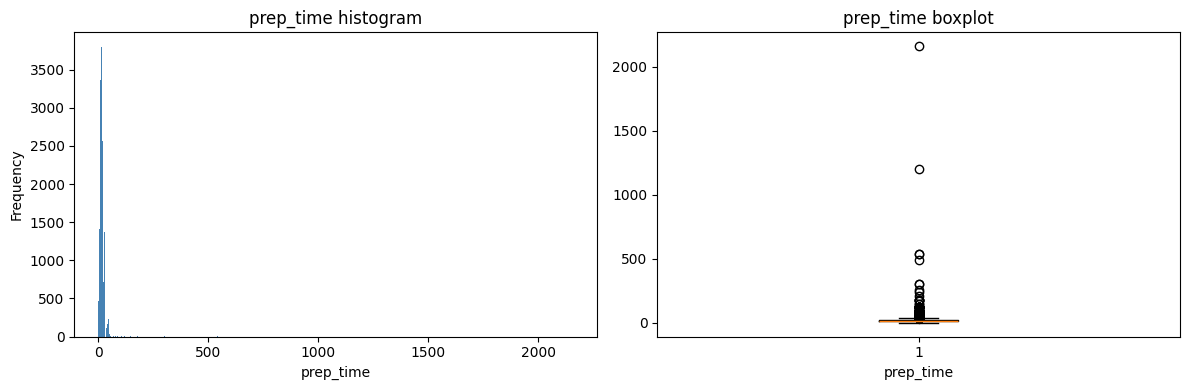

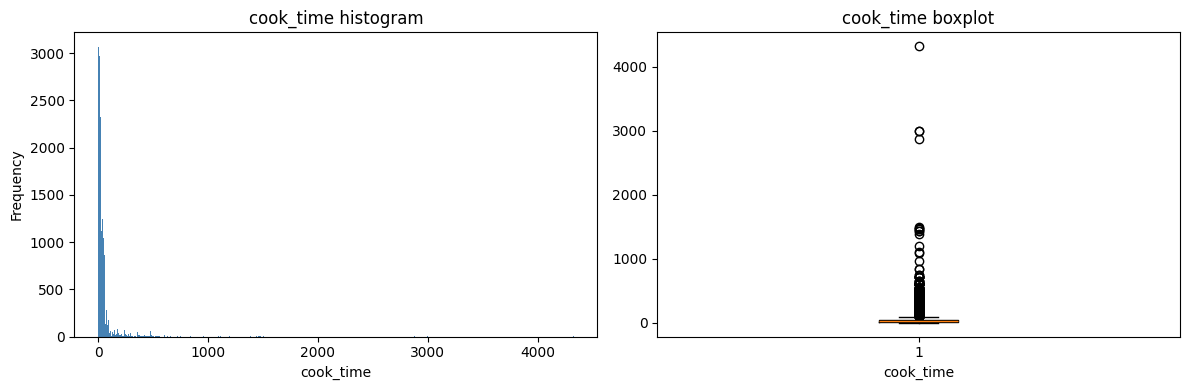

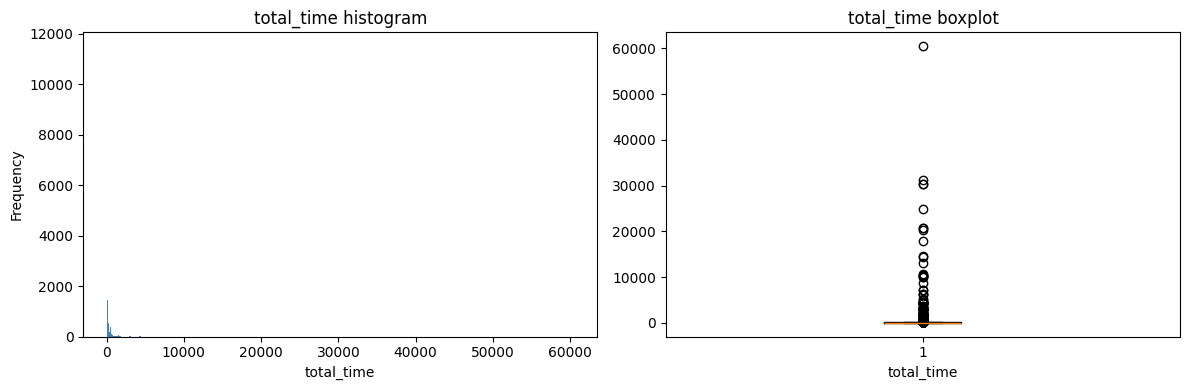

In [13]:
# Use the helper function 'plot_hist_and_box' from visualisaton.py to plot the histograms and boxplots in 2 columns for each time based variable.
plot_hist_and_box(df, "prep_time")
plot_hist_and_box(df, "cook_time")
plot_hist_and_box(df, "total_time")

All three time-based variables show strong right-skew, with most recipes taking very little time to prep, cook or overall and a small number of recipes taking a very long time. This is demonstrated by the outliers in each boxplot, and in the scale of the x-axes for each histogram, creating the long right tails. Here I assume that everyday quick recipes dominate the population within the website, with longer recipes stretching the upper time boundary of the collection. K-Means is sensitive to outliers, and so this will be investigated later.

Below is a heatmap showing the Pearson Correlation Coefficient between the pairs of variables, this was created to help me observe whether there is multicolinearity within the dataset between these variable pairings, enabling me to assess which of the 3 columns to remove to reduce the overweighting of time as a feature of the model.

<Axes: >

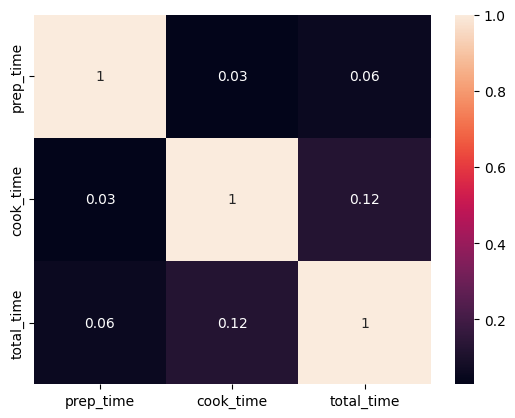

In [14]:
# Plot heatmap of all time columns. 'annot=True' adds corr number to each square.
sns.heatmap(time_columns(df).corr(), annot=True)

The correlations are very weak for each pairing with **0.03** for *prep_time vs cook_time*, **0.06** for *prep_time vs total_time* and **0.12** for *cook_time vs total_time*. This suggests that the time it takes to prepare a recipe and the time it takes to cook the recipe are almost independent, a recipe that takes a long time to prepare doesn't necessarily take a long time to cook and a recipe that is quick to prepare isn't necessarily quick to cook. Examples of this could be a salad, which takes a long time to prepare the ingredients but possibly contains no or very little cooking time. The total time is only slightly related to the preparation and cooking components which suggests that the recipes vary wildly in how their time is distributed between the preparation and cooking. This correlation heatmap indicates that all **3** time variables will be suitable for K-Means clustering as they each contribute independent information for clustering meaning K-Means can potentially separate the recipes into clusters such as "long-cook", "long-preparation" and "long-overall time".
***
<br>

In [15]:
# Take the time columns defined earlier sorted on total_time,
# Display the first 10 with hyperlinks using html helper function from utils.py
display_html(time_columns_with_url(df).sort_values("total_time", ascending=True), n=10, random=False, seed=42)

,url,prep_time,cook_time,total_time
2333,Easy Raisin Cake,0,0,0
7760,Sour Milk Spice Cake,0,0,0
6323,Oatmeal Raisin Cookies IV,0,0,0
6332,Marshmallow-Peanut Butter Fudge,0,0,0
13939,Spritz Orange Crisps,0,0,0
12799,Spicy Pumpkin Fudge,0,0,0
4012,Fabulous Homemade Bread,0,0,0
4074,Frozen Tiramisu,0,0,0
4079,Never Fail Applesauce Spice Cake,0,0,0
1485,Mango Gazpacho,0,0,0


#### Missing Time Variables
The table above demonstrates clearly that some entries have missing time information in all columns for example *[Spritz Orange Crisps](https://www.allrecipes.com/recipe/11198/spritz-orange-crisps/)* and *[Caramel Corn I](https://www.allrecipes.com/recipe/9386/caramel-corn-i/)*. As time is required for our K-Means clustering and also recognising that it is impossible to create a recipe in *no time at all*, I will filter to remove any recipes where all of the time columns show zero time in all time based fields.

Some recipes may be for foods where the preparation time is greater than zero but the cook time equals zero as there is no cooking involved, for example *[Berry Overnight Oats](https://www.allrecipes.com/recipe/257039/berry-overnight-oats/)*. Some recipes show preparation time equal to zero but cook time greater than zero such as *[Fruity Tutti Turkey Brine](https://www.allrecipes.com/recipe/219474/fruity-tutti-turkey-brine/)*. I assume here that recipe creators have not factored time for sourcing ingredients into the preparation time and any chopping time is included in either the cook time or in any additional time. For all of these reasons, recipes are removed when all three of the time fields equal zero, and they are retained where any of the **3** time fields are greater than zero.

In [16]:
# Filter to retain recipes where all time fields are > 0
df = df[(df['prep_time'] + df['cook_time'] + df['total_time']) > 0]

# Count number of recipes left by counting the number of rows in the dataframe
print(f"Number of recipes left: {len(df)} \n")

# Show first 10 rows with clickable links using the helper function 'display_html()' from utils.py
display_html(time_columns_with_url(df).sort_values("total_time", ascending=True), n=10, random=False, seed=42)

Number of recipes left: 14066 



,url,prep_time,cook_time,total_time
9159,3-Ingredient Japanese Potsticker Dip,1,0,1
9476,Sauteed Oyster Mushrooms in Garlic Butter,1,0,1
3970,Pumpkin Pie Spice I,1,0,1
6043,Teriyaki Sauce,1,0,1
3224,Classic Bloody Mary,2,0,2
12516,Microwave Quesadilla,2,1,3
6022,Lorraine’s Sugar Cookies,30,10,4
13587,Apple Banana Smoothie,5,0,5
6324,New Year's Champagne Punch,5,0,5
2078,Fruit Punch,5,0,5


I am left with **14,066** recipes in the population, having removed **160** recipes.

There are cases where the *'prep_time'* and *'cook_time'* do not add up to the *'total time'*, see below.

In [17]:
# Find where the prep time plus the cook time are not equal to the total time
total_time_NE_other_time = df[(df['prep_time'] + df['cook_time']) != df['total_time']]
total_time_NE_other_time = total_time_NE_other_time[["url", "prep_time", "cook_time", "total_time"]].sort_values("total_time", ascending=True)

print(f"Number of recipes where 'prep_time' + 'cook_time' <> 'total_time': {len(total_time_NE_other_time)} \n")

# Show 10 random rows with clickable links, sort this output on total_time for viewing using the helper function 'display_html()' from utils.py
display_html(total_time_NE_other_time, n=10, random=True, seed=42, sort_by="total_time")

Number of recipes where 'prep_time' + 'cook_time' <> 'total_time': 5405 



,url,prep_time,cook_time,total_time
8572,Cindy's Coleslaw,5,0,35
6089,Instant Pot Beef Burritos,15,25,45
3553,Crispitos,10,45,50
5591,The Best Meatloaf,15,60,80
8506,Grandma Ruby's Buttermilk Pound Cake,15,75,105
1488,Teri Tips,5,15,260
8501,Blueberry Pie in a Jar,20,20,280
8670,Jamaican Brown Stew Chicken,40,80,360
14111,Pimento Cheese Jell-O® Salad,10,5,495
9991,Barbequed Ribs,30,180,690


There are **5,405** recipes where the *'prep_time'* and *'cook_time'* did not add up to the *'total_time'*, investigation revealed a missing time based field that is available on the website, called additional time. I observed additional time to represent periods required in meal-preparation for activities such as marinating, or defrosting and post-cooking for activities such as resting and cooling. For example:

| Recipe | Missing Time | Type Missing |
|--------|--------------|--------------|
| *[Dark Honey Pecan Granola](https://www.allrecipes.com/recipe/247188/dark-honey-pecan-granola/)* | **60min** | additional |
| *[Easy Lasagna](https://www.allrecipes.com/recipe/12011/easy-lasagna-ii/)* | **10min** | additional |
| *[Pumpkin Pie Eggnog](https://www.allrecipes.com/recipe/269204/pumpkin-pie-eggnog/)* | **8hours** | additional |
| *[Prime Rib Our Way](https://www.allrecipes.com/recipe/219586/prime-rib-our-way/)* | **30min** | additional |
| *[Sweet Potato And Bacon Pizza](https://www.allrecipes.com/sweet-potato-and-bacon-pizza-recipe-8747988)* | **8hr 25 min** | cool/rise/stand |


I decided to calculate the missing *'additional-time'* values by subtracting the *'prep_time'* and *'cook_time'* from *'total_time'* and calling this *'extra_time'*. All time types may affect whether or not an individual chooses a recipe and as they represent different behaviours within the recipe reconstruction process they are all relevant to the K-Means clustering model. 

Preparation time, cooking time and the 'extra time' are all independant stages of the recipe recreation process, but as *'total time'* is determined by all of those stages and the 'extra time' will be calculated from *total_time*, *prep_time* and *cook_time*, then the variables are mathematically dependant upon each other. If all **4** time variables exist within the model then multicollinearity will exist within the data, and as discussed earlier this would distorting the distance-based clustering by double counting the overall time required for creating the recipe. Therefore *total_time* becomes a redundant field once I have calculated *extra_time*. I have decided to remove *total_time* from the K-Means clustering model dataset.

Bringing **3** time-based fields into the K-Means clustering gives time **3** factors of influence in the distance calculations compared to other non-time based variables. The three remaining time types are all meaningful to the recipe recreation process and bear a real world influence on people's lifestyles and behaviours. Having 3 time-based weightings may mean that time is over represented within the model, therefore in an attempt give time a more balanced weighting I will reduce the weighting for time by engineering two new time-based features based on behavioural types to use instead of **3**. When considering the participation of the cook/chef in the recipe recreation process they are completing *active* and *passive* behaviours therefore I decided to classify the behaviours into ***active_time*** comprising cooking and preparation time, where recipes involve the act of phyiscally doing something and ***passive_time*** comprising periods of defrosting; bringing to room temperature; freezing; refrigeration; chilling; rising; proofing; resting; cooling; marinating; simmering and reheating where the recipe requires no physical action, thereby reducing the number of time-based factors to **2**, shown below.

1. **active tasks**, where effort is required for preparation and cooking **{active_time = prep_time + cook_time}**
2. **passive tasks**, revolved around waiting and lifestyle flexibility **{passive_time = total_time - (prep_time + cook_time)}**  Note: I briefly considered calling this one *extra_time* however the labels active and passive are more descriptive of behaviours experienced by people recreating the recipes.

This approach of calculating time based behaviours, means that the original **3** time columns can be dropped, and thus I have reduced the time dominance within the clusters from **3** fields to **2** fields. It also enables me to derive rich behavioural insight into the model which will enable me to use these variables to distinguish between different behaviours, for example:

| Behaviour | Description | Example Meal |
|-----------|-------------|--------------|
| High-Active/Low-Passive | Labour intensive cooking | Full English Breakfast |
| Low-Active/Low-Passive | Quick meals | Toast |
| High-Active/High-Passive | Complex and slow recipes | Sunday Roast |
| Low-Active/High-Passive | Slow but easy meals | Overnight Oats |

Now I will create the new time-based features.

In [18]:
# Create active_time by adding the preparation and cooking times.
df['active_time'] = df['prep_time'] + df['cook_time']
# Create passive_time by subtracting the preparation time and cooking time from the total time.
df['passive_time'] = df["total_time"] - df['prep_time'] - df['cook_time']

# Show 10 random rows with clickable links, sort this output on passive_time for viewing using the helper function 'display_html()' from utils.py
display_html(time_columns_extended(df), n=10, random=True, seed=42, sort_by="passive_time")

,url,prep_time,cook_time,total_time,active_time,passive_time
6617,Thanksgiving Egg Rolls,20,15,35,35,0
12009,Thai Pesto,10,0,10,10,0
13574,Tater Tots® Nachos,15,35,50,50,0
3940,Glo's Sausage Fried Rice,20,20,40,40,0
8355,Maple Pumpkin Doughnuts,40,10,50,50,0
1102,Smoked Salmon Dip,15,0,15,15,0
10640,Creamy Linguini for Two,20,10,30,30,0
922,French Onion Beef and Noodles,15,40,55,55,0
9306,Tourtiere (French Canadian Meat Pie),20,120,145,140,5
5008,Flank Steak Pinwheels,20,60,565,80,485


In [19]:
# Show descriptive statistics for the time columns using the 'time_columns_extended()' helper function from utils.py
time_columns_extended(df).describe().round(3)

,prep_time,cook_time,total_time,active_time,passive_time
count,14066.000,14066.000,14066.000,14066.000,14066.000
mean,17.789,43.604,147.753,61.393,86.360
std,25.031,97.808,885.060,101.508,877.599
min,0.000,0.000,1.000,0.000,-2940.000
25%,10.000,10.000,30.000,25.000,0.000
50%,15.000,20.000,55.000,40.000,0.000
75%,20.000,45.000,100.000,65.000,20.000
max,2160.000,4325.000,60485.000,4345.000,60480.000


***
<br>

#### Passive Time (Zero minutes, Negative minutes , Maximum minutes and Outliers)
<br>

**Zero Minutes:**
As stated earlier the definition of passive time is *"**passive time** comprising periods of defrosting; bringing to room temperature; freezing; refrigeration; chilling; rising; proofing; resting; cooling; marinating; simmering and reheating where the recipe requires no physical action"*, this means that the recipe creation time can include zero passive time.
<br><br>

**Negative Minutes:**
Some of the passive times are negative values, and as that would constitute time travel I will investigate, recipes where the passive time is less than 0 to see how much of a problem this is, as the scale of the issue may affect the way that this is dealt with.

In [20]:
# Count recipes where passive time is less than 0
print(f"Number of recipes with negative passive time: {len(df[df['passive_time']<0])} \n")

# Display some recipes with negative passive time and clickable links, sorted on passive time using the helper function 'display_html()' from utils.py
display_html(time_columns_extended(df[df['passive_time'] < 0]), n=10, random=True, seed=42, sort_by="passive_time")

Number of recipes with negative passive time: 11 



,url,prep_time,cook_time,total_time,active_time,passive_time
6793,Pumpkin Spice Cake,20,3000,80,3020,-2940
4813,Sausage Potato Casserole,1200,80,115,1280,-1165
215,Creamy Mississippi Chicken Enchiladas,15,150,50,165,-115
10257,World's Best Sweet Potato Pound Cake,30,75,65,105,-40
6022,Lorraine’s Sugar Cookies,30,10,4,40,-36
12733,Tiny Oatmeal Cream Pies,30,30,50,60,-10
3553,Crispitos,10,45,50,55,-5
7767,Pineapple Zucchini Muffins,25,20,40,45,-5
4854,Slow Cooker Overnight Ham and Cheese Breakfast Casserole,5,480,480,485,-5
10421,Chilaquiles with Spicy Salsa,15,20,34,35,-1


There are **11** recipes with negative passive time, when looking at these recipes there was no common theme for determining how the error occurred in each. I will assume that the negatives are due to user error in the way the numbers have been calculated, as recipes are submitted by website members.

I have decide to remove these recipes from the model as there is no clear method of correcting them all, and the proportion of erroneous recipes (**11**) in the population (**14,066**) is very small (**~0.078%**).
<br><br>

**Maximum Minutes:**
Before investigating outliers I will review entries at the upper end of the number of passive minutes.


In [21]:
# Display some recipes at the upper end of passive time, sorted on passive time  using the helper function 'display_html()' from utils.py
display_html(time_columns_extended(df).sort_values("passive_time", ascending=False), n=10, random=False)

,url,prep_time,cook_time,total_time,active_time,passive_time
11996,Homemade Wine,5,0,60485,5,60480
11796,Sauerkraut for Canning,60,90,31160,150,31010
7957,Homemade Limoncello,20,20,30280,40,30240
11479,Pickled Garlic,45,15,30300,60,30240
928,Kentucky Bourbon Cake,45,240,24780,285,24495
7911,Crisp Pickled Green Beans,15,20,20675,35,20640
14028,Trinidad Black Cake,20,150,20810,170,20640
7118,Grandma Bettie's Light Fruit Cake,15,90,20265,105,20160
13500,Mini Christmas Cakes,70,90,17950,160,17790
3526,Spicy Refrigerator Dill Pickles,15,0,14535,15,14520


All of these large time-committment recipes appear plausible due to long resting and fermentation periods. I conducted some checks evidenced below:
- *[Homemade Wine](https://www.allrecipes.com/recipe/58561/homemade-wine/)* takes **~42 days**. I validated homemade wine timings against other websites observing that it can take weeks/months to make homemade wine, for example *[www.fermentations.co.uk](https://fermentations.co.uk/how-to-make-homemade-wine-step-by-step/)* and *[www.doitathome.co.uk](https://doitathome.co.uk/en/how-long-does-it-take-to-make-wine-a-guide-for-home-brewers.htm)*.
- *[Sauerkraut recipe](https://www.allrecipes.com/recipe/21154/sauerkraut-for-canning/)* takes **~22 days**. I validated this against *[www.makesauerkraut.com](https://www.makesauerkraut.com/how-long-to-ferment-sauerkraut/#h-how-long-to-ferment)* which confirmed that it can take **~3 weeks** to make.

My decision is to leave these recipes in the population, as the K-Means clustering model may cluster recipes that take a long time together.
<br><br>

**Outliers:** As the recipes with zero and very large passive minutes will remain in the model then any outliers (identified earlier in the boxplots) will also remain in the model, as these may form valid time-based clusters. **Geron (2019)** discusses a similar concept where outlier clusters may be useful in fraud detection.
<br><br>

**Recipe Removal**: I will now remove the recipes where there is a negatvie *'passive_time'*, leaving recipes with zero/outlier 'passive_time'. 

In [22]:
# Filter to remove entries where there is a negative passive_time
df = df.loc[(df["passive_time"] >= 0)]

# Count the number of recipes left in the data now
print(f"Number of recipes left: {len(df)}\n")
df.describe().round(3)

Number of recipes left: 14055



,recipe_id,calories,fat,carbs,protein,servings,prep_time,cook_time,total_time,active_time,passive_time
count,14055.000,13871.000,13720.000,13857.000,13825.000,14044.000,14055.000,14055.000,14055.000,14055.000,14055.000
mean,7212.202,345.241,17.867,32.771,14.521,10.898,17.703,43.358,147.797,61.061,86.735
std,4164.946,249.957,16.689,27.706,17.457,12.992,22.968,94.537,885.398,97.824,877.502
min,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
25%,3601.500,182.000,7.000,14.000,4.000,4.000,10.000,10.000,30.000,25.000,0.000
50%,7224.000,308.000,14.000,29.000,9.000,8.000,15.000,20.000,55.000,40.000,0.000
75%,10808.500,453.500,24.000,45.000,22.000,12.000,20.000,45.000,100.000,65.000,21.000
max,14425.000,9538.000,612.000,746.000,939.000,300.000,2160.000,4325.000,60485.000,4345.000,60480.000


***
<br>

#### Active Time (Zero minutes, Negative minutes , Maximum minutes and Outliers)
<br>

**Zero Minutes:** Next I will investigate where active time is equal to zero, as it is impossible to create a recipe with no activity at all. Therefore I am observing whether these could be an error within the data.

In [23]:
# Filter to gather zero-active-time recipes
zero_active = df[df["active_time"] == 0]

# Count recipes where the active time is zero
print(f"Number of recipes with zero active time = {len(zero_active)}\n")

# Display clickable links, sorted by passive_time (largest first) using the helper function 'display_html()' from utils.py
display_html(time_columns_extended(zero_active).sort_values("passive_time", ascending=False), n=20, random=False)

Number of recipes with zero active time = 20



,url,prep_time,cook_time,total_time,active_time,passive_time
9257,Sous Vide Tri Tip,0,0,195,0,195
13304,Brookville Hotel Sweet and Sour Coleslaw,0,0,150,0,150
3402,Rustic Chicken and Dumplin's,0,0,135,0,135
9701,Slaw of Many Colors,0,0,135,0,135
11995,These 3-Ingredient Little Debbie's Christmas Tree Truffles Are a Must-Try This Holiday Season,0,0,90,0,90
10085,Mochi Donuts,0,0,80,0,80
2803,Meet the Everything Bagel Casserole: The Ultimate Breakfast Comfort Food,0,0,70,0,70
13312,Ruffled Milk Pie,0,0,65,0,65
9183,Chicken Fajita Rice Casserole,0,0,65,0,65
11633,Country Ham and Biscuits,0,0,45,0,45


There are **20** recipes where active time is equal to zero. Assuming that every recipe must take some form of action, whether that is cooking or preparation, that the act of creating recipes by magic has not been mastered, and even casting a magic spell would take some form of time, then further investigation into the recipes on the website was done to test if information was missing.

*[Copycat Little Debbie Oatmeal Creme Pies](https://www.allrecipes.com/copycat-little-debbie-oatmeal-creme-pies-recipe-8373904)* was updated on **20th March 2026**, therefore not all time fields are the same within my data extract as those on the website.

The other examples all introduce new time fields and have missing *'prep_time'* and *'cook_time'* fields, see below:

| New Time Type | Recipe | Decision | Reason |
|---------------|--------|----------|--------|
| Active Time | *[Sous Vide Tri Tip](https://www.allrecipes.com/recipe/8526329/sous-vide-tri-tip/)* | Remove | Recipe states that it includes **20** minutes of active time, and descriptive steps state **3** hours of cooking time, these figures do not add up to **195** minutes. I am unable to calculate the active to passive ratio split |
| Hands On Time | *[Country Ham and Biscuits](https://www.allrecipes.com/country-ham-and-biscuits-recipe-8707673)* | Remove | Unable to calculate the active to passive ratio split |
| Bake Time | *[Chicken Fajita Rice Casserole](https://www.allrecipes.com/recipe/8515531/chicken-fajita-rice-casserole/)* | Remove | The two available times do not add up to the total time and I am  unable to calculate the active to passive ratio split |
| Fry Time | *[Mochi Donuts](https://www.allrecipes.com/recipe/8516139/mochi-donuts/)* | Remove | Unable to calculate the active to passive ratio split|
<br>

My decision is to remove all of these recipes from the population, as the number of recipes with zero *'active_time'* (**20**) in the population (**14,055**) is negligible (**0.14%**).
<br><br>

**Negative Active Time:** There are no recipes with negative *'active_time'* as the minimum *'active_time'* is zero.
<br><br>

**Maximum Active Time:** Next I will check the recipes with a long active time.

In [24]:
# Identify recipes with the longest active time values using the helper function 'display_html()' from utils.py
display_html(time_columns_extended(df).sort_values("active_time", ascending=False), n=10, random=False)

,url,prep_time,cook_time,total_time,active_time,passive_time
9593,72-Hour Sous Vide Short Ribs,20,4325,4345,4345,0
6904,Spiced Chicken Loaf,10,3000,3025,3010,15
5989,Sous Vide Corned Beef,5,2880,2885,2885,0
10400,Melenzana Ali Olio,2160,15,2175,2175,0
3169,Spinach Artichoke Dip from Reynolds Wrap®,15,1500,1515,1515,0
8340,Sous Vide Pork Back Ribs,15,1475,1490,1490,0
2225,Bone Broth,10,1470,1480,1480,0
12376,Sous Vide Blade Roast with Au Jus,10,1460,1480,1470,10
8280,Split Pea and Ham Soup II,20,1440,1460,1460,0
8709,Sous Vide Carnitas,15,1440,1455,1455,0


Due to methods such as using a sous-vide/water-bath (*[72-Hour Sous Vide Short Ribs](https://www.allrecipes.com/recipe/245849/72-hour-sous-vide-short-ribs/)*) and slow cooking (*[Slow Cooker Baked Beans](https://www.allrecipes.com/recipe/90438/slow-cooker-baked-beans/)*) or cooking by using a fire in a hole in the ground (*[Bean-Hole Beans](https://www.allrecipes.com/recipe/32033/bean-hole-beans/)*) I have decided to retain these recipes in the population.
<br><br>

**Outliers:** The above recipes may be outlier recipes in the *'active_time'* component, but as discussed in the *'passive_time'* section these will remain. Having a large time commitment to a recipe may create a meaningful grouping within the K-Means clustering model, which people may use when detemining whether or not to use the recipe.
<br><br>

**Recipe and Column Removal:** I will now remove the **20** recipes with zero 'active_time' and then drop the original **3** time based fields as I have **2** time based behavioural indicators ('active_time' and 'passive_time') that I am happy with.

In [25]:
# Filter to remove entries where there is a zero active_time and hide the 3 original time-based fields
df = df.loc[df["active_time"] > 0].drop(columns = ["prep_time", "cook_time", "total_time"])

# Count the number of recipes left in the data now
print(f"Number of recipes left: {len(df)}\n")
df.describe().round(3)

Number of recipes left: 14035



,recipe_id,calories,fat,carbs,protein,servings,active_time,passive_time
count,14035.000,13854.000,13703.000,13840.000,13808.000,14024.000,14035.000,14035.000
mean,7209.570,345.223,17.864,32.769,14.526,10.903,61.148,86.771
std,4165.087,250.042,16.693,27.716,17.464,12.998,97.867,878.125
min,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000
25%,3599.500,182.000,7.000,14.000,4.000,4.000,25.000,0.000
50%,7220.000,308.000,14.000,29.000,9.000,8.000,40.000,0.000
75%,10805.500,453.000,24.000,45.000,22.000,12.000,65.000,20.000
max,14425.000,9538.000,612.000,746.000,939.000,300.000,4345.000,60480.000


I am left with **14,035** recipes where I am content with the time based columns for the K-Means clustering model.

***
<br>

#### Summary of Time-Based EDA

The questions from above have now been answered.

| Variable | Fact | Questions to ask | Answer/Decision |
|----------|------|------------------|--------|
| *_time | Very large maximum times. **1,440** minutes in **24**hrs | Is this possible? | Yes - Keep them in the model |
| *_time | Minimum = **0** | Are they all **0** in the same meal? <br> Should they be removed? | No they aren't always all from the same meal, but remove recipes where all are zero. |
| total_time | | How is this constructed? | *cook_time + prep_time + extra_time = total_time* <br> use this to generate an 'extra_time' column, then generate **2** behavioural time columns 'active' and 'passive and then drop the original time-based columns. |

- I investigated how the *'total time'* field was constructed and observed additional time related fields contained in the website data but not within the scraped data.
- I calculated *'active'* and *'passive'* behavioural times.
- I removed instances where zero values did not make sense in the time fields, but retained those that made sense to contain zero time. Every recipe takes some form of *active* time, but not every recipe takes some form of *passive* time.
- I removed instances where there was negative *'passive_time'* as it would involve time-travel to create those recipes and the negative values were a byproduct of missing time variables within the data.
- I am now content with the time-based variables in the data.

***
<br>

### Size Based EDA (Serving Size - *Missing (NaN), Zero, Maximum, Outliers*)
<br>

**<center> Questions From Earlier </center>**

| Variable | Fact | Questions to ask |
|----------|------|------------------|
| servings | Maximum = **300** | Does that look plausible for the meal? <br> Is the calorie count and macronutrient value given per serving or per meal and do they require recalculation per serving? |


<br>

The Allrecipes website states that **duplicate** submissions are removed, ingredient lists are evaluated for **completeness** and **accuracy**, serving sizes and yields also reviewed for **accuracy**, and recipes are tested to ensure they can be replicated by following the instructions. It also states that health claims such as *low-fat/low-carb or paleo etc.* are evaluated by editors, see *[Approval and Testing](https://www.allrecipes.com/about-us-6648102#toc-recipe-approval-and-testing)*. There is no mention of directly verifying the nutritional information within recipe submissions, or validating serving sizes, therefore in the absence of an available method documented within the site information for how these values are generated or how they should he handled, I must consider alternative approaches for handling these columns and observations.
<br><br>

First I will look at the distribution of the serving sizes using a bar chart rather than a histogram as serving sizes are not a continuous variable.

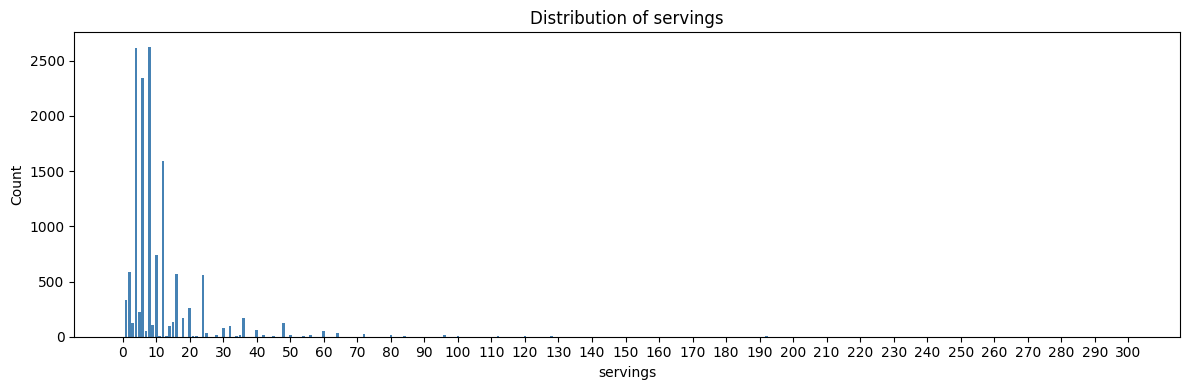

In [26]:
# Use the bar plot helper function from visualisations.py
plot_bar_counts(df, "servings", tick_step=10)

Here I can see that the majority of recipes have smaller serving sizes (**~under 15 servings**) with a few recipes with very large serving sizes.
<br><br>

**Missing (NaN):** Remembering that *'servings'* contained missing (NaN) values, I will verify whether they should be replaced by a zero or some other treatment.

In [27]:
# Filter to gather the recipes with missing servings (NaN)
df_nan_servings = df[df["servings"].isna()].drop(columns = ["recipe_id", "name", "ingredients"])

# Print a sentence with the count of recipes with missing servings
print(f"Number of recipes with missing servings: {len(df_nan_servings)}\n")

# Display the recipes with clickable links using the helper function from utils.py, display all of them using the len function.
display_html(df_nan_servings, n=len(df_nan_servings), random=False)

Number of recipes with missing servings: 11



,url,calories,fat,carbs,protein,servings,active_time,passive_time
2747,Easy Rotisserie Chicken Enchiladas,1008.0,50.0,82.0,61.0,NaN,40,0
2988,Creamy Gnocchi with Vegetables,1441.0,51.0,203.0,43.0,NaN,15,0
3020,Salmon Brine That's Oh-So-Fine,2039.0,1.0,531.0,4.0,NaN,10,0
3447,Simple Chicken Brine,NaN,NaN,NaN,NaN,NaN,10,240
5035,This Copycat Chipotle Honey Vinaigrette Tastes Just Like the Real Thing,1518.0,152.0,41.0,1.0,NaN,10,0
5687,Coconut Milk Ice Cream,346.0,8.0,68.0,1.0,NaN,5,360
9055,Chicken Bacon Ranch Potato Casserole,4037.0,227.0,299.0,194.0,NaN,55,0
10496,This Matcha Martini Will Be Your Go-to Drink of the Summer,126.0,0.0,11.0,0.0,NaN,5,0
11638,Carrot Marmalade,1650.0,1.0,424.0,2.0,NaN,90,240
12198,Campfire Queso,4422.0,330.0,141.0,233.0,NaN,35,0


After viewing these **11** recipes on the Allrecipes.com website, I have been unable to determine a method of calculating serving size of them due to differences in the recipe types, my decision it to remove these from the population.
- *[Salmon Brine That's Oh So Fine](https://www.allrecipes.com/recipe/234485/salmon-brine-thats-oh-so-fine/)*: This is a brine to use on salmon and does not state how many salmon servings it is for.
- *[Easy Rotisserie Chicken Enchiladas](https://www.allrecipes.com/easy-rotisserie-chicken-enchiladas-recipe-11706233)*: This uses **6** corn tortillas but does not state how many are in each serving.
- *[Carrot Marmalade](https://www.allrecipes.com/carrot-marmalade-recipe-11712226)*: This does not state how many servings are in each jar of marmalade.

Serving size may be a variable used in the K-Means clustering and may be a key decision metric used by people deciding which recipe to create and as none of these recipes state how many servings each recipe will provide they will be removed rather than imputed as zero. They cannot remain as NaN values as K-Means clustering is distance based, requiring numeric features and therefore, cannot handle missing values.

In [28]:
# Filter to remove entries where servings is missing
df = df[~df["servings"].isna()]

# Count the number of recipes left in the data now
print(f"Number of recipes left: {len(df)}\n")
df.describe().round(3)

Number of recipes left: 14024



,recipe_id,calories,fat,carbs,protein,servings,active_time,passive_time
count,14024.000,13844.000,13693.000,13830.000,13798.000,14024.000,14024.000,14024.000
mean,7209.597,344.223,17.817,32.650,14.497,10.903,61.175,86.745
std,4165.313,244.580,16.340,27.015,17.296,12.998,97.898,878.456
min,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000
25%,3600.750,182.000,7.000,14.000,4.000,4.000,25.000,0.000
50%,7220.500,308.000,14.000,29.000,9.000,8.000,40.000,0.000
75%,10805.250,453.000,24.000,45.000,22.000,12.000,65.000,20.000
max,14425.000,9538.000,612.000,746.000,939.000,300.000,4345.000,60480.000


**Zero:** All recipes have a minimum serving size of one serving now. Which is sensible as no recipe should make zero servings, as that would count as making nothing.
<br><br>

**Outliers:** As the servings columns is not a continuous variable the usual methods of calculating outliers will not hold. Therefore here I find recipes where there are fewer than 2 recipes for the serving size.

In [29]:
# Find rare serving sizes (where the serving size is used fewer than 2 times)
rare_servings_df = df[df.groupby("servings")["servings"].transform("count") < 2].drop(columns = ["recipe_id", "name", "ingredients", "active_time", "passive_time"])

# Count the number of rare serving sized recipes
print(f"Number of rare serving recipes: {len(rare_servings_df)}\n")

# Display the data with clickable links, sorted by servings descending using the helper function from utils.py
display_html(rare_servings_df.sort_values("servings", ascending=False), n=20, random=False)

Number of rare serving recipes: 20



,url,calories,fat,carbs,protein,servings
769,Peanut Butter and Carrot Dog Treats,9.0,0.0,1.0,0.0,300.0
10291,The Best Canning Salsa,9.0,0.0,2.0,0.0,272.0
11601,Sweet Pickle Relish,18.0,NaN,5.0,0.0,180.0
13448,Pickled Banana Peppers,60.0,6.0,2.0,1.0,160.0
189,Cheese Crackers,31.0,2.0,2.0,1.0,150.0
10606,Easy Zucchini Relish,34.0,0.0,8.0,0.0,134.0
9208,Granddad's Peppermint Fudge,74.0,3.0,12.0,0.0,117.0
5231,Ghirardelli Chocolate-Peanut Butter Thumbprint Cookies,91.0,5.0,11.0,1.0,108.0
9383,Mighty Granola,154.0,8.0,20.0,3.0,88.0
8294,Creamy and Tasty Eggnog Fudge,51.0,1.0,10.0,0.0,81.0


**20** recipes contain serving sizes that no other recipes contain. Some of these are very large serving sizes, all of them have a serving size of over **15** servings. When looking at this list the number of times a serving size appears in the data is not a valid reason to exclude recipes, therefore I will observe these from the perspective of the number of servings a recipe submission states that the recipe is for instead.
<br><br>

**Maximum/Very Large Serving Recipes:** The table above shows some recipes with very large serving sizes and at first glance these recipes seem like they should be removed from the population as they would distort the distance-based clustering too much and/or they may be erroneous. However after further investigation using the Allrecipes webiste I have deduced that these numbers do appear plausible due to the large sizes of the product created in the recipe. For example, *[Pickled Banana Peppers](https://www.allrecipes.com/recipe/284563/pickled-banana-peppers/)* making a **5-quart** batch which is equivalent to **~4.7litres**, coupled with the fact that many of the other recipes are for jams, chutneys, relishes and dog treats where 1 serving would be the size of a tablespoon/teaspoon, and yet a large jar of the product is created. I have decided to retain these recipes as they may form their own cluster within the K-Means clustering model, and as with the time-based components earlier, the outliers are acceptable here.
<br><br>

**Serving Size Vs Energy/Macronutrient Values:**
I initially thought that servings could play a meaningful role in interpretting the energy/macronutrient column values, as logically calories, fat, carbohydrates and protein should scale by the serving size of the recipe, one strategy I considered was to calculate the nutritional values per serving. However, this assumption did not hold true when comparing Allrecipes entries with external online sources for similar items. For example, compare *[Chewy Whole Wheat Peanut Butter Brownies](https://www.allrecipes.com/recipe/140717/chewy-whole-wheat-peanut-butter-brownies/)* with **222** calories per **16 servings** against *[Nutracheck - Calories In Brownies](https://www.nutracheck.co.uk/CaloriesIn/Product/Search?desc=brownie)* showing around **250** calories for **1** similar sized item.

A similar issue appears in recipes with extremely high calorie counts (over **3000** calories, **5 items**, see below). Some of these values appeared to represent the calories for the entire recipe (multiple servings) rather than per serving. For instance *[Boeuf En Croute (Beef in Puff Pastry)](https://www.allrecipes.com/recipe/213512/boeuf-en-croute/)* recipe lists **3274** calories for **2 servings**, while *[Nutracheck - Calories In Beef En Croute](https://www.nutracheck.co.uk/CaloriesIn/Product/Search?desc=beef+en+croute)* reports around **550** calories per serving for a comparable dish. Also some of them are just very high calorie meals as even this recipe would be over **1600** calories per serving. The inconsistencies may stem from the nature of the platform, where recipes are user submitted, and some contributors may enter calories for the whole dish, while others may enter calories per serving, high-calorie meals could geniunely be high-calorie per serving.

As I cannot reliably determine which recipes report total-recipe calories and which report per-serving calories, it is not possible to standardise the nutritional values by dividing them by the number of servings. As a result, I will retain the serving size column in its original form and will not calculate macronutrients per serving.

I considered dropping the serving size column from the model entirely at the original question does not contain consideration of serving size. However, serving size may influence how users choose recipes, and it may contribute meaningfully to the K-Means clustering model later, therefore I will retain the column and evaluate its usefulness during the K-Means clustering stage. Thus determining whether it contributes to cluster separation or introduces noise, if it proves unhelpful to the clustering it may be used as a descriptive labelling feature instead of as an input variable.

In [30]:
# Filter to gather zero-active-time recipes
calories_gr_3000 = df[df["calories"] > 3000]

# Count recipes where the calories are over 3000
print(f"Number of recipes with over 3000 calories = {len(calories_gr_3000)}\n")

# Display clickable links, sorted by calories (largest first) using the helper function 'display_html()' from utils.py
display_html(calories_gr_3000.drop(columns = ["recipe_id", "name"]).sort_values("calories", ascending=False), n=len(calories_gr_3000), random=False)

Number of recipes with over 3000 calories = 5



,url,ingredients,calories,fat,carbs,protein,servings,active_time,passive_time
12447,Coffee-Rubbed Steak,"1/4 cup finely ground coffee, 2 tablespoons dark brown sugar, 1 1/2 teaspoons chili powder, 2 teaspoons garlic powder, 2 teaspoons Hungarian sweet and spicy paprika, 1 1/2 teaspoons salt, 1/4 teaspoon cayenne pepper, 4 filet mignon steaks",9538.0,612.0,8.0,939.0,4.0,20,5
13705,Eggnog Cream Pie with Gingersnap Crust,"cooking spray, 7 1/2 ounces gingersnap cookies (makes about 1 3/4 cups crumbs), 2 tablespoons granulated sugar, 1/2 teaspoon fine sea salt, 6 tablespoons unsalted butter, 1/2 cup granulated sugar, 1/3 cup cornstarch, 1/2 teaspoon fine sea salt, 1/2 teaspoon freshly grated nutmeg, plus more for finishing, pinch ground cinnamon, 2 1/2 cups eggnog, 1/3 cup heavy cream, 2 tablespoons brandy, bourbon, or rum (optional), 2 teaspoons vanilla extract or 1 teaspoon vanilla bean paste, 1 1/2 cups heavy cream, 1/4 cup powdered sugar, 1 teaspoon vanilla extract or 1/2 teaspoon vanilla bean paste, freshly grated nutmeg, for finishing",5109.0,293.0,563.0,65.0,1.0,45,250
12962,Chicken Parmesan Pizza,"12 frozen chicken nuggets, 1 12-inch pre-baked pizza crust, 1/2 cup marinara sauce, 2 button mushrooms, sliced, 1/2 cup shredded mozzarella cheese, 1/4 cup shredded Parmesan cheese, 6 basil leaves, cut into thin ribbons",4455.0,105.0,746.0,117.0,4.0,23,0
3127,Cherry Pie with Almond Crumb Topping,"1 1 (9 inch) unbaked pie crust (see footnote for recipe link), ½ cup slivered almonds, ½ cup light brown sugar, ⅓ cup rolled oats, ⅓ cup all-purpose flour, ¾ teaspoon salt, 6 tablespoons cold, unsalted butter, cut into pieces, 2 pounds cherries, pitted, ½ lemon, juiced, ⅓ cup white sugar, or more to taste, ¼ cup cornstarch",3565.0,167.0,503.0,43.0,8.0,95,15
3052,Boeuf en Croûte (Beef in Puff Pastry),"1 teaspoon olive oil, 2 (6 ounce) beef tenderloin filets, 1 tablespoon butter, 8 ounces fresh white mushrooms, minced, ⅓ cup minced shallots, 2 cloves garlic, minced, 2 tablespoons red wine, 4 (6-inch squares) frozen puff pastry, thawed but still cold, 1 ½ cups red wine, salt and ground black pepper to taste, 1 large egg (Optional), 2 tablespoons milk (Optional)",3274.0,215.0,232.0,69.0,2.0,55,60


***
<br>

#### Summary of Serving Size EDA

The questions from above have now been answered.

| Variable | Fact | Questions to ask | Answer/Decision |
|----------|------|------------------|--------|
| servings | Maximum = **300** | Does that look plausible for the meal? <br> Is the calorie count and macronutrient value given per serving or per meal and do they require recalculation per serving? | Yes - Large serving sizes are a genuine feature of some recipes. <br> It cannot be determined whether the calorie count is truley per serving or per entire recipe - Leave this as it stands. |


- The recipes with missing serving sizes (NaN) were removed.
- Rare serving sizes remain in the population.
- Serving size shall not be adjusted.
- Calories and macronutrients will not be recalculated based on the number of servings stated in the recipe.
- Serving size within the data as a potential additional consideration for the K-Means clustering.
  <br>

***
<br>

### Nutritional/Energy Based EDA *(calories, fat, carbs, protein - *Missing (NaN), Zero, Outliers, Maximums)*

**<center> Questions From Earlier </center>**
| Variable | Fact | Questions to ask |
|----------|------|------------------|
| calories | Minimum = **1** | Is this possible? |
| calories | Max = **9,538** | Is this a meal for **1** person? <br> How does it compare to other meals with much lower calories? <br> Does serving size have an effect on calories and macronutients? |
| fat, carbs and protein | Minimum = **0** | Is it **0** for all in the same meal? <br> Is it possible? <br> Should they be removed? |
| fat, carbs and protein | Very large maximum amounts | Is is possible? <br> Does serving size have an effect? |
<br>

**Missing Values (NaN):**
Remembering from earlier that there were missing (NaN) values in the nutritional-based columns, first I will investigate recipes with missing values to verify whether they should be replaced by a zero or have some other treatment.

In [31]:
# Identify all recipes with NaN in any of the columns.
mask_any_nan = df.isna().any(axis=1)

# Print some useful summary stats.
print(f"Total Number of Recipes Left = {len(df)} ,  Number of Rows with Missing Values: {mask_any_nan.sum()}\n")

# Display some of the recipes for validation purposes using the helper function 'display_html()' from utils.py
display_html(df[mask_any_nan], n=8, random=False)

Total Number of Recipes Left = 14024 ,  Number of Rows with Missing Values: 366



,recipe_id,name,url,ingredients,calories,fat,carbs,protein,servings,active_time,passive_time
35,35,Royal Icing,Royal Icing,"4 pasteurized egg whites, 4 cups sifted confectioners' sugar, 1 teaspoon lemon or vanilla extract (Optional)",63.0,NaN,16.0,1.0,32.0,10,0
38,38,Bacon on the Grill,Bacon on the Grill,1 pound lean thick-cut bacon,126.0,11.0,NaN,7.0,6.0,20,0
40,40,St. Patrick's Day Jell-O Shots,St. Patrick's Day Jell-O Shots,"½ (3 ounce) package lime-flavored gelatin mix (such as Jell-O®), ½ cup boiling water, ½ cup Irish whiskey (such as Jameson®), 1 (1 ounce) package unflavored gelatin (such as Knox®), ½ cup boiling water, ½ cup strawberry cream liqueur (such as Baileys®)",126.0,NaN,14.0,1.0,8.0,10,480
59,59,Beer Margaritas,Beer Margaritas,"1 (12 fluid ounce) can frozen limeade concentrate, 12 fluid ounces tequila, 12 fluid ounces water, or more as needed, 12 fluid ounces beer, ice, 1 lime, cut into wedges",NaN,NaN,NaN,NaN,6.0,5,0
72,72,Pear Honey,Pear Honey,"8 cups peeled, cored and chopped pears, 1 cup unsweetened pineapple juice, 8 cups white sugar",111.0,NaN,29.0,0.0,64.0,225,0
107,107,Bob's Teriyaki Sauce and Marinade,Bob's Teriyaki Sauce and Marinade,"½ cup soy sauce, ½ cup mirin, ½ cup sake, 2 teaspoons white sugar, ¼ teaspoon ginger puree, 2 teaspoons cornstarch, or as desired (Optional), 2 teaspoons water (Optional)",69.0,NaN,8.0,1.0,8.0,15,0
110,110,Pumpkin Swirl Cheesecake,Pumpkin Swirl Cheesecake,"25 NABISCO Ginger Snaps, finely crushed, ½ cup finely chopped PLANTERS Pecans, ¼ cup butter, melted, 4 (8 ounce) packages PHILADELPHIA Cream Cheese, softened, 1 cup sugar, divided, 1 teaspoon vanilla, 4 eggs, 1 cup canned pumpkin, 1 teaspoon ground cinnamon, ¼ teaspoon ground nutmeg, Dash of ground cloves",NaN,NaN,NaN,NaN,16.0,75,240
127,127,Creamy Jalapeno and Pulled Pork Quesadilla,Creamy Jalapeno and Pulled Pork Quesadilla,"4 (8 inch) flour tortillas, ½ cup PHILADELPHIA Spicy Jalapeno Cream Cheese Spread, 1 (11.5 ounce) package OSCAR MAYER CARVING BOARD Sweet & Spicy Pulled Pork, ½ cup frozen corn, thawed, ½ cup chopped red pepper, ½ cup tomatillo salsa",NaN,NaN,NaN,NaN,8.0,10,15


There are **366** recipes with missing (NaN) values in one or more column, where the fat, carbs or protein variables are NaN, this is because any one or more of the values the recipe should contain were not submitted, for example in *[Pear Honey](https://www.allrecipes.com/recipe/75639/pear-honey/)* where the ingredients are fruits and sugars, therefore carbs (sugars) are the main macronutrient and any fat or protein will be negligible. According to *[www.diabetes.org,uk](https://www.diabetes.org.uk/living-with-diabetes/eating/carbohydrates-and-diabetes)* and *[Harvard T.H. Chan School of Public Health, The Nutrition Source](https://nutritionsource.hsph.harvard.edu/healthy-weight/diet-reviews/ketogenic-diet/)* fruits contain mostly sugars with often negligible fat, protein.

There are cases where the calories and the macronutrient information is missing such as *[Pumpkin Swirl Cheesecake](https://www.allrecipes.com/recipe/127218/pumpkin-swirl-cheesecake/)*, due to the overarching theme of this analysis these will be removed later as they would cluster around the origin and distort the overall distance calculations within the model.

I will replace all NaN values with zero and then remove any recipes where all **4** columns (*calories, fat, carbs and protein*) show zero values, then continue with the EDA. This will remove **180** recipes containing no macronutrient values within the data, these zero values are either because the recipes do in fact contain no macronutrient value, or the recipes have been incorrectly entered, and therefore it is a data quality issue to resolve. I have decided to remove these recipes from the clustering model as, by having zero macronutrient value they bear no weighting in the macronutrient direction(s), sitting exactly at the origin, this means that they cannot be meaningfully compared to the other recipes and may distort the K-Means clustering.

In [32]:
df = df.fillna(0)                                        # Fill all NaN values with 0
macro_cols = ["calories", "protein", "fat", "carbs"]     # Define macro columns
df = df[~((df[macro_cols] == 0).all(axis=1))]            # Remove recipes where all macro columns are equal to 0
print(f"Total Number of Recipes Left = {len(df)}\n")     # Summary of the number of recipes left

# Validation display using the helper function 'display_html()' from utils.py
display_html(df.sort_values(by=["fat", "carbs", "protein"]).drop(columns = ["recipe_id", "name", "ingredients"]), n=8, random=False)

Total Number of Recipes Left = 13844



,url,calories,fat,carbs,protein,servings,active_time,passive_time
893,Chef John’s Mignonette Sauce,1.0,0.0,0.0,0.0,24.0,5,0
1088,Pocket Bread,1.0,0.0,0.0,0.0,16.0,50,120
2989,Homemade Ranch Seasoning for Dip or Dressing,1.0,0.0,0.0,0.0,12.0,5,0
4565,Konbu Dashi,1.0,0.0,0.0,0.0,4.0,25,5
769,Peanut Butter and Carrot Dog Treats,9.0,0.0,1.0,0.0,300.0,80,5
1455,Turkey Brine,3.0,0.0,1.0,0.0,15.0,10,510
1460,"Sous Vide ""Cold Brew"" Coffee",6.0,0.0,1.0,0.0,8.0,130,0
1843,Pickled Hot Peppers,5.0,0.0,1.0,0.0,80.0,55,720


<br>

**Zero Values:**
Next I investigate recipes where all macronutrient columns *(fat, carbs and protein)* are equal to zero and then decide whether to retain or remove them.

In [33]:
# Identify rows where all macronutrients are equal to 0
Macro_zero = df[((df["protein"] == 0) & (df["fat"] == 0) & (df["carbs"] == 0))]

# Count rows with 0g for all macronutrients
print(f"Number of recipes with 0g in fat, carbs and protein: {len(Macro_zero)} \n")

# Display the recipes for validation purposes using the helper function 'display_html()' from utils.py
display_html(Macro_zero.sort_values(by=["fat", "carbs", "protein"]).drop(columns = ["recipe_id", "name", "ingredients", "active_time", "passive_time"]), n=10, random=False)

Number of recipes with 0g in fat, carbs and protein: 4 



,url,calories,fat,carbs,protein,servings
893,Chef John’s Mignonette Sauce,1.0,0.0,0.0,0.0,24.0
1088,Pocket Bread,1.0,0.0,0.0,0.0,16.0
2989,Homemade Ranch Seasoning for Dip or Dressing,1.0,0.0,0.0,0.0,12.0
4565,Konbu Dashi,1.0,0.0,0.0,0.0,4.0



There are **4** recipes containing very small calorific value which either appears erroneous such as *[Pocket Bread](https://www.allrecipes.com/recipe/17824/pocket-bread/)* or plausible given the ingredients used such as *[Konbu Dashi](https://www.allrecipes.com/recipe/132030/konbu-dashi/)*. As there is no clear way to distinguish one type from the other and because there's only **4** recipes like this which is negligible to the overall population size, they will be removed along with the others issues discussed earlier.

In [34]:
df = df[~((df["protein"] == 0) & (df["fat"] == 0) & (df["carbs"] == 0))]     # Retain only where the macronutrient columns are not all equal to 0

print(f"Number of recipes left: {len(df)} \n")     # Count the number of rows left

df.describe().round(3)     # Display summary statistics of the numeric columns for the dataset, rounding numbers to 3.d.p.

Number of recipes left: 13840 



,recipe_id,calories,fat,carbs,protein,servings,active_time,passive_time
count,13840.000,13840.000,13840.000,13840.000,13840.000,13840.000,13840.000,13840.000
mean,7210.743,344.323,17.627,32.626,14.453,10.852,61.505,79.950
std,4162.211,244.546,16.355,27.020,17.288,12.928,98.326,669.815
min,0.000,2.000,0.000,0.000,0.000,1.000,1.000,0.000
25%,3607.750,182.000,7.000,14.000,3.000,4.000,25.000,0.000
50%,7219.500,308.000,14.000,29.000,9.000,8.000,40.000,0.000
75%,10797.250,453.000,24.000,45.000,22.000,12.000,65.000,20.000
max,14425.000,9538.000,612.000,746.000,939.000,300.000,4345.000,31010.000


I am left with **13,840** recipes in the population at this point, some of these recipes still contain some zero values in some macronutrient columns, however they also still have some non-zero values in other macronutrient columns, see below.

In [35]:
# Identify rows where ANY macronutrient is equal to 0
macro_zero = df[(df["protein"] == 0) | (df["fat"] == 0) | (df["carbs"] == 0)]

# Ensure that only the K-Means and descriptive columns are shown
macro_zero = macro_zero.drop(columns=["name", "recipe_id", "ingredients", "active_time", "passive_time"])

# Compute total macro
macro_zero["total_macro"] = (macro_zero["protein"] + macro_zero["fat"] + macro_zero["carbs"])

# Count rows where at least one of the macronutrients was 0g
print(f"Number of recipes with one 0g macronutrient: {len(macro_zero)}\n")

# Display the recipes for validation purposes using the helper function 'display_html()' from utils.py
display_html(macro_zero.sort_values(by=["calories"], ascending=False), n=15, random=False)

Number of recipes with one 0g macronutrient: 936



,url,calories,fat,carbs,protein,servings,total_macro
568,Easy Lemon-Pepper Chicken Wings,1181.0,123.0,0.0,21.0,4.0,144.0
2998,Reverse-Sear Prime Rib Roast,815.0,66.0,0.0,51.0,20.0,117.0
1287,Roast Spatchcock Turkey,777.0,43.0,0.0,92.0,10.0,135.0
7393,Colored Sugar,774.0,0.0,200.0,0.0,64.0,200.0
8725,Butter Basted Rib Eye Steak,717.0,55.0,0.0,56.0,2.0,111.0
1885,Chateaubriand,711.0,50.0,0.0,62.0,2.0,112.0
6848,Coal Region Boilo,687.0,0.0,103.0,1.0,18.0,104.0
13989,Sous Vide Beef Tenderloin Roast,637.0,53.0,0.0,37.0,10.0,90.0
309,Easy Roasted Beef Tenderloin,582.0,45.0,0.0,41.0,8.0,86.0
8086,Simple Deep Fried Turkey,568.0,27.0,0.0,77.0,12.0,104.0


**936** recipes have a macronutrient composition containing at least one **0** value, these will be retained as they may generate a cluster of low macronutrient recipes. They could potentially be very small portion recipes, or seasonings/condiments.

**Outliers:** Like with the time variables I will investigate the distribution of the energy/macronutrient columns by creating histogram and boxplot visuals, to observe the skew and outliers within the data.

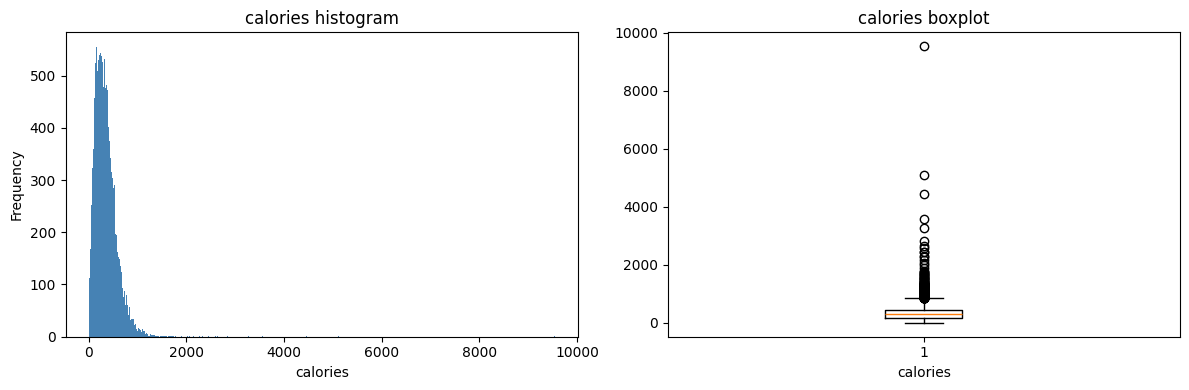

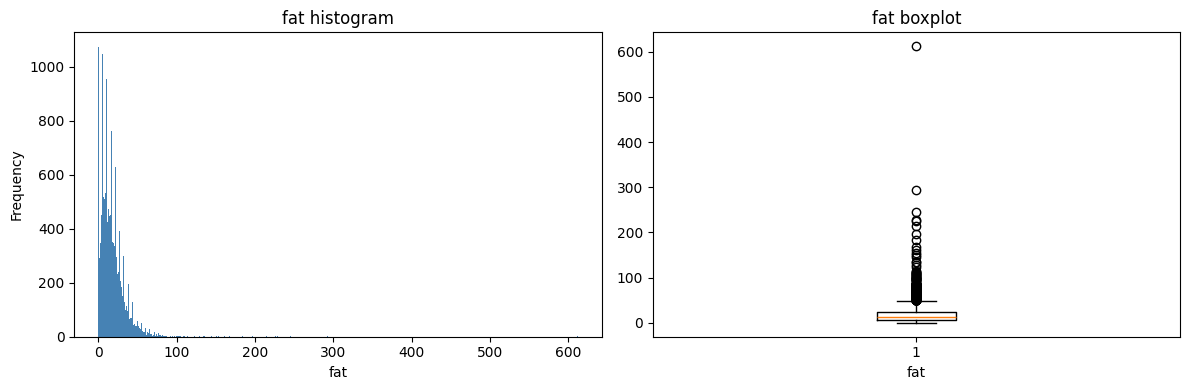

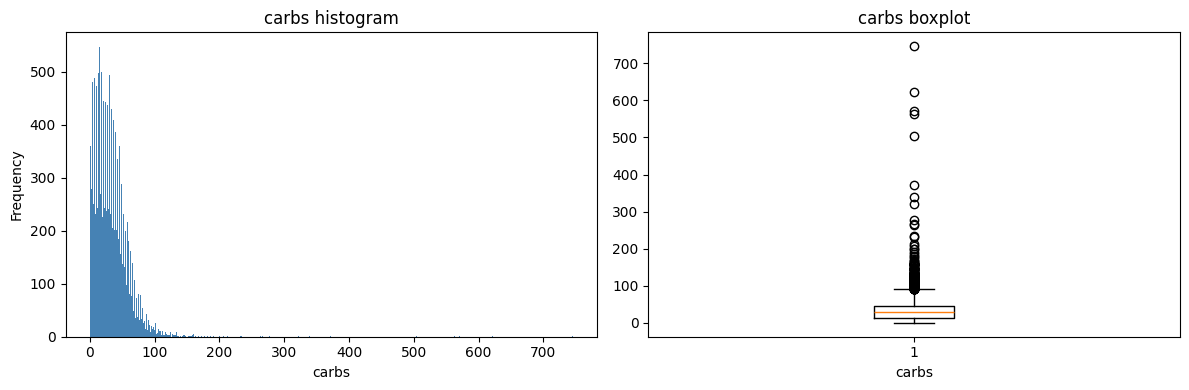

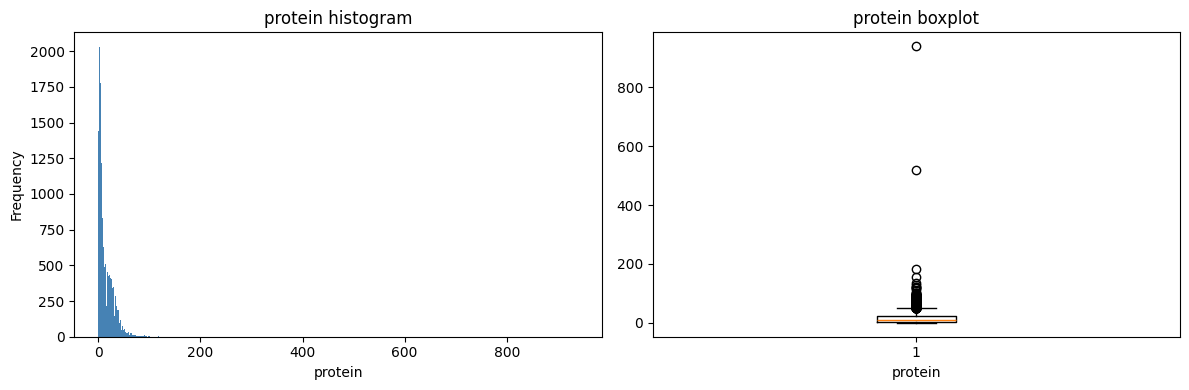

In [36]:
# Use the helper function 'plot_hist_and_box()' from visualisation.py for the macronutrient columns and the calories column
# requiring a histogram and associated boxplot diagram.
plot_hist_and_box(df, "calories")
plot_hist_and_box(df, "fat")
plot_hist_and_box(df, "carbs")
plot_hist_and_box(df, "protein")

All four nutritional variables show strong right-skewed distributions. Most recipes sit at the lower end of each scale, while a small number extend to the very high values, creating long tails shown by the outliers in the boxplots and also the scale of the x-axes on the histograms. This is as I would expect in website recipe data, assuming that everyday meals dominate the population, with more elaborate complex or large-size dishes containing lots of ingredients being in the minority within the collection, potentially describing multi-serving high-density meals like a Sunday Roast.

The strong skew and long tails confirm the presense of outliers, which could allow K-Means to detect high-calorie, high-protein, carb-heavy clusters which could be useful to website users.

Now I will look at the correlation between the **4** columns to assess whether all **4** add value, in the same way as for the time columns earlier.

<Axes: >

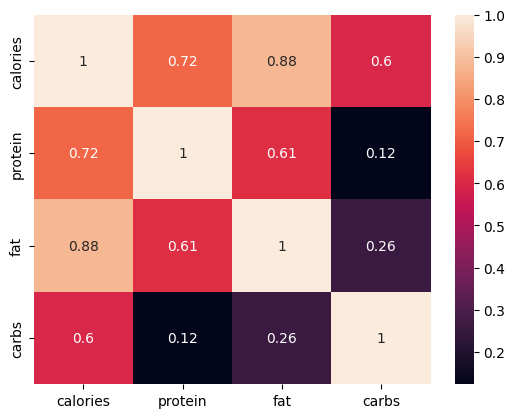

In [37]:
sns.heatmap(df[macro_cols].corr(), annot=True)  # Generate a heatmap using the macro column list generated earlier,
# 'annot=True' places the PCC corr on the grid in the square for each pairing.

The correlation heatmap shows:
- Strong correlations for *calories vs fat* and *calories vs protein* (**0.88** and **0.72** respectively) demonstrating that calories rise strongly with *fat* and *protein* and that *fat* is the strongest driver of calorie count in this dataset.
- Moderate correlations are present for *calories vs carbs* and *fat vs protein* (**0.6** and **0.61** respectively) demonstrating that calorie content rises moderately with *carbs* and that the *fat* content rises moderately with *protein* so that *high-fat* recipes also tend to be *high-protein* which could be due to the presence of meat based dishes.
- Weak correlations for *fat vs carbs* and *carbs vs protein* (**0.26** and **0.12** respectively) with *carb-heavy* dishes, for example pasta and bread not being strongly associated with *protein* or *fat*.

These graphs demonstrate that the energy/nutrition variables are not independent. *Calories*, *fat* and *protein* show moderate to high correlation with each other, however *carbs* appears to behave in a different pattern having a moderate correlation to *calories* but weak correlation to the other two. This leads to the possibility of excluding one or more column from the K-Means clustering model due to the presence of multicollinearity, and duplication of information within the model. Prior to investigating the maximum values/outliers I will assess whether all **4** columns are required.

***
<br>

#### Calories vs Macronutrients

Here I decide whether all **4** columns add value in the K-Means clustering model or whether one or more can be dropped. Due to the nature of the **4** variables I investigated the relationship between *calories*, *fat*, *protein* and *carbs* using external sources, finding out the following:


Wilbur Olin Atwater's research in the late **19th** century *[Principles of nutrition and nutritive value of foods](https://archive.org/details/CAT87202134/page/1/mode/2up)* laid the groundwork for modern nutritional science, defining the process of calculating the energy released from foods during digestion using bomb calorimeters to calculate calories. This work established the widely used Atwater factors for estimating a measure of food energy (kilocalories) with **4kcal** for every gram of protein, **4kcal** for every gram of carbohydrates and **9kcal** for every gram of fat. Testing for some of recipes above : <br> <br>

| Recipe | Composition | Calculation | Result |
|--------|-------------|-------------|--------|
| *[Yummy Stuffed Peppers](https://www.allrecipes.com/recipe/241937/yummy-stuffed-peppers/)* | (**22g** Fat, **23g** Carbs and **19g** Protein = **366kcal**) | (**22x9 + 23x4 + 19x4 = 366kcal**) | Match |
| *[Spiced Chicken Loaf](https://www.allrecipes.com/recipe/24796/spiced-chicken-loaf/)* | (**5g** Fat, **16g** Carbs, **22g** Protein = **194kcal**) | (**5x9 + 16x4 + 22x4 = 197kcal**) | **+3kcal** |
| *[Grandma Ruby's Buttermilk Pound Cake](https://www.allrecipes.com/recipe/242103/grandma-rubys-buttermilk-pound-cake/)* | (**15g** Fat, **56g** Carbs, **5g** Protein = **382kcal**) | (**15x9 + 56x4 + 5x4 = 379kcal**) | **-3kcal** |

<br>

**Limitations of the calculation:**
As noted in *Dietary Energy by *Roberts and Flaherman (2023)* the **General Atwater Factors** system was derived from a study using a small cohort of paticipants **100+** years ago, and the method tends to deviate in accuracy for calculating calories for foods high in *fibre* and/or containing *alcohol*. Link: https://www.sciencedirect.com/science/article/pii/S2161831323000972 *Note: this link must be copied and pasted into your browser*

According to *[The Food and Agriculture Organisation of the United Nations (FAO)](https://www.fao.org/4/y5022e/y5022e04.htm)* a later method **The Atwater General System** created by *Atwater and Benedict* in **1902** accounted for *alcohol* and *fibre*. If a larger study were conducted using modern technology then it may prove even more efficient at estimating the calorie count of foods, but since the dataset is limited to the nutritional variables available in the scraped data (*fat, protein and carbs*) I have chosen to use the **General Atwater Factors** formula due to its simplicity and the variables required. I have discounted **The Atwater General System** and other **Atwater** systems such as **The Extensive General Factor System** as I do not have the data required to use them such as *alcohol* or *fibre*.

To note, *Allrecipes.com* does not explicitly state that **The General Atwater Factors** calculation is used in determining the calorie count of food on their site.

To visualise a comparison of the **General Atwater Factor** calculated calories against the *Allrecipies.com* scraped dataset calories I will use a scatterplot, to help determine whether or not calories should be removed from the model. The plot produced is interactive with a zoom slider to allow the user to focus on different calorie ranges, with a hover pop-up to allow for comparison of calories for different recipes upon hover. The scatterplot contains a **45**degree red comparison line *y=x* which enables a critique of the correlation against a perfect positive correlation.

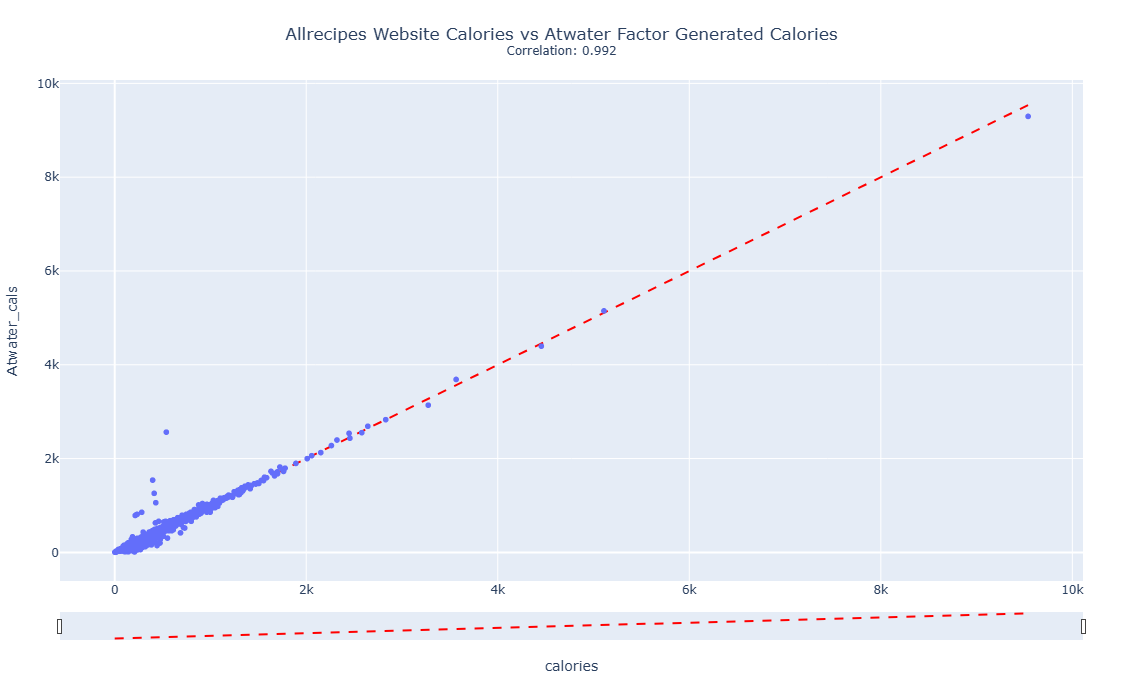

In [38]:
# Compute Atwater calories using standard factors
df["Atwater_cals"] = (df["protein"]*4 + df["carbs"]*4 + df["fat"]*9)

# Compute correlation between website calories and calculated Atwater calories
Corr = df["calories"].corr(df["Atwater_cals"])

# Build the interactive scatterplot using the helper 'plot_interactive_scatter_with_ref_line()' defined in visualisation.py
# This also saves a static version of the scatterplot for printing in the report in github, with an interactive version that the static image is linked to,
# Creating a button that opens an interactive version of the graph.
plot_interactive_scatter_with_ref_line(
    df,
    x="calories",          # define the x-column to use
    y="Atwater_cals",      # define the y-column to use
    hover_cols=["name", "calories", "Atwater_cals"],  # Decide which columns to use for the tooltip hover info
    title=("Allrecipes Website Calories vs Atwater Factor Generated Calories<br>" f"<sup>Correlation: {Corr:.3f}</sup>"), # Create the title
    save_prefix="calories_vs_atwater_interactive"  # Save PNG + HTML
)

The comparison scatterplot above shows that the website reported calories and the calculated **General Atwater Factor** calories display strong overall correlation indicating that the website generated calories are in strong agreement with the **General Atwater Factor** calories across the recipies in the population. If the plot did not display then please click the image below: <br>

<center><a href="calories_vs_atwater_interactive.html"><img src="calories_vs_atwater_interactive.png" alt="Static Plot" width="100"></a><center>
Static Preview (click for interactive version) <br>
WARNING: You may have to download the html file then open the downloaded file to use. <br><br>

Differences in the calculated calorie values and the website calorie values could be explained by rounding errors when calculating each total macronutrient content using the ingredient list quantities provided by users, also where the website may account for the other content of recipes such as *fibre* and *alcohol*. For the purposes of this analysis the correlation is strong enough here to say that *protein* + *carbs* + *fat* are strong indicators of the calorific value of the website recipes.

The Pearson Correlation Coefficient between these two variables is **0.992** which is extremely close to **1**, indicating an almost perfectly positive linear relationship. As the website reported *calories* increase, the **General Atwater Factor** *calories* increase in a nearly identical manner, proving strongly that *calories* are a linear combination of *carbs*, *fat* and *protein*, therefore *calories* are not an independent feature.

Earlier in the analysis, the time elements (*passive* and *active* time) described different behavioural events and therefore could be retained in the model, as the two time fields described how the recipe was executed. However the macronutrients (*protein*, *fat* and *carbs*) are intrinsic propoerties of the recipe, describing the composition of the food, and *calories* are a derived attribute based on those intrinsic properties of *fat*, *carbs*, *protein* plus other nutrients, as shown in the **General Atwater Factor** correlation. Calories does not describe a behaviour it describes what the recipe is, not what the person creating the recipe does.

Given that *calories* are mathematically dependent on the macronutrient composition of a recipe the *calories* add no new behavioural information, therefore adding *calories* int the K-Means clustering model would be a duplication of information from the collective macronutrient columns, ensuring multicollinearity in the model. Given that K-Means is based on Euclidean distances, adding calories into the model would dominate the distance calculations as it uses the largest scale of all of the nutrition columns (***0 to 9538***).  The numbers in calories are often much larger than those in the other macronutient fields (***fat = 0g to 612g, carbs = 0g to 746g and protein = 0g to 939g***) *calories* would have the effect of pulling the clusters along the calorie axis, meaning that the K-Means would cluster by energy/calorie density rather than by nutrient composition. It would over-weight the nutrutional information in clustering as a whole by double counting and therefore minimise the weighting of the time components. *Note: Scaling the data is discussed in ***5. Defining The Number of Clusters***.

With of the above taken into account I have decided to remove the calories column and only use it within this EDA section, not the K-Means clustering or beyond.

In [39]:
# Drop both the calories and Atwater_cals columns
df = df.drop(columns = ["calories", "Atwater_cals"])

# Display the remaining data with clickable links using the helper function 'display_html()' from utils.py
display_html(df.drop(columns = ["recipe_id", "name"]), n=5, random=True, seed=42)

,url,ingredients,fat,carbs,protein,servings,active_time,passive_time
13507,Homestyle Potato Chips,"4 medium potatoes, peeled and sliced paper-thin, 3 tablespoons salt, plus more to taste, 1 quart oil for deep frying",11.0,19.0,2.0,8.0,60,0
12068,Blackberry Cheesecake Brownies,"1 ½ cups frozen blackberries, 1/4 cup white sugar, or to taste, 1 tablespoon fresh lemon juice, 1/4 teaspoon freshly grated lemon zest, or to taste, 1 teaspoon cornstarch, 1 tablespoon water, 1/2 cup unsalted butter, melted, 1 cup firmly packed light brown sugar, 1/2 teaspoon salt, 1 large egg, at room temperature, 1 large egg yolk, at room temperature, 2 teaspoons vanilla extract, 1/2 cup unsweetened cocoa powder, 1/2 cup all-purpose flour, 1/4 teaspoon baking soda, 8 ounces full fat cream cheese, at room temperature, 1/3 cup white sugar, 1 pinch salt, 1 pinch ground nutmeg, 1 large egg white, at room temperature, 2 teaspoons fresh lemon juice, 1 teaspoon vanilla extract, 3/4 cup heavy whipping cream, at room temperature",16.0,26.0,4.0,16.0,95,290
4302,Carrot Cake with Crushed Pineapple and Pecans,"2 cups all-purpose flour, 1 tablespoon ground cinnamon, 1 teaspoon baking soda, 1 teaspoon salt, 2 cups white sugar, 1 ½ cups canola oil, 3 large eggs, 2 teaspoons vanilla extract, 2 cups finely grated carrots, or more to taste, 1 (8 ounce) can crushed pineapple, drained, 1 cup sweetened flaked coconut, 1 cup chopped pecans",38.0,60.0,5.0,12.0,50,0
4994,Rossi's Sausage Gnocchi,"1 tablespoon olive oil, 1 pound Italian sausage links, 1 tablespoon olive oil, ½ cup onion, chopped, 1 tablespoon minced garlic, 1 ½ teaspoons Italian seasoning, 1 (14 ounce) can crushed tomatoes, 2 tablespoons water, ¼ teaspoon salt, 1 teaspoon white sugar, 1 tablespoon Italian seasoning, 1 (1 pound) package fresh gnocchi, chopped fresh flat-leaf parsley, for garnish, grated Romano or Parmesan cheese",45.0,37.0,30.0,4.0,50,0
1662,Easy 4-Ingredient Low-Carb Keto Wraps,"6 eggs, 2 ¾ cups almond milk, ½ cup coconut flour, ¾ teaspoon sea salt, cooking spray",3.0,6.0,4.0,12.0,10,5


<br>

**Maximum Macronutrient Values:** Earlier I discussed how recipes can have **0**g in any of the macronutrient columns, but that they need to contain non-zero values in at least one. Here I look at the largest values in the *fat*, *carbs* and *protein* columns to decide whether these recipes can remain in the population ready for K-Means clustering. Here I will filter to show the recipes that contain the largest macronutrients values.

In [40]:
# Calculate the largest macronutrient values and filter the data using OR to retain any
extreme_macros_df = df[
    (df["fat"] == df["fat"].max()) |           # Filter for the max fat
    (df["protein"] == df["protein"].max()) |   # Filter for the max protein
    (df["carbs"] == df["carbs"].max())         # Filter for the max carbs
]

# Display the remaining data with clickable links using the helper function 'display_html()' from utils.py
display_html(extreme_macros_df.drop(columns = ["recipe_id", "name"]), n=2, random=True, seed=42)

,url,ingredients,fat,carbs,protein,servings,active_time,passive_time
12962,Chicken Parmesan Pizza,"12 frozen chicken nuggets, 1 12-inch pre-baked pizza crust, 1/2 cup marinara sauce, 2 button mushrooms, sliced, 1/2 cup shredded mozzarella cheese, 1/4 cup shredded Parmesan cheese, 6 basil leaves, cut into thin ribbons",105.0,746.0,117.0,4.0,23,0
12447,Coffee-Rubbed Steak,"1/4 cup finely ground coffee, 2 tablespoons dark brown sugar, 1 1/2 teaspoons chili powder, 2 teaspoons garlic powder, 2 teaspoons Hungarian sweet and spicy paprika, 1 1/2 teaspoons salt, 1/4 teaspoon cayenne pepper, 4 filet mignon steaks",612.0,8.0,939.0,4.0,20,5


There are only **2** recipes to see here, meaning that one of the recipes contains the highest macronutrients in **2** fields.

The *[Coffee Rubbed Steak](https://www.allrecipes.com/coffee-rubbed-steak-recipe-8675624)* recipe has the largest *fat* and largest *protein* values of all the recipes within the remaining data, this recipe has **~153g** of *fat* **234g** *protein* per steak. I decided to validate this against other recipes from the Allrecipes.com website that contained the word "mignon" in the ingredients list.

Comparing the *[Coffee Rubbed Steak](https://www.allrecipes.com/coffee-rubbed-steak-recipe-8675624)* which serves 4, to two other recipes that contain **4** filet mignon steaks.

| Recipe | Total ounces of steak | Fat per ounce of steak | Protein per ounce of steak | 
|--------|-----------------------|------------------------|----------------------------|
| *[Crab Stuffed Filet Mignon With Whiskey Peppercorn Sauce](https://www.allrecipes.com/recipe/46815/crab-stuffed-filet-mignon-with-whiskey-peppercorn-sauce/)* | **24** | **~2.4g** | **~1.7g**|
| *[Chef John's Individual Beef Wellingtons](https://www.allrecipes.com/recipe/282602/chef-johns-individual-beef-wellingtons/)* | **32** | **~3.1g** | **~1.4g** |
<br>

Ignoring the contributions of the other ingredients towards the *fat* and *protein* components, lets assume **3g** *fat* per ounce of filet mignon steak, this would mean that the *[Coffee Rubbed Steak](https://www.allrecipes.com/coffee-rubbed-steak-recipe-8675624)* called for **612g / 3g per oz = 204oz of steak** which is **~5.8kg** of steak between **4** people, which is approximately **~1.4kg** of steak per person I consider this far too much steak to be sensible and therefore it is a nutritional outlier that is unlikely to reflect realistic portion sizes and should be removed from the data.

The same exercise for *protein* at **1.6g** protein per ounce of filet mignon steak would mean **612g / 1.6g per oz = 382.5oz of steak** which is even more steak, therefore backs up the decision to remove this recipe.

In [41]:
# Filter where the ingredients contains 'filet mignon steaks' and the servings are for 4 people
df_mignon = df[
    df["ingredients"].str.contains("filet mignon steaks", case=False, na=False)
    & (df["servings"] == 4)
]

# Display the remaining data with clickable links using the helper function 'display_html()' from utils.py
display_html(df_mignon.drop(columns = ["recipe_id", "name"]), n=len(df_mignon), random=True, seed=42, sort_by="fat" )

,url,ingredients,fat,carbs,protein,servings,active_time,passive_time
3507,Broiled Filet Mignon,"cooking spray, 2 tablespoons packed light brown sugar, 2 tablespoons prepared horseradish, 1 teaspoon grated shallot, ½ teaspoon ground black pepper, 4 (4 ounce) filet mignon steaks",9.0,8.0,32.0,4.0,20,0
8462,Filet Mignon with Mushroom-Cabernet Gravy,"1 tablespoon olive oil, 2 (8 ounce; 1 inch thick) filet mignon steaks, ½ teaspoon sea salt, ¼ teaspoon ground black pepper, 1 tablespoon butter, 12 ounces sliced fresh white mushrooms, 1 large shallot, chopped, 1 cup Cabernet Sauvignon or other dry red wine, ½ cup beef broth, 1 ½ teaspoons chopped fresh thyme, 2 tablespoons water, 1 teaspoon cornstarch",20.0,8.0,20.0,4.0,40,0
12524,Blue Cheese Crusted Filet Mignon with Port Wine Sauce,"1 tablespoon butter, ½ cup minced white onion, 3 cloves garlic, minced, 1 tablespoon chopped fresh thyme, ¾ cup low-sodium beef broth, ½ cup port wine, 1 tablespoon vegetable oil, 4 filet mignon steaks (1 1/2 inch thick), ¾ cup crumbled blue cheese, ¼ cup panko bread crumbs",28.0,9.0,25.0,4.0,35,15
5986,Grilled Filet Mignon with Blue Cheese Butter,"½ cup butter, softened, ¼ cup crumbled blue cheese, 2 teaspoons fresh thyme leaves, salt and freshly ground black pepper to taste, 4 (4 ounce) filet mignon steaks, 2 teaspoons canola oil, or as needed",37.0,1.0,34.0,4.0,20,35
12969,Smothered Filet Mignon,"4 (6 ounce) filet mignon steaks, seasoned salt, to taste, cracked black pepper, to taste, ¼ cup extra-virgin olive oil, ¼ cup balsamic vinegar, 1 tablespoon Dijon mustard, 2 teaspoons dried rosemary, 1 tablespoon unsalted butter, 2 cups onion slices, 1 teaspoon white sugar, 4 ounces blue cheese, crumbled",43.0,13.0,35.0,4.0,30,30
6519,Filet Mignons with Pepper Cream Sauce,"¼ cup coarsely crushed black peppercorns, 4 (6 ounce) 1 1/2 inch thick filet mignon steaks, salt to taste, 1 tablespoon butter, 1 teaspoon olive oil, ⅓ cup beef broth, 1 cup heavy cream",47.0,5.0,28.0,4.0,25,0
2065,Crab-Stuffed Filet Mignon with Whiskey Peppercorn Sauce,"2 tablespoons olive oil, 1 teaspoon minced onion, 1 teaspoon minced green onion, 1 teaspoon minced garlic, 1 teaspoon minced celery, 1 teaspoon minced green bell pepper, 2 tablespoons shrimp stock or water, 1 (6 ounce) can crab meat, drained, 2 tablespoons bread crumbs, 1 teaspoon Cajun seasoning, 1 ¼ cups beef broth, 1 teaspoon cracked black pepper, 1 fluid ounce whiskey, 1 cup heavy cream, 4 (6 ounce) filet mignon steaks, 4 slices bacon, cooked lightly, salt and cracked black pepper to taste, 1 tablespoon olive oil, 1 clove garlic, minced, 1 teaspoon minced shallot, 1 cup crimini mushrooms, sliced, 1 fluid ounce whiskey, 1 teaspoon Dijon mustard",57.0,7.0,41.0,4.0,90,0
6091,Chef John's Individual Beef Wellingtons,"3 tablespoons unsalted butter, 10 large brown mushrooms, finely chopped, ¼ teaspoon salt, 2 tablespoons minced shallots, freshly ground black pepper to taste, 1 pinch cayenne pepper, or to taste, 3 tablespoons white wine, 2 ounces pate, 4 (8 ounce) filet mignon steaks, salt and freshly ground black pepper to taste, 2 tablespoons salted butter, 1 (17.25 ounce) package frozen puff pastry, 2 tablespoons Dijon mustard, 1 large egg, beaten, 1 teaspoon water",100.0,59.0,46.0,4.0,120,20
12447,Coffee-Rubbed Steak,"1/4 cup finely ground coffee, 2 tablespoons dark brown sugar, 1 1/2 teaspoons chili powder, 2 teaspoons garlic powder, 2 teaspoons Hungarian sweet and spicy paprika, 1 1/2 teaspoons salt, 1/4 teaspoon cayenne pepper, 4 filet mignon steaks",612.0,8.0,939.0,4.0,20,5


<br>

Filtering the recipes down to those that contain "chicken" and "pizza" shows that the amount of *carbs* in the highest carb-rated recipes *[Chicken Parmesan Pizza](https://www.allrecipes.com/chicken-parmesan-pizza-recipe-7369199)* (**746g**) is **~15** times the amount of carbs in the next highest carb-rated recipes for similar products *[BBQ Chicken Calzone](https://www.allrecipes.com/recipe/79664/bbq-chicken-calzones/)* and *[Air Fried Chicken Calzone](https://www.allrecipes.com/recipe/283515/air-fried-chicken-calzone/)*. Therefore proving that this is also a nutritional outlier that is unlikely to reflect a realistic recipe, and is more likely a data collection error and should be removed from the data

In [42]:
df_chicken_pizza = df[df["ingredients"].str.contains("chicken", case=False, na=False) &
                      df["ingredients"].str.contains("pizza", case=False, na=False)]

# Display the remaining data with clickable links using the helper function 'display_html()' from utils.py
display_html(df_chicken_pizza.drop(columns = ["recipe_id", "name"]).sort_values(["carbs"]), n=5, random=True, seed=42)

,url,ingredients,fat,carbs,protein,servings,active_time,passive_time
5217,BBQ Chicken Calzones,"4 slices bacon, 3 cups shredded, cooked chicken breast meat, ½ small onion, chopped, ⅔ cup barbeque sauce, 1 (10 ounce) can refrigerated pizza crust dough, 1 cup shredded mozzarella cheese, 2 tablespoons chopped fresh cilantro",19.0,50.0,45.0,4.0,60,0
8303,BBQ Chicken Pizza,"1 (12 inch) pre-baked pizza crust, 1 cup spicy barbeque sauce, 2 skinless boneless chicken breast halves, cooked and cubed, 1 cup sliced pepperoncini peppers, 1 cup chopped red onion, ½ cup chopped fresh cilantro, 2 cups shredded Colby-Jack cheese",16.0,38.0,23.0,8.0,35,0
9735,Buffalo Chicken Pizza Rolls,"1/2 cup shredded cooked chicken, 2 ounces low-moisture part-skim mozzarella cheese, shredded (about 1/2 cup), 2 1/2 tablespoons Buffalo-style hot sauce (such as Frank’s® RedHot), 1 (13.8 ounce) can refrigerated pizza crust dough (such as Pillsbury®), nonstick cooking spray, 2 tablespoons unsalted butter, melted, 1 teaspoon ranch dressing mix, ranch dressing or blue cheese dressing, for serving",19.0,46.0,14.0,4.0,35,0
7920,No Bake Pizza Appetizer,"1 cup prepared spinach dip, 1 (10 ounce) package prepared pizza crust, 1 cup chopped broccoli, 1 cup cooked and cubed chicken, ⅓ cup chopped green onions, 1 tomato, seeded and chopped",20.0,23.0,10.0,8.0,5,0
8491,Air-Fried Chicken Calzone,"1 teaspoon olive oil, ¼ cup finely chopped red onion, 3 cups baby spinach leaves, ⅓ cup low-sodium marinara sauce, ⅓ cup shredded cooked chicken breast, 6 ounces prepared pizza dough, ⅓ cup shredded mozzarella cheese, cooking spray",12.0,50.0,21.0,2.0,30,0


<br>

**Removing Nutritional Outliers:** The approach I will take here will be to remove any recipes that are above the **99.5th** centile in any of the macronutrient columns. Choosing this centile so that it didn't remove too many recipes that have large macronutrient values but may be correct.
<br><br>


In [43]:
# Calculate cutoff values for each macronutrient column using the quantile function
fat_cutoff = df["fat"].quantile(0.995)
protein_cutoff = df["protein"].quantile(0.995)
carb_cutoff = df["carbs"].quantile(0.995)

# Filter to retain recipes where all macronutrient values are below the cutoff values
df = df[
    (df["fat"] <= fat_cutoff) &
    (df["protein"] <= protein_cutoff) &
    (df["carbs"] <= carb_cutoff)
]

# Count rows left in the data
print(f"Number of Recipes Left: {len(df)}\n")

Number of Recipes Left: 13659



***
<br>

#### Summary of Nutritional/Energy Based EDA *(calories, fat, carbs, protein)*

The questions from above have now been answered.

**<center> Questions From Earlier </center>**
| Variable | Fact | Questions to ask | Answer/Decision |
|----------|------|------------------|----------|
| calories | Minimum = **1** | Is this possible? | Yes - Some of the recipes did show only 1kcal which was assessed as plausible due to the ingredients and kept in the model. |
| calories | Max = **9,538** | Is this a meal for **1** person? <br> How does it compare to other meals with much lower calories? <br> Does serving size have an effect on calories and macronutients? | The calorie column was removed due to multicollinearity with the macronutrient columns. <br> Serving size was not adjusted, and macronutrients were not adjusted. |
| fat, carbs and protein | Minimum = **0** | Is it **0** for all in the same meal? <br> Is it possible? <br> Should they be removed? | It was **0g** for all columns in some recipes and these were removed. <br> It was **0g** for only some of the columns in some recipes, and these were retained as not all recipes contain all macronutrients to more than a negligible level. |
| fat, carbs and protein | Very large maximum amounts | Is is possible? <br> Does serving size have an effect? | Some nutritional outliers were identifed when compared to other recipes on the website, they were removed by removing recipes where the macronutrient columns were over the **99.5th** centile (**181** recipes removed). |


- I removed the calories column due to multicollinearity in the data.
- I kept the servings column within the data, and did not adjust the serving sizes or adjust the macronutrients based on the servings column.
- I removed recipes where all macronutrients were **0g** and retained recipes where only some of the macronutrients were **0g**.
- I removed recipes where the macronutrients were greater than the **99.5th** centile as I considered those to be nutritional outliers and erroneous data entries.

I am now content with the nutritional-based variables in the data and have **13,659** recipes in the population, and therefore the numerical K-Means columns EDA and cleansing is complete.

In [44]:
# Display the remaining data with clickable links using the helper function 'display_html()' from utils.py
display_html(df.sort_values(["recipe_id"]), n=5, random=True, seed=42)

,recipe_id,name,url,ingredients,fat,carbs,protein,servings,active_time,passive_time
7275,7275,Peanut Butter Kiss Cookies,Peanut Butter Kiss Cookies,"1 cup white sugar, 1 cup creamy peanut butter, 1 large egg, 18 milk chocolate candy kisses, unwrapped",7.0,14.0,4.0,18.0,20,0
12516,12516,Microwave Quesadilla,Microwave Quesadilla,"2 flour tortillas, ½ cup shredded sharp Cheddar cheese",15.0,37.0,13.0,2.0,3,0
7607,7607,Baked Stuffed Brie with Cranberries & Walnuts,Baked Stuffed Brie with Cranberries & Walnuts,"1 small wheel of Brie (about 6 to 8 inches), chilled, ¼ cup dried cranberries, ¼ cup chopped walnuts, 1 sheet frozen puff pastry, thawed, plus extra for design, 1 large egg, 1 teaspoon water",22.0,17.0,9.0,8.0,40,60
12234,12234,Simple Beef-Flavored Gravy,Simple Beef-Flavored Gravy,"¼ cup butter, ¼ cup all-purpose flour, 1 onion, chopped, 1 ½ cups water, 3 teaspoons beef bouillon",8.0,6.0,1.0,6.0,15,0
7425,7425,One Pot Turmeric Chicken and Rice,One Pot Turmeric Chicken and Rice,"1 1/2 pounds skinless, boneless chicken breast, cut into 1 1/2-inch pieces, salt and freshly ground black pepper to taste, 1 tablespoon unsalted butter, 1 teaspoon ground turmeric, 1 cup chopped onion, 2 teaspoons peeled and minced fresh ginger, 2 cloves garlic, peeled and minced, 1 cup chopped tomato, 2 cups green beans, cut into 2-inch pieces, 1 teaspoon curry powder, 1 pinch ground cinnamon, 1/4 teaspoon ground cumin, 1 cup jasmine rice, 2 bay leaves, 2 teaspoons fish sauce, 1 1/2 cups chicken stock",11.0,28.0,59.0,4.0,60,0


***
<br>

## 4. Non-Numeric Column EDA (Exploring the Ingredients)

After checking the ingredients and name feature columns to ensure that each one contained enough text to be meaningful for interpretation (see below), all recipes can remain. To do this I set aside recipes where the ingredients list was less than **15** characters long or the name was less than **5** characters long. Some recipes contained only one ingredient, which is a valid recipe and some names are recognisable short-name food items, therefore they will remain in the model.

In [45]:
# Identify and filter on short name/ingredient recipes.
short_rows = df[
    (df["ingredients"].str.len() < 15) |   # Recipes that are less than 15 characters for ingredients. 
    (df["name"].str.len() < 5)             # Recipes that are less than 5 characters for the name.
]

# Display the remaining data with clickable links using the helper function 'display_html()' from utils.py
display_html(short_rows, n=5, random=True, seed=42)

,recipe_id,name,url,ingredients,fat,carbs,protein,servings,active_time,passive_time
1559,1559,Fresh Orange Juice,Fresh Orange Juice,4 oranges,0.0,12.0,1.0,3.0,5,0
3630,3630,Naan,Naan,"1 (.25 ounce) package active dry yeast, 1 cup warm water, ¼ cup white sugar, 3 tablespoons milk, 1 large egg, beaten, 2 teaspoons salt, 4 ½ cups bread flour, 2 teaspoons minced garlic (Optional), ¼ cup butter, melted",4.0,4.0,1.0,14.0,50,100
79,79,Sherry's Perfect Sous Vide Eggs,Sherry's Perfect Sous Vide Eggs,6 eggs,4.0,0.0,6.0,6.0,50,0
9458,9458,Biko,Biko,"4 cups uncooked glutinous white rice, 6 cups cold water, 1 (14 ounce) can coconut milk, divided, 1 ⅓ cups white sugar, 1 ⅓ cups brown sugar, 3 tablespoons coconut preserves (such as Phil Supreme®)",10.0,90.0,5.0,12.0,60,600
2579,2579,Sous Vide Hard-Boiled Eggs,Sous Vide Hard-Boiled Eggs,6 large eggs,5.0,0.0,6.0,6.0,45,0


<br>

**Exploring the Original to Final K-Means Data:** Here I generate some headline figures for all the final K-Means recipe population dataset using a helper function defined earlier.

In [46]:
# Generate headline figures for the original dataset and the final K-Means dataset using the helper function from utils.py
hf_original = headline_figures(df_original, "df_original")
hf_kmeans = headline_figures(df, "df_kmeans")

# Combine them one table to compare.
headline_combined = pd.concat([hf_original, hf_kmeans], ignore_index=True).round(3)
headline_combined

,dataset,n_rows,n_columns,n_numeric_columns,n_object_columns,total_missing_values,rows_with_any_missing,columns_with_any_missing,memory_usage_MB
0,df_original,14426,16,11,5,4065,1443,9,11.805
1,df_kmeans,13659,10,7,3,0,0,0,9.903


Exploring and cleansing the data involved:
- Reducing **16** columns down to **10**.
- Removing **4** numeric columns and **2** non-numeric columns.
- Removing **767** recipes from the original dataset.
- Going from **4065** missing values down to **0** missing values.
<br><br>

The data cleansing left me with **13,659** recipes which is **11,441** more recipes than the **2,218** recipes in alternative dataset prior to any cleansing that would have been conducted on that. This gives **~6** times the number of recipes to use in the K-Means clustering analysis which will make the analysis more accurate than if I had chosen to use the smaller sized dataset, making the above processes worthwhile.

Now I am ready for the next stage of K-Means Clustering which will involve the following sections:
- K-Means Clustering to Define Clusters (including any additional data manipulation that may be required).
- Fit the Model
- Investigate the Cluster Profile and Distribution
- Cluster Interpretation Using Ingredients
- External Validation of Cluster Themes
- Summary of Findings and Potential Future Improvements.
<br><br>

Below is a summary of the final numeric K-Means clustering columns.

In [47]:
# Display summary statistics on the numeric columns that will be used in the K-Means clustering, rounding values to 3.d.p.
df.drop(columns = "recipe_id").describe().round(3)

,fat,carbs,protein,servings,active_time,passive_time
count,13659.000,13659.000,13659.000,13659.000,13659.000,13659.000
mean,16.955,31.784,13.845,10.909,60.883,75.797
std,13.524,22.595,13.583,12.982,91.057,630.579
min,0.000,0.000,0.000,1.000,1.000,0.000
25%,7.000,14.000,3.000,4.000,25.000,0.000
50%,14.000,28.000,8.000,8.000,40.000,0.000
75%,24.000,45.000,22.000,12.000,65.000,20.000
max,79.000,129.000,75.000,300.000,3010.000,31010.000


***
<br>

## 5. Defining The Number of Clusters

The dataset contains **6** numeric columns that can be used for K-Means clustering, the *'recipe_id'* column is not used for K-Means Clustering.
- Three of the variables are nutrition based (*fat, carbs and protein*) but all serve different purposes as they describe different macronutrients within the recipe.
- Two of the variables are time based and they also serve different purposes as they describe differing behaviour types (*active and passive*).
- One of the variables is size-based (*servings*), this wasn't part of the original question but may prove useful so will be tested.

I will test a variety of column combinations through the K-Means clustering process until I am content that I have identified the best column grouping to to create meaningful cluster categories to fit the purpose of this analysis.

**Scaling The Data:** Scaling in K-Means clustering is very important to ensure all variables contribute equally to the distance calculations *[(Geron, 2019)](https://learning.oreilly.com/library/view/hands-on-machine-learning/9798341607972/)*, so that each feature has a mean of **0** and standard deviation of **1**. Scaling is essential as K-Means uses Euclidean distance, so features with large numeric ranges will dominate and distort the clustering, unless they are scaled, *[(Brown, 2024)](https://learning.oreilly.com/library/view/mastering-marketing-data/9781394258710/)*

| K-Means Feature | Numeric Range |
|-----------------|---------------|
| *passive_time* | **0 - 31,010 min** |
| *active_time* | **0 - 3,010 min** |
| *protein* | **0 - 75g** |
| *fat* | **0 - 79g** |
| *carbs* | **0 - 129g** |
| *servings* | **1 - 300 servings** |

 Without scaling the K-Means would mostly cluster on the time rather than on nutrition or servings due to the size of the scales of time. Scaling puts each feature on an equal footing by giving them all a mean of **0** and standard deviation of **1**. *[(Avila, J. and Hauck, T., 2017)](https://learning.oreilly.com/library/view/scikit-learn-machine/9781788833479/)*. 
 
To scale the data I will use *StandardScaler()* from *scikit-learn*, choosing this over *MinMaxScaler()* due to the heavy right skewed nature of all the variables, particularly the time components. *MinMaxScaler()* is more sensitive to extreme outliers *[(Geron, 2019)](https://learning.oreilly.com/library/view/hands-on-machine-learning/9798341607972/)* than *StandardScaler()* but both scalers preserve the skew of the data. With *StandardScaler()* the mean would be moved to the right by the existence of large extreme values but keep its shape. With *MinMaxScaler()* a large outlier would cause x_max to become very large, pushing the other values towards **0**, meaning that the feature would become almost flat and therefore the K-Means clustering would effectively ignore this feature altogether in comparison to other features in the model. In this model *MinMaxScaler()* would likely collapse the time feature. *StandardScaler()* allows me to use all **6** features in the K-Means clustering.

I will run the K-Means cluster selection process on the folloiwng column combinations:
1. All columns in their current form.
2. Removing the size element to only retaining macronutrient components and the time components.
3. Converting the macronutrient components into percentages to give proportional mactonutrient values (No size component)
4. Converting macronutrient components into percentages to give proportional macronutrient values (With size component)


To choose the best column combination and the best number of clusters, I use the helper functions defined in *clusterin.py*. The functions *'plot_kmeans_intertia'* and *'plot_kmeans_silhouette'* operate on the scaled features matrix (*X_scaled*) produced by *scale_features()*. They run the K-Means for a range of cluster counts **k=1-20** for intertia **k=2-21** for silhouette. They compute the inertia and silhouette scores, and plot the results to help identify the most appropriate number of clusters to use, which around the 'elbow' point for the inertia plot and at the 'peak' of the silhouette plot.

***
<br>

#### 5a. All Columns In Their Current Form

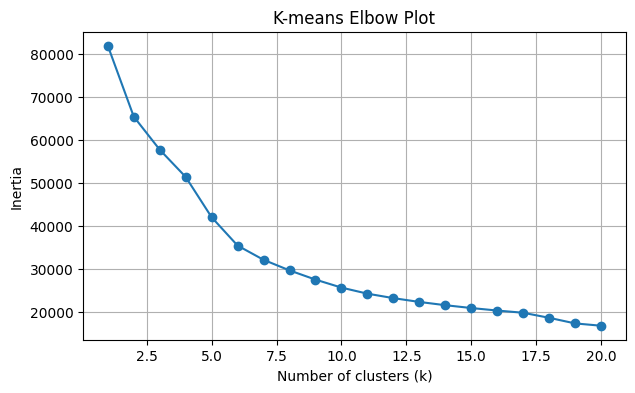

In [48]:
# Select the columns to use in the K-Means from the dataframe
df_kmeans_full = df[['recipe_id', 'fat', 'carbs', 'protein', 'passive_time', 'active_time', 'servings']].copy()
# Select which columns to drop (remember recipe_id is just a labelling column not a K-Means feature)
df_kmeans = df_kmeans_full.drop(columns = ["recipe_id"])

# Scale the data using the 'scale_features()' function from clustering.py
X_scaled, scaler = scale_features(df_kmeans)

# Call the K-Means helper function 'plot_kmeans_inertia()' from clustering.py for the chosen columns and plot the Elbow plot.
plot_kmeans_inertia(X_scaled)

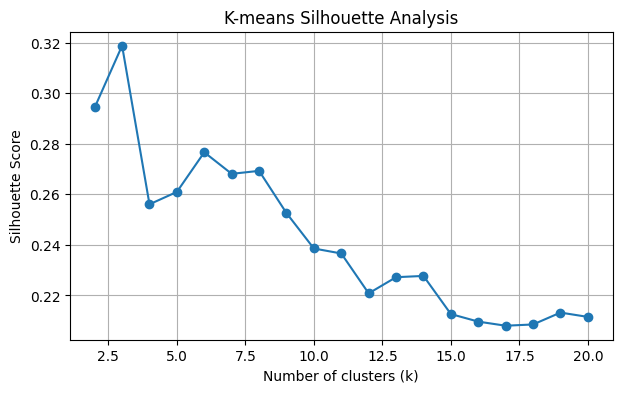

In [49]:
# Call the K-Means helper function 'plot_kmeans_silhouette()' from clustering.py for the chosen columns and plot the silhouette plot.
plot_kmeans_silhouette(X_scaled)

- The elbow plot suggests that **5** would be the best number of clusters to use as the inertia drops sharply from **k=2-5** and then the curve flattens off.
- The silhouette analysis plot suggests that **3** clusters gives the cleanest cluster structure, as the peak is at **k=3**.

Both methods are pointing to between **3** or **5** clusters when using all of the columns in their orginal form with only scaling conducted, therefore I will plot and test both, Noting that the silhouette score for **4** clusters is lower than for **5**, and as the silhouette score measures how tight clusters are and how far apart they are, *[Aggarwal and Reddy (2014)](https://learning.oreilly.com/library/view/data-clustering/9781466558229/)* I want this one to be larger for more distinct clusters.
<br>

**Using K = 3**

In [50]:
# Define the K-Means clustering model.
kmeans = KMeans(n_clusters=3, random_state=42)
# Fit the model and assign each recipe to a cluster.
cluster_labels = kmeans.fit_predict(X_scaled)

In [51]:
# Generate the silhouette score
silhouette_score(X_scaled, cluster_labels)

0.31882376278990726

The silhouette score demonstrates how well each data point fits within the cluster in which it has been placed compared to other clusters. It looks at the average distance to all other points within the same cluster for every point and the average distance to points in the next nearest cluster. The values returned are between **-1** and **1** where **1**=Perfect clustering, **0**=Overlapping clusters, **-1**=Incorrect clustering, *[(Geron, 2019)](https://learning.oreilly.com/library/view/hands-on-machine-learning/9798341607972/)*

The score here of **0.3188** indicates a moderate cluster separation with some overlapping of points between the clusters. I will test other combinations of columns and values of **k** before settling on a final model.

Next I will use Principal Component Analysis (PCA) to visualise the clusters on a **2D/3D** plot. This takes my multi-dimensional dataset of **6** columns (**6D**) and allows me to visualise the clusters to see if there is clear separation between them, before settling on a final column combination and cluster number (*k*) to use.

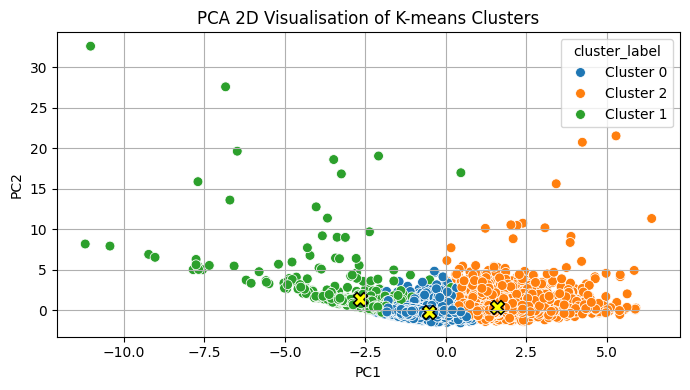

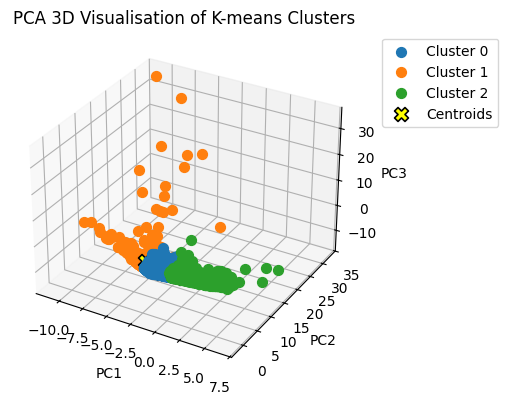

In [52]:
# Plot the 2D and 3D PCA plots using the helper functions from clustering.py
plot_pca_2d(X_scaled, cluster_labels)
plot_pca_3d(X_scaled, cluster_labels)

These plots show the **3** clusters, with the cluster **0** in the middle, cluster **1** stretching out to the right and cluster **2** streching out to the left on the **2D** plot, the **3D** plot shows the clusters in the opposite direction here. The cluster centroids, the mean average of all points in the cluster, are marked by a yellow X outlined in black. The markers are not fully visible on the **3D** plot, but a sense of their location can be seen on the **2D** plot. The centroids for cluster are evenly spaced but could be considered close together which backs up the overlap suggested by the silhouette score. From looking at the **2D** plot my instinct is that cluster **2** is the largest cluster, but the **3D** plot is contradictory in that cluster **2** appears to be the largest. In the **2D** plot overlap can be seen in some of the green dots sitting in front of some of the blue dots, however its important to know that from a different perspective (looking at the **3D** plot there's no points that visually seem like they are sitting inside of another cluster.

Next I will generate a model with **5** clusters to compare against this one, in an attempt to find a better model.
<br>

**Using K = 5**

In [53]:
# Define the K-Means clustering model.
kmeans = KMeans(n_clusters=5, random_state=42)
# Fit the model and assign each recipe to a cluster.
cluster_labels = kmeans.fit_predict(X_scaled)

In [54]:
# Generate the silhouette score
silhouette_score(X_scaled, cluster_labels)

0.2609629479804213

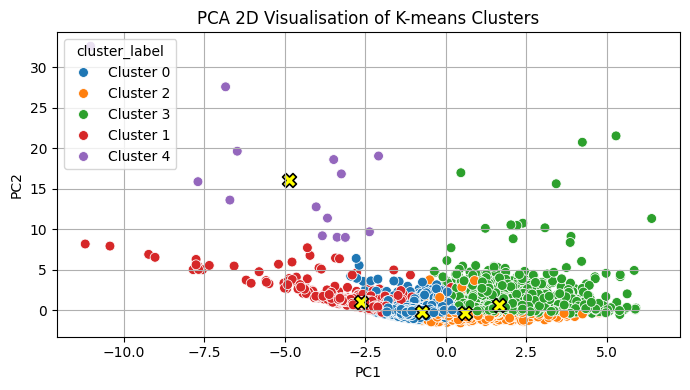

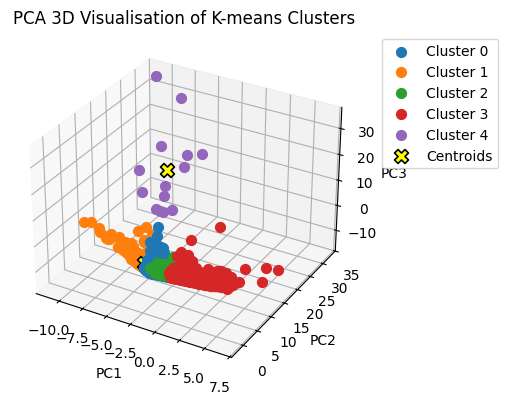

In [55]:
# Plot the 2D and 3D PCA plots using the helper functions from clustering.py
plot_pca_2d(X_scaled, cluster_labels)
plot_pca_3d(X_scaled, cluster_labels)

This second set of cluster plots shows **5** clusters, the silhouette score is now lower at **0.2609** meaning that the cluster separation is worse in the main, and there is more overlap between the clusters. However it is clear from the above diagrams that **cluster 4** in purple is a distinct cluster showing no overlap with the other clusters. The visuals point to **5** clusters being the best number so far, but before deciding on whether this columns/cluster number combination is the one that will be used for the final model, I will conduct the same process again with another column combination.

I will test whether removing the size element (*servings*) has an impact on the number of clusters and the separation between them, so that the K-Means focusses only on time and macronutrient composition. To do this I will:

- drop the serving size column,
- conduct the scaling again as the feature matrix changed when one column was removed,
- generate the Elbow and silhouette plots to assess which cluster size(s) to test,
- fit the model,
- generate the silhouette score,
- assess the suitability of this model.

***
<br>

#### 5b. Removing the Size Elemenet (Only Macronutrients and Time)

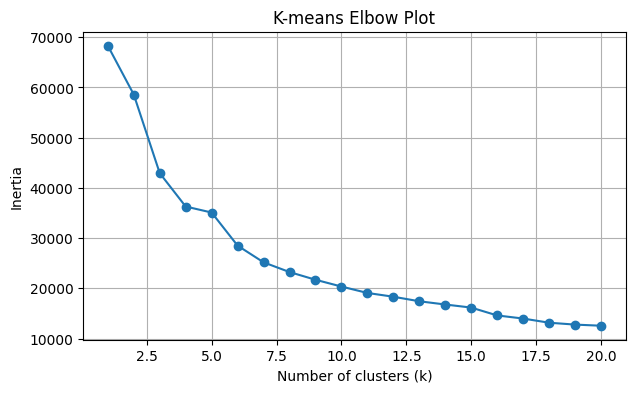

In [56]:
# Select the columns to use in the K-Means from the dataframe
df_kmeans_no_size = df[['recipe_id', 'fat', 'carbs', 'protein', 'passive_time', 'active_time']].copy()
# Select which columns to drop (remember recipe_id is just a labelling column not a K-Means feature)
df_kmeans = df_kmeans_no_size.drop(columns = ["recipe_id"])

# Must scale again using the 'scale_features()' helper function from clustering.py as the feature matrix changed when one column was removed.
X_scaled, scaler = scale_features(df_kmeans)

# Call the K-Means helper function 'plot_kmeans_inertia()' from clustering.py for the chosen columns and plot the Elbow plot.
plot_kmeans_inertia(X_scaled)

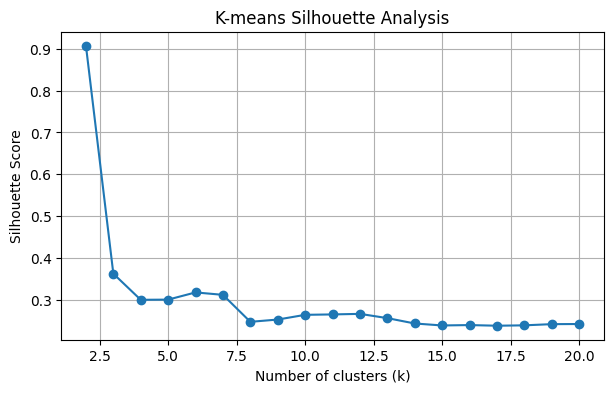

In [57]:
# Call the K-Means helper function 'plot_kmeans_silhouette()' from clustering.py for the chosen columns and plot the silhouette plot.
plot_kmeans_silhouette(X_scaled)

These plots show that the data naturally wants to use **2** clusters.
- The Elbow plot drops sharply from **k=2-4** then starts to flatten off.
- The silhouette plot has the highest peak at **k=2**

I will fit the model on **2** clusters, generate the silhouette score and plot the PCA graphs to observe visually and assess this proposed model.
<br>

**Using K = 2**

In [58]:
# Define the K-Means clustering model.
kmeans = KMeans(n_clusters=2, random_state=42)
# Fit the model and assign each recipe to a cluster.
cluster_labels = kmeans.fit_predict(X_scaled)

In [59]:
# Generate the silhouette score
silhouette_score(X_scaled, cluster_labels)

0.9075802989962182

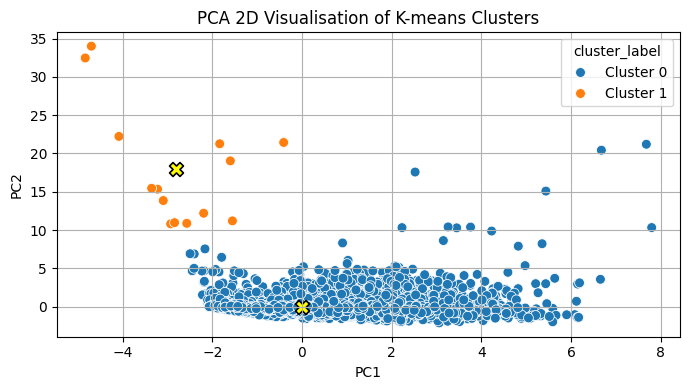

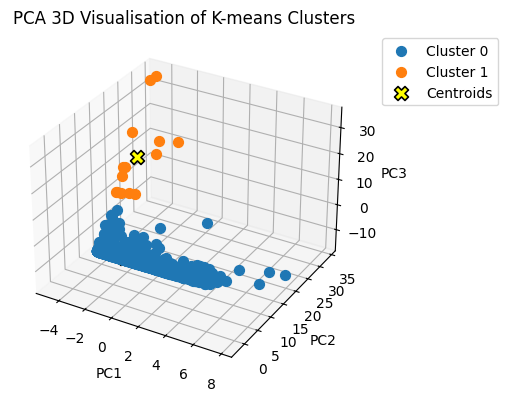

In [60]:
# Plot the 2D and 3D PCA plots using the helper functions from clustering.py
plot_pca_2d(X_scaled, cluster_labels)
plot_pca_3d(X_scaled, cluster_labels)

These graphs show **2** clear distinct clusters with one very large cluster and one much smaller cluster. The silhouette score is **0.9076** which describes a very strong structure with clear separation between the clusters. Despite these diagrams and the silhouette score for this model, I don't consider it to be the best of the models so far. Even though they are visibly well separated and the silhouette score is very strong, the larger cluster is so large it contains almost all recipes within the population and therefore becomes meaningless as a cluster as it would not be usable for separating out recipes based on user needs.

I will now test converting the macronutrient columns into percentages.

***
<br>

#### 5c. Converting Macronutrients into Percentages (No Size)

To attempt to find a better clustering model I will convert the macronutrient columns into proportions of the macronutrients for the whole recipe, so that larger recipes can be compared to smaller recipes, where for example **100g** of carbs may be **80%** of the carbs in one recipe, but **20g** of carbs may be **80%** of the carbs in another recipe. Both would be considered carb-heavy meals but with different absolute measures of carbs. Conversely a recipe where **100g** of carbs is **30%** of the macronutrient composition of a recipe would not be considered carb-heavy.

Next I will:
- ensure the size variable is not in the variable list,
- calculate the mactonutrient percentage values,
- drop the original macronutrient columns and the newly created macro_total column,
- conduct the scaling again as the feature matrix will change with the newly generated columns,
- generate the elbow and silhouette plots,
- fit the model,
- generate the silhouette score,
- assess the suitability of this model.

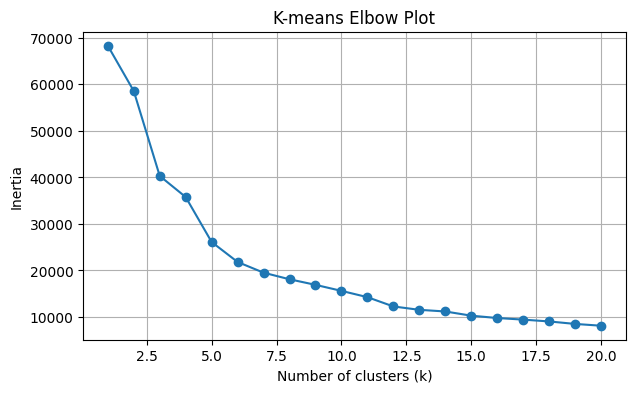

In [61]:
# Select the columns to use in the K-Means from the dataframe
df_kmeans_pct_no_size = df[['recipe_id', 'fat', 'carbs', 'protein', 'passive_time', 'active_time']].copy()
# Select which columns to drop (remember recipe_id is just a labelling column not a K-Means feature)
df_kmeans = df_kmeans_pct_no_size.drop(columns = ["recipe_id"])

# Remove the size element of the signal of the macronutrients and reduce the variables down to a nutritional
# composition by calculating the percentages each macronutrient takes for the whole recipe,
# i.e. 25% carbs, 30% fat and 45% protein for the whole dish.
df_kmeans["macro_total"] = (
    df_kmeans["fat"] +
    df_kmeans["protein"] +
    df_kmeans["carbs"]
)

# Add in the percentages for the macros.
df_kmeans["fat_pct"] = df_kmeans["fat"] / df_kmeans["macro_total"] * 100
df_kmeans["protein_pct"] = df_kmeans["protein"] / df_kmeans["macro_total"] * 100
df_kmeans["carbs_pct"] = df_kmeans["carbs"] / df_kmeans["macro_total"] * 100


# Drop the original macronutrient columns
df_kmeans = df_kmeans.drop(columns = ["macro_total", "fat", "carbs", "protein"])


# Must scale again using the 'scale_features()' helper function from clustering.py as the feature matrix changed when new columns were created
# and old ones wer eremoved.
X_scaled, scaler = scale_features(df_kmeans)

# Call the K-Means helper function 'plot_kmeans_inetria()' from clustering.py for the chosen columns and plot the 'Elbow' plot.
plot_kmeans_inertia(X_scaled)

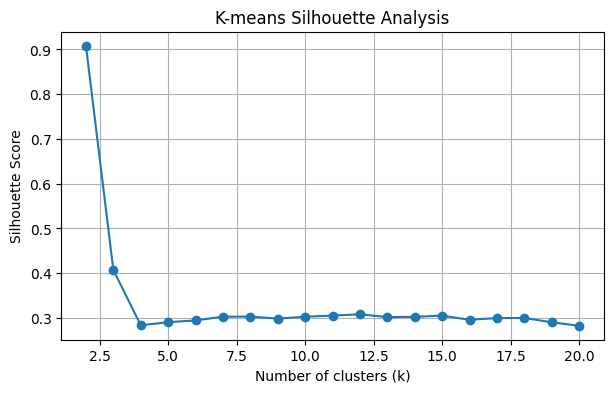

In [62]:
# Call the K-Means helper function 'plot_kmeans_silhouette()' from clustering.py for the chosen columns and plot the silhouette plot.
plot_kmeans_silhouette(X_scaled)

- The elbow plot shows that the best number of clusters will be between **k=3-5** as k drops sharply from **2-4** and then begins to flatten.
- The silhouette plot shows that the best number of clusters is **k=2** as that is where the graph peaks.

I will now test the model using **k=2**.
<br>

**Using K = 2**

In [63]:
# Define the K-Means clustering model.
kmeans = KMeans(n_clusters=2, random_state=42)
# Fit the model and assign each recipe to a cluster.
cluster_labels = kmeans.fit_predict(X_scaled)

In [64]:
# Generate the silhouette score
silhouette_score(X_scaled, cluster_labels)

0.9084369738479251

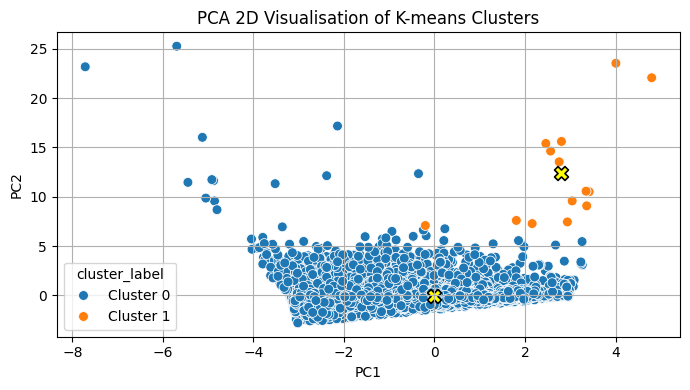

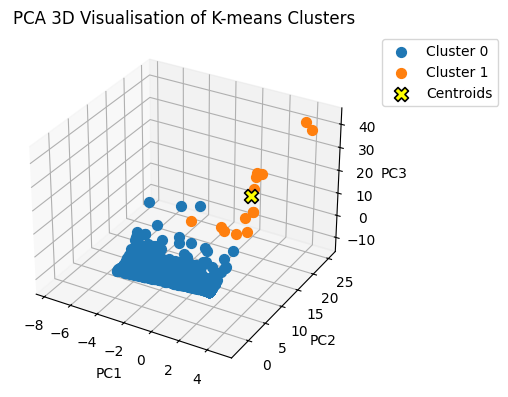

In [65]:
# Plot the 2D and 3D PCA plots using the helper functions from clustering.py
plot_pca_2d(X_scaled, cluster_labels)
plot_pca_3d(X_scaled, cluster_labels)

For the same reasons that option **5b** was unsuitable I will disregard this option, despite the strong silhouette score of **0.9084** one of the clusters (**cluster 0**) contains almost all recipes in the population therefore renderring the clustering useless for grouping the recipes into meaningful categories for user needs.

I will move on to my final option, using macronutrient percentages with the serving size retained.

Next I will:
- ensure the size column is within the model,
- calculate the mactonutrient percentage values,
- drop the original macronutrient columns and the newly created macro_total column,
- conduct the scaling again as the feature matrix will change with the newly generated columns,
- generate the elbow and silhouette plots,
- fit the model,
- generate the silhouette score,
- assess the suitability of this model.

***
<br>

#### 5d. Converting Macronutrients into Percentages (With Size)
To attempt to find a better clustering model I will now bring the size component back into the model and convert the macronutrient columns into percentages so that they each represent a portion of the nutritional composition of the whole recipe.

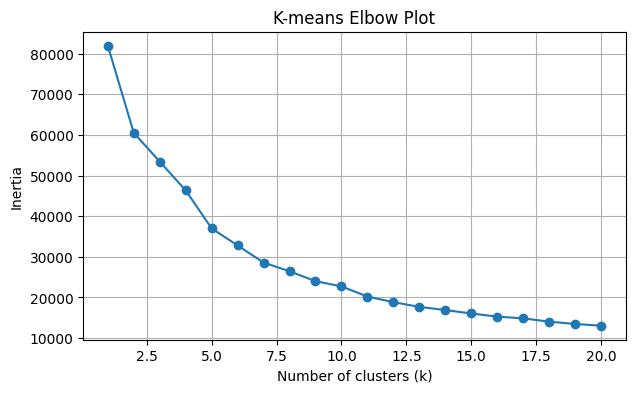

In [66]:
# Select the columns to use in the K-Means from the dataframe
df_kmeans_pct = df[['recipe_id', 'fat', 'carbs', 'protein', 'passive_time', 'active_time', 'servings']].copy()
# Select which columns to drop (remember recipe_id is just a labelling column not a K-Means feature)
df_kmeans = df_kmeans_pct.drop(columns = ["recipe_id"])

# Remove the size element of the signal of the macronutrients and reduce the variables down to a nutritional
# composition by calculating the percentages each macronutrient takes for the whole recipe,
# i.e. 25% carbs, 30% fat and 45% protein for the whole dish.
df_kmeans["macro_total"] = (
    df_kmeans["fat"] +
    df_kmeans["protein"] +
    df_kmeans["carbs"]
)

# Add in the percentages for the macros.
df_kmeans["fat_pct"] = df_kmeans["fat"] / df_kmeans["macro_total"] * 100
df_kmeans["protein_pct"] = df_kmeans["protein"] / df_kmeans["macro_total"] * 100
df_kmeans["carbs_pct"] = df_kmeans["carbs"] / df_kmeans["macro_total"] * 100


# Drop the original macronutrient columns
df_kmeans = df_kmeans.drop(columns = ["macro_total", "fat", "carbs", "protein"])


# Must scale again using the helper function 'scale_features() from clustering.py as the feature matrix changed when new columns were created
# and old columns ones were removed.
X_scaled, scaler = scale_features(df_kmeans)

# Call the K-Means helper function 'plot_kmeans_inertia()' from clustering.py for the chosen columns and plot the Elbow plot.
plot_kmeans_inertia(X_scaled)

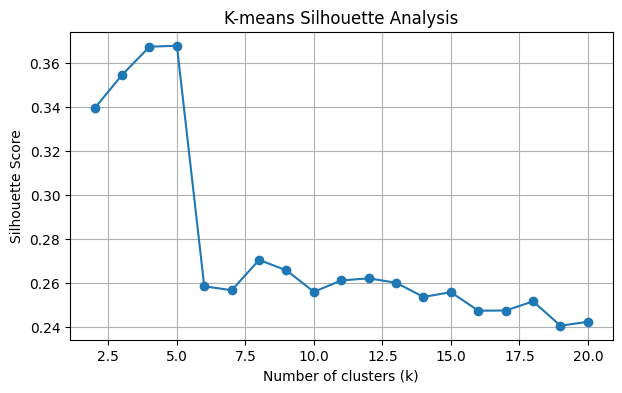

In [67]:
# Call the K-Means helper function 'plot_kmeans_silhouette()' from clusterin.py for the chosen columns and plot the silhouette plot.
plot_kmeans_silhouette(X_scaled)

- The elbow plot drops sharply between **2 and 6**, where it then starts to flatten off
- The silhouette plot peaks at **4-5** then drops low and stays low from **6** onwards

I will now plot the PCA visuals for **k=5** and calculate the silhouette score then assess the model as a potential candidate.
<br>

**Using K = 5**

In [68]:
# Define the K-Means clustering model.
kmeans = KMeans(n_clusters=5, random_state=42)
# Fit the model and assign each recipe to a cluster.
cluster_labels = kmeans.fit_predict(X_scaled)

In [69]:
# Generate the silhouette score
silhouette_score(X_scaled, cluster_labels)

0.36791127464291074

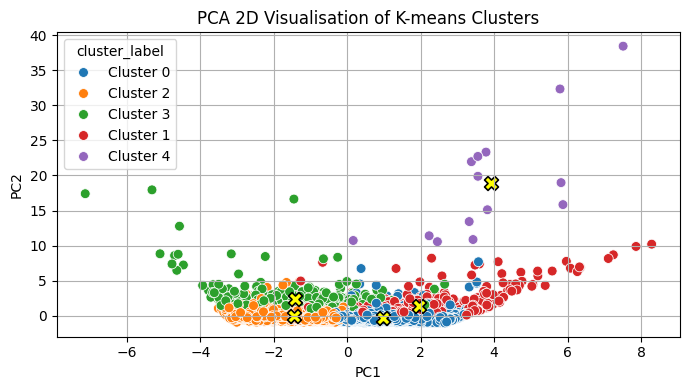

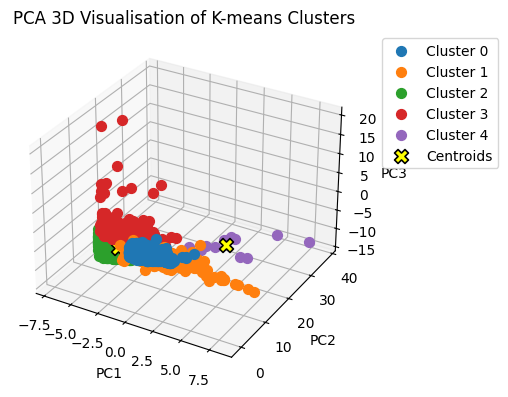

In [70]:
# Plot the 2D and 3D PCA plots using the helper functions.
plot_pca_2d(X_scaled, cluster_labels)
plot_pca_3d(X_scaled, cluster_labels)

The Silhouette score (**0.3679**) for **k=5** when macronutrients were converterted to proportions and the size (servings) was retained indicates that, although the clusters exist and are meaningful, they are very close together and there is not always clear separation with some overlap between the groupings. (*Note: I also tested **k=4** but the silhouette score reduced slightly to **0.367459** therefore I have excluded it as an option.*)

This is the type of clustering and overlapping behaviour I expected due to the size and topic of the data. The metrics being used along with the distributions displayed in the earlier EDA, with a strong right skew to all measures indicated that a lot of recipes would display similar values. For example cooking times overlapping between recipes with multiple recipes sharing the same total time but differing *passive* and *active* times summing to that *total* time, and sometimes with the exact same timings across the piece. Also the macro values and percentages overlapping between recipes with multiple recipes displaying the same macronutrient values, likewise for the serving sizes, especially among the lower sized recipes.

Both PCA plots show **5** clusters with labels and centroids. The centroids for cluster **1** and **2** are quite close together suggesting some overlap between the clusters, likewise for the centroids between cluster **0** and **3**. Cluster **4** appears to be very well separated from the others as the centroid sits far outside of the main clustering group, however this cluster also appears to be a lot smaller than the others. From looking at the **3D** plot cluster **1** appears to be the biggest, but this cannot be proven solely based on these plots as there could be a lot of overlapping points hidden within the other clusters in the plots, therefore I will generate a cluster profile table after fitting the final model to the Allrecipes dataframe to prove the sizes of the clusters and investigate the clusters further.


All of the above evidence points to this combination of feature variables and **k=5** as the best option for the K-Means clustering model. Even though in **5a** a model with **5** clusters was used the silhouette score for that combination of columns was **0.26096**. Therefore this model **5d** brings more a good balance of the number of clusters with the best silhouette score for that number of clusters. Two of the other models demonstrated much better silhouette scores (**~0.9**) but they were deemed unsuitable due to the distribution of recipes between the two clusters, with almost the whole population of recipes featuring in one cluster, therefore renderring the idea of clustering useless.

This model with the highest silhouette score of **0.3679** for **k=5** clusters is the most suitable model out of all of the potential suitable models that were tested, I will now fit this model to the Allrecipes data.

***
<br>

## 6. Fit the Model

Here I fit the chosen K-Means clustering model to df_kmeans as this contains the *fat_pct*, *carb_pct* and *protein_pct* columns required by the model, and the original *fat*, *carb* and *protein* columns have been dropped, (see below), it also does not contain the extra columns such as *recipe_id, name, url and ingredients* that are contained in the Allrecipes df. As I will be using the df_kmeans that was last tested on then I do not need to scale the data again.

**Notes:**
- This is only possible as it was the last df_kmeans that I tested, if the best model was any of the other models then a different approach would be taken.
- I did not rebuild df_kmeans from df.
- I did not change the feature matrix.
- I did not alter the rows or columns.


After fittin the model to df_kmeans I will join the *cluster* column and the *x_pct* columns to the Allrecipes df.

After joining the *cluster* column and the *x_pct* columns to the the Allrecipes dataframe I will have created a single source of truth, having all required information contained within, allowing for this dataframe to be used throughout the next phase of interpretting the clusters using the recipe ingredients.

**Reminder of the Model Fitting Steps already conducted to create df_kmeans:**
- macronutrient variables converted to percentages of the whole recipe instead of raw values,
- original macronutrient columns removed
- servings (size) included,
- time-based behavioural variables included,
- variables scaled using *StandardScaler()*.

In [71]:
df_kmeans.head(5)     # Show the first 5 rows of df_kmeans to demonstrate what columns it contains.

,passive_time,active_time,servings,fat_pct,protein_pct,carbs_pct
0,0,55,16.0,30.232558,13.953488,55.813953
1,480,15,8.0,37.804878,9.756098,52.439024
2,0,85,4.0,25.714286,28.571429,45.714286
3,0,60,8.0,11.111111,23.456790,65.432099
4,0,125,8.0,34.375000,29.687500,35.937500


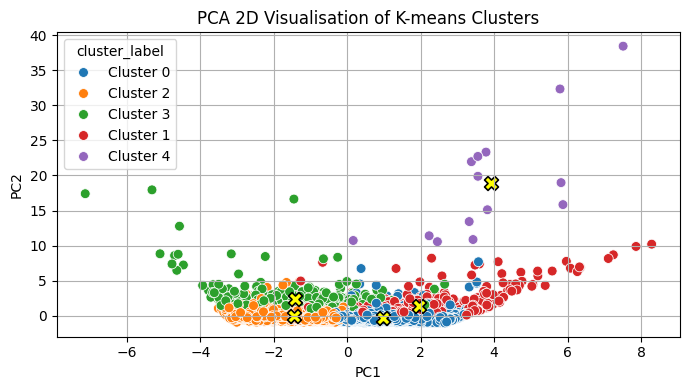

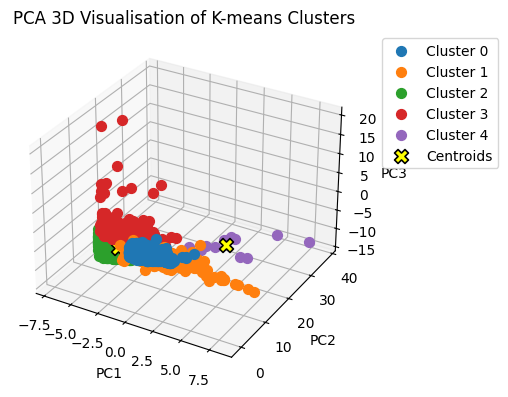

In [72]:
# Define the K-Means clustering model.
kmeans = KMeans(n_clusters=5, random_state=42)
# Fit the model and assign each recipe to a cluster.
df_kmeans["cluster"] = kmeans.fit_predict(X_scaled)

# Plot the 2D and 3D PCA plots using the helper functions.
plot_pca_2d(X_scaled, df_kmeans["cluster"])
plot_pca_3d(X_scaled, df_kmeans["cluster"])

In [73]:
# Generate the silhouette score to check that I used the correct procedures
silhouette_score(X_scaled, cluster_labels)

0.36791127464291074

In [74]:
df_kmeans.head(5)

,passive_time,active_time,servings,fat_pct,protein_pct,carbs_pct,cluster
0,0,55,16.0,30.232558,13.953488,55.813953,0
1,480,15,8.0,37.804878,9.756098,52.439024,0
2,0,85,4.0,25.714286,28.571429,45.714286,2
3,0,60,8.0,11.111111,23.456790,65.432099,0
4,0,125,8.0,34.375000,29.687500,35.937500,2


Now will join the *x_pct* and *cluster* columns from the K-Means clustering model to the Allrecipes dataframe which adds a cluster label to each recipe showing which cluster they were assigned to, and proportional macronutrient columns as these will be used when investigating the clusters. Note: As I didn't change the order of the rows of recipes and as Pandas aligns dataframes by rows, therefore the alignment is identical between df_kmeans and df so the following code will work.

In [75]:
# Add the macronutrient percentage columns into the allrecipes dataframe.
cols_to_copy = ["fat_pct", "carbs_pct", "protein_pct", "cluster"]
df[cols_to_copy] = df_kmeans[cols_to_copy]
# Display the first 5 recipes for validation purposes using the helper function 'display_html()' from utils.py
display_html(df.round(3).drop(columns=["name", "ingredients"]), n=5, random=False)

,recipe_id,url,fat,carbs,protein,servings,active_time,passive_time,fat_pct,carbs_pct,protein_pct,cluster
0,0,Chewy Whole Wheat Peanut Butter Brownies,13.0,24.0,6.0,16.0,55,0,30.233,55.814,13.953,0
1,1,Pumpkin Pie Eggnog,31.0,43.0,8.0,8.0,15,480,37.805,52.439,9.756,0
2,2,Eggs Poached in Tomato Sauce,18.0,32.0,20.0,4.0,85,0,25.714,45.714,28.571,2
3,3,Minestrone Casserole,9.0,53.0,19.0,8.0,60,0,11.111,65.432,23.457,0
4,4,Yummy Stuffed Peppers,22.0,23.0,19.0,8.0,125,0,34.375,35.938,29.688,2


Above is the Allrecipes dataframe showing all columns from the EDA cleansing section along with the cluster each recipe was assigned to, and the engineered macronutrient percentage columns. This dataframe will be used in the next sections for investigating the profiles of the clusters to develop a theme and description for each cluster.

***
<br>

## 7. Investigate the Cluster Profile and Distribution

To investigate clusters that have been generated in the K-Means clustering process I will create a table containing the mean raw values for each variable for each cluster, along with counts of the number of recipes contained within each cluster, this will allow me to discuss profile of each cluster within the population and compare clusters to one another based on the average recipe within each cluster.

In [76]:
# List of all the feature columns that were used in the clustering
feature_cols = ['passive_time', 'active_time', 'servings', 'fat_pct', 'protein_pct', 'carbs_pct']

# Count the number of recipes in each cluster and calculate the percentage of the whole population within each cluster.
cluster_counts = df.groupby("cluster").size().rename("count") 
cluster_percentage = (cluster_counts / len(df) * 100).rename("percentage")

# Generate the mean value for each column grouped by cluster, and join the cluster counts and cluster percentages to the cluster profile table.
# Round the figures in the table to 1.d.p for interpretability.
cluster_profile = (df.groupby("cluster")[feature_cols].mean().join(cluster_counts).join(cluster_percentage).round(1))
cluster_profile

,passive_time,active_time,servings,fat_pct,protein_pct,carbs_pct,count,percentage
cluster,,,,,,,,
0,55.7,45.6,9.7,18.9,12.2,68.9,7279,53.3
1,157.4,48.9,53.2,21.5,7.0,71.5,650,4.8
2,46.1,52.8,7.4,38.7,32.7,28.6,5283,38.7
3,116.9,433.5,9.3,25.4,36.1,38.5,433,3.2
4,16662.3,84.6,42.9,8.7,12.9,78.4,14,0.1


#### Cluster Profile Interpretation:

| Cluster | Time | Serving Size | Macronutrients | Cluster Size | Overall |
|---------|------|--------------|----------------|------|---------|
| 0 | Passive time average is **55.7 minutes** which could represent some short marinating/resting/baking time or time cooking in an oven, this is close to cluster **2**. <br> Average active time is the lowest of all the clusters at **45.6 minutes** but close to clusters **1** and **2**. These dishes appear to be generally low-effort everyday dishes. | Average serving size is **~9.7 servings**, these are moderate in size and close to clusters **2** and **3** most of the dishes could be family-friendly recipes. | **Fat proportion** is modest with an average of **18.9%**, protein proportion is lower than the fat proportion with an average of **12.2%**. Carbs dominate the macronutrient profile at **68.9%%**. The fat proportion is similar to that of cluster **1**, the protein proportion is similar to cluster **4** and the carbs proportion is similar to cluster **1** | This cluster group contains more recipes than any other cluster, with over half of the population (**~53%**) assigned to this cluster, it gives the impression that these recipes are everyday meals that could be regularly used and popular styles across the site. |This cluster is close to cluster **1** in many respects but not in the passive time, serving size or cluster size. It is close to cluster **2** in both timing variables and the serving size but not in the macronutrient conposition. It is also close to cluster **3** in the servings size. This cluster could represent everyday simple recipes such as a family main weeknight evening meal, recipes that are quick to prepare, low effort and have moderate serving sizes. Recipes that are more carb-centric than fat or protein but not extremely carb-heavy. The size of the population would make sense for the style of recipe suggested here in that they may be the more searched for and more popular type of recipe that users are looking for or sharing. |
| 1 | Passive time averages **157.4 minutes**, which is noticeably higher (around **3** times higher) than clusters **0**, and **2**, approximately **40 minutes** higher than cluster **3**, but far below the extreme passive time of cluster **4**. This suggests longer resting, rising, or slow‑cooking phases. Active time is **48.9 minutes**, similar to clusters **0** and **2**, indicating moderate hands‑on effort. These recipes appear to require longer waiting but not significantly more active preparation. | The average serving size is **~53** servings, which is dramatically larger than all other clusters except cluster **4**, which strongly suggests large batch-cooking, bulk-preparation, or recipes intended for groups, events, or storage. | Fat proportion averages **21.5%**, similar to cluster **0** and **3**. Protein proportion is the lowest of all clusters at **7.0%**, while carbohydrates dominate at **71.5%**, similar to cluster **0** and cluster **4**. This macronutrient profile is consistent with baked goods, dough‑based recipes, or other carbohydrate‑heavy dishes. | This cluster contains **~4.8%** of the dataset, making it a relatively small but meaningful group. The cluster size suggests that while these recipes are less common, they represent a distinct style of cooking. | Cluster **1** is most similar to cluster **0** in macronutrient composition but differs substantially in serving size and passive time. It shares the long‑wait characteristic of cluster **3**, but not the protein‑rich profile. The extremely large serving sizes strongly indicate bulk‑prepared, high‑carbohydrate recipes such as breads, doughs, or large desserts. These may be recipes intended for gatherings, events, or batch cooking for storage. |
| 2 | Passive time averages **46.1 minutes**, the lowest of all clusters but close to cluster **0**, suggesting minimal resting or waiting. Active time is **52.8 minutes**, slightly higher than clusters **0** and **1**, indicating moderate hands‑on preparation. These recipes appear to be everyday dishes with a little more active cooking involved. | Average serving size is **~7.4** servings, the smallest of all clusters which suggests individual or small‑household meals rather than large‑batch cooking. | This cluster has the highest fat proportion at **38.7%** and the highest protein proportion at **32.7%**, while carbohydrates are the lowest at **28.6%**. This macronutrient profile is distinct from all other clusters as the profile appears more balanced across the piece. This strongly suggests protein‑rich, high-fat, lower‑carb dishes such as meat‑based meals, these could be meals representative of a high‑protein or keto‑leaning diet. | This cluster contains **~38.7%** of the dataset, making it the second‑largest group. It represents a substantial portion of the recipe population. | Cluster **2** is closest to cluster **0** in timing and serving size but differs dramatically in macronutrient composition. It is also similar to cluster **3** in protein proportion but not in passive time. This cluster likely represents everyday main meals that are protein‑dense and lower in carbohydrates, such as meat dishes, high‑protein stir‑fries, or low‑carb recipes. Its large size suggests that these types of recipes are widely used and popular. |
| 3 | Passive time averages **116.9 minutes**, which is higher than clusters **0** and **2**, but lower than cluster **1** and far below the extreme passive time of cluster **4**. This suggests some resting, marinating, or slow‑cooking phases. However, the defining characteristic of this cluster is the very high active time of **433.5 minutes**, the highest of all clusters by a substantial margin. This indicates that these recipes require significant hands‑on preparation, potentially involving multiple steps, long cooking processes, or complex techniques. | Average serving size is **~9.3** servings, which is similar to clusters **0** and **2**, suggesting these are family‑sized or household‑sized dishes rather than bulk‑prepared recipes. | Fat proportion averages **25.4%**, higher than clusters **0** and **1**, but lower than cluster **2**. Protein proportion is **36.1%**, the second highest after cluster **2**, and carbohydrates average **38.5%**, giving this cluster a quite balanced macronutrient profile. This combination suggests hearty, protein‑rich dishes with moderate carbs and fats. | This cluster contains **~3.2%** of the dataset, making it a small but distinct group. | Cluster **3** is most similar to cluster **2** in terms of protein content but differs dramatically in active time, indicating that these are labour‑intensive, protein‑rich recipes. It shares serving‑size similarities with clusters **0** and **2**, but its time requirements set it apart. These recipes may involve slow cooking, multi‑stage preparation, or complex methods such as reductions, braising, or multi‑component dishes. The small cluster size suggests these are less common, more specialised recipes that require significant effort and time investment. |
| 4 | Passive time averages **16,662.3 minutes** (**~11.5 days**), far exceeding all other clusters. This indicates multi‑day processes such as fermentation, pickling, curing, or resting. Active time is **84.6 minutes**, the highest of all clusters, suggesting more complex preparation steps. | Average serving size is **~42.9 servings**, second only to cluster **1**, indicating batch recipes or items intended for storage such as for jams/preserves/pickled items which would fit in with the passive and active timings. | Fat proportion is the lowest of all clusters at **8.7%**, protein proportion is modest at **12.9%**, and carbohydrates dominate at **78.4%**, the highest of all clusters. This macronutrient profile fits in with high-sugar long-storage recipes such as fruit-based preserves (jams) or alcoholic beverages (wines and beers). | This cluster contains only 14 recipes (~0.1%), making it an extreme outlier group, unsurprising given the inferences made about the recipe types from the timings, servings and macronutrients. | Cluster **4** is most consistent with jams, jellies, chutneys, pickles, fermented foods, wines, beers, or other preserved items. Its multi‑day passive times, large batch sizes, and high carbohydrate content strongly support this interpretation. |

I will create some boxplots to show the distribution of all **6** clustering variables for all **5** clusters, this will allow me to visualise and discuss the spread of the data and overlap between the clusters, to see if any clusters have clear separation for any of the variables.

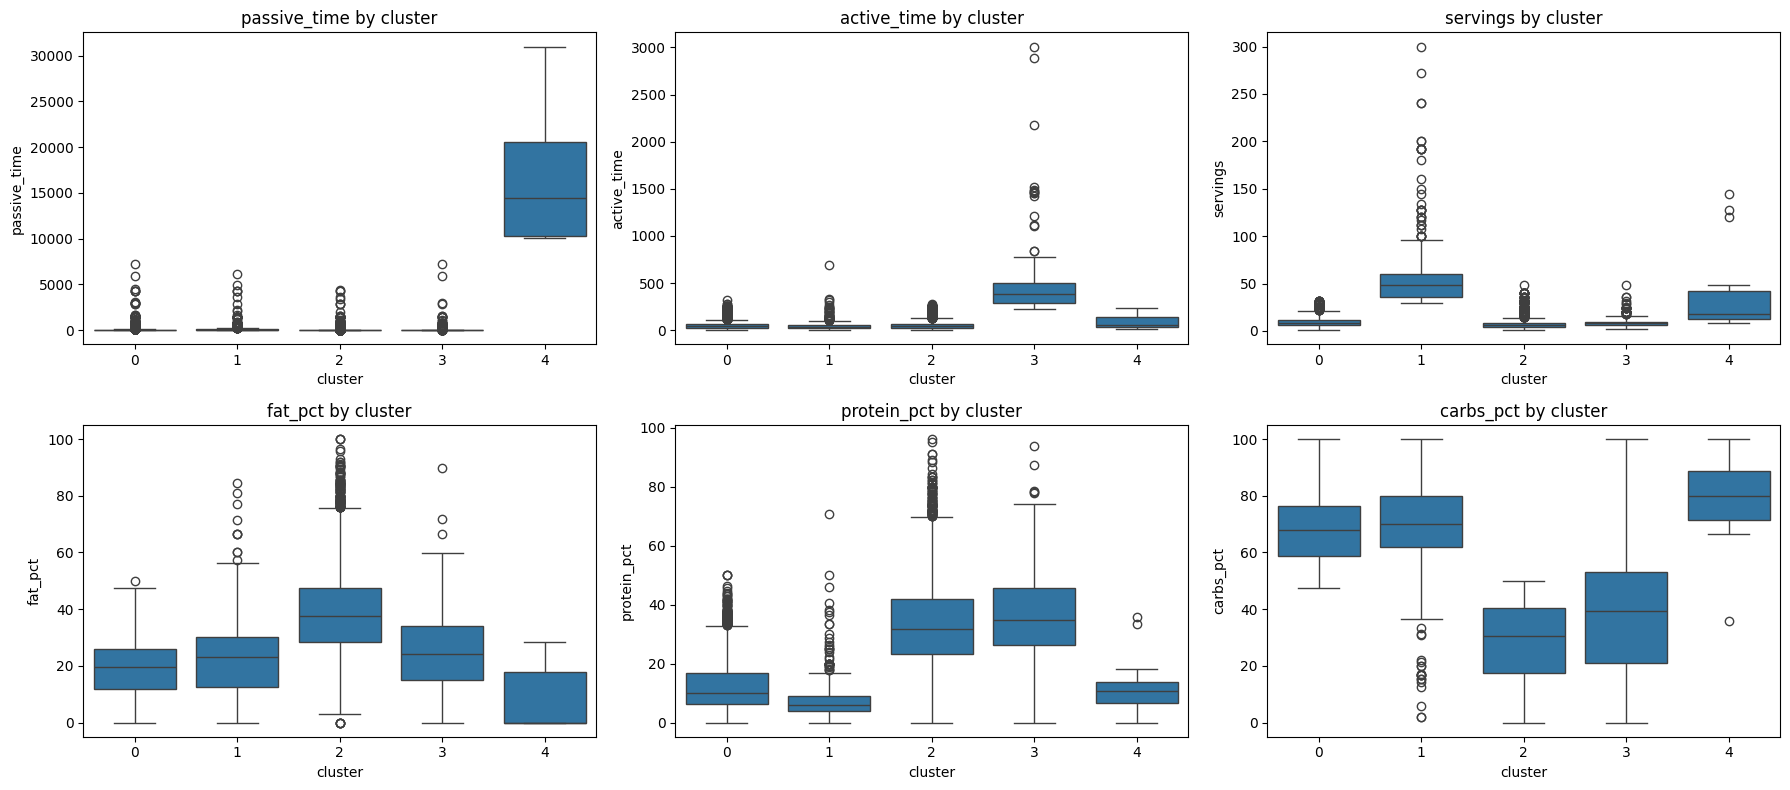

In [77]:
# List of all columns to use in the boxplots.
df_plot = df[["cluster"] + feature_cols]

# Use the helper function 'plot_cluster_boxpots()' from visualisation.py to plot the collection of boxplots for the Kmeans columns grouped on cluster.
plot_cluster_boxplots(df, feature_cols, cluster_col="cluster", rows=2)

#### Boxplot and Cluster Profile Interpretation:

It must be noted that there are differing scales for each boxplot visual with passive time ranging from zero to **30,000 minutes** (**~21days**), active time ranging from zero to **3,000 minutes** (**~2days**), servings ranging from zero to **300 servings**, which is a substantially smaller scale than the timings variables. The macronutrient values range from zero to **100** given that they are percentages. Therefore the timinig and servings boxplots cannot be directly compared to one another. However, the macronutrients boxplots can be directly compared because they share the same scale **0-100%** (e.g. comparing the fat-percentage distribution for cluster **1** its protein-percentage distribution).
<br><br>
| Cluster | Time | Serving Size | Macronutrients | Overall |
|---------|------|--------------|----------------|---------|
| 0 | Cluster **0** shows compact, low‑range distributions for both passive and active time. The boxes are small and the whiskers are short, with a few far off outliers in passive time. This indicates predictable, low‑effort recipes with minimal variation. | The servings distribution is tight and moderate, suggesting most recipes could be a typical family style recipe. | With carbs visibly higher than fat and protein this indicates a carb-leaning recipes cluster. | This cluster fits well with the identity of an everyday, widely‑used carb-heavy family recipe profile. |
| 1 | Passive time shows slightly wider spread than cluster **0**, active time remains compact, suggesting that recipes require longer waiting or resting phases. | The servings boxplot is high up the scale and widely spread, indicating large‑batch recipes with substantial variation. | Carbs are the highest macronutrient with some long-tail outliers towards the lower end. Protein is visibly low and fat is moderate. | The boxplots highlight a large‑serving, long‑wait, high‑carb cluster, distinct from everyday recipes due to serving sizes and passive‑time requirement. |
| 2 | Both passive and active time show compact, low‑range low-lying distributions, similar to Cluster **0** suggesting quick recipes. | The servings boxplot is the lowest and tightest of all clusters, indicating small‑portion recipes with very little variation. | Fat and protein boxplots are visibly higher than carbs. Carbs are clearly the lowest of all clusters. This creates a distinctive high‑protein/high‑fat, low‑carb style. | Cluster **2** stands out visually as a protein‑dense, low‑carb cluster, with small servings and short times. |
| 3 | Active time has the highest and widest boxplot of all clusters, with a very large spread and many high outliers and passive time is moderate, this indicates labour‑intensive, multi‑stage recipes. | Serving sizes are moderate and similar to clusters **0** and **2**. | Protein is high, with carbs and fat in the middle of the range among the clusters. The three macronutrients appear more balanced than in other clusters. | This cluster shows extreme active‑time variation and balanced macronutrients, suggesting complex, hearty dishes. |
| 4 | Passive time is extremely high compared to other clusters with wide variation. Active time is also high compared to **3** of the other clusters with a wide spread. This is the clearest visual display of multi‑day processes such as fermentation, curing, or pickling. | The servings boxplot is wide and high, similar to cluster **1**, indicating large‑batches. | Carbs are visibly the highest macronutrient of all clusters, with fat extremely low and protein modest. This aligns with fruit preserves, sweet pickles, syrups, wines, beers, and other sugar‑based ferments. | This cluster is visually distinct due to its extreme passive times and high‑carb profile, strongly supporting the interpretation of a preservation/fermentation cluster. |


#### <center> Summary of the **5** clusters. <center/>

| Cluster | Key Features |
|---------|--------------|
| 0 | Everyday, quick, moderate-servings, high-carb, moderate-fat, moderate-protein |
| 1 | Long‑passive time, large‑batches, low-protein, moderate-fat, high‑carb |
| 2 | Everyday, quick, low-servings, low-carb, high‑fat, high‑protein |
| 3 | Labour‑intensive, moderate-passive time, moderate-servings, moderate-fat, high-protein, moderate‑carb |
| 4 | Extreme-passive time, high-active time, large-batches, low-fat, low-protein, high‑carb |

***
<br>

## 8. Cluster Interpretation Using Ingredients

Next I will conduct some text analysis of the ingredients lists to help with the interpretation of the clusters, this will involve generating a list of popular key identifying words for each cluster. To do that I will:
1. Define a cluster dictionary of the ingredients per recipe.
2. Text cleanse the ingredients list by tokenising the words, lemmatising the words, remove words that appear in every cluster as they don't distinguish between the clusters and remove stopwords.
3. Plot word frequency bar plots.
4. Interpret the ingredients lists to develop a theme for the recipe clusters.
***
<br>

#### 8.1 Define Cluster Ingredients Data Dictionary.
Here I take a copy of the columns needed in the text analysis of the clustered ingredients, placing this in a separate dataframe rather than using a slice of the Allrecipes dataframe. This helps to avoid some warnings through the next processes, and keeps the data separate from the K-Means variables which are not needed here.

In [78]:
# Take a copy of the recipe_id, ingredients and cluster columns.
df_cluster_dictionary = df[["recipe_id", "ingredients", "cluster"]].copy()
df_cluster_dictionary.head(5)

,recipe_id,ingredients,cluster
0,0,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",0
1,1,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",0
2,2,"2 tablespoons olive oil, or to taste, ½ onion...",2
3,3,4 cups dried mafalda pasta (mini lasagna noodl...,0
4,4,"4 green bell peppers, halved lengthwise and se...",2


***
<br>

#### 8.2 Text Cleansing The Ingredients
Cleanse the ingredients column using the *clean_column_contents()* helper function that uses regular expressions to keep only letters and compressed whitespaces.

In [79]:
# Create 'ingredients_clean' column by using 'clean_column_contents()' heplper function from utils.py
df_cluster_dictionary['ingredients_clean'] = df_cluster_dictionary['ingredients'].apply(clean_column_contents)
df_cluster_dictionary.head(5)

,recipe_id,ingredients,cluster,ingredients_clean
0,0,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",0,cup margarine softened cup white sugar cup pac...
1,1,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",0,egg yolks cups heavy whipping cream teaspoon v...
2,2,"2 tablespoons olive oil, or to taste, ½ onion...",2,tablespoons olive oil or to taste onion finely...
3,3,4 cups dried mafalda pasta (mini lasagna noodl...,0,cups dried mafalda pasta mini lasagna noodles ...
4,4,"4 green bell peppers, halved lengthwise and se...",2,green bell peppers halved lengthwise and seede...


After turning the ingredients into lists of word tokens I will use *[Natural Language Toolkit (NLTK)](https://www.nltk.org/)* to lemmatize the words using *WordNetLemmatizer()*. For example, bricks will convert to brick, mice will convert mouse, cups will convert to cup.

*"Lemmatization is the process of reducing a word to its base form, or lemma. This is done by considering the word’s context and morphological analysis. Essentially, lemmatization looks at a word and determines its dictionary form, accounting for its part of speech and tense."* *[(PythonProg, 2026)](https://www.pythonprog.com/lemmatization/)*

In [80]:
lemmatizer = WordNetLemmatizer()        # Identify the lemmatizer to use for this proecess

# Tokenise and lemmatise in one go
df_cluster_dictionary["tokens_lemma"] = (
    df_cluster_dictionary["ingredients_clean"]  # Use the clean words column from our dictionary
    .str.split()                                # Tokenise the words
    .apply(lambda words: [lemmatizer.lemmatize(w, pos="n") for w in words])    # Lemmatize the words using the lemmatizer identified above
)

df_cluster_dictionary.head(5)   # Display the top 5 rows

,recipe_id,ingredients,cluster,ingredients_clean,tokens_lemma
0,0,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",0,cup margarine softened cup white sugar cup pac...,"[cup, margarine, softened, cup, white, sugar, ..."
1,1,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",0,egg yolks cups heavy whipping cream teaspoon v...,"[egg, yolk, cup, heavy, whipping, cream, teasp..."
2,2,"2 tablespoons olive oil, or to taste, ½ onion...",2,tablespoons olive oil or to taste onion finely...,"[tablespoon, olive, oil, or, to, taste, onion,..."
3,3,4 cups dried mafalda pasta (mini lasagna noodl...,0,cups dried mafalda pasta mini lasagna noodles ...,"[cup, dried, mafalda, pasta, mini, lasagna, no..."
4,4,"4 green bell peppers, halved lengthwise and se...",2,green bell peppers halved lengthwise and seede...,"[green, bell, pepper, halved, lengthwise, and,..."


Now I will find the common words that appear in all **5** clusters, if they appear in all clusters then I believe they won't define differences between the clusters, so will remove them at this point.

In [81]:
# Create an empty dictionary to store the vocabulary for each cluster
cluster_word_sets = {}

# Loop over each cluster using groupby
for cluster, group in df_cluster_dictionary.groupby("cluster"):
    # Flatten all lemma tokens for this cluster into a single list of words
    words = [word for tokens in group["tokens_lemma"] for word in tokens]
    # Convert the list of words into a set, as this removes duplicates automatically,
    # which helps speed and frequencies aren't needed here
    cluster_word_sets[cluster] = set(words)

# Find words that appear in all clusters
common_words = set.intersection(*cluster_word_sets.values())
# Show the 10 of the common words
list(common_words)[:10]

['package',
 'salt',
 'beet',
 'bean',
 'divided',
 'cover',
 'cherry',
 'fresh',
 'white',
 'stick']

In [82]:
# Remove these words from my tokens
df_cluster_dictionary['tokens_filtered'] = df_cluster_dictionary['tokens_lemma'].apply(
    lambda words: [w for w in words if w not in common_words]
)
df_cluster_dictionary.head(5)

,recipe_id,ingredients,cluster,ingredients_clean,tokens_lemma,tokens_filtered
0,0,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",0,cup margarine softened cup white sugar cup pac...,"[cup, margarine, softened, cup, white, sugar, ...","[margarine, packed, peanut, whole, wheat]"
1,1,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",0,egg yolks cups heavy whipping cream teaspoon v...,"[egg, yolk, cup, heavy, whipping, cream, teasp...","[yolk, heavy, whipping, cream, can, pumpkin, p..."
2,2,"2 tablespoons olive oil, or to taste, ½ onion...",2,tablespoons olive oil or to taste onion finely...,"[tablespoon, olive, oil, or, to, taste, onion,...","[olive, oil, finely, finely, tomato, sauce, wi..."
3,3,4 cups dried mafalda pasta (mini lasagna noodl...,0,cups dried mafalda pasta mini lasagna noodles ...,"[cup, dried, mafalda, pasta, mini, lasagna, no...","[mafalda, pasta, mini, lasagna, noodle, olive,..."
4,4,"4 green bell peppers, halved lengthwise and se...",2,green bell peppers halved lengthwise and seede...,"[green, bell, pepper, halved, lengthwise, and,...","[lengthwise, olive, oil, rice, cube, beef, bou..."


Here its visible that some words have been removed such as cup, softened, white, sugar, etc. 
Next I will remove stopwords. Stopwords are *"Stopwords are commonly used words (for example, the, is, and, in) that do not contribute much meaning to a sentence and can be eliminated to improve efficiency in text analysis"* 

I have chosen to use the *scikit-learn* stopwords list rather than *NLTK* because the list is leaner and easier to add a personalised list of extra words to.

In [83]:
# Remove stopwords including extra words
# WARNING: This list has been compiled by running the rest of the model, observing the frequency charts below and fine tuning the list.
# This list could be stored elsewhere in a .py file however it is unlikely to be used again, therefore it is fine to retain the list here.

stopwords = set({ENGLISH_STOP_WORDS, "teaspoon", "teaspoons", "oil", "tablespoon", "tablespoons", "finely", "chopped", "inch", "mini",
                 "ounce", "purpose", "flour", "butter", "to", "and", "or", "as", "into", "all", "large", "fresh", "white", "black", "ground", "taste",
                 "package", "can", "pound", "pounds", "ounce", "ounces", "dried", "softened", "sliced", "minced", "diced", "shredded", "cup", "cups",
                 "teaspoon", "teaspoons", "tablespoon", "tablespoons", "tbsp", "tsp", "gram", "grams", "ml", "liter", "litre", "pint", "purpose",
                 "baking", "salt", "water", "sugar", "pepper", "power", "sauce", "cut", "thicken", "grated", "freshly", "more", "powder", "drained",
                 "flakes", "oil", "a", "half", "pinch", "such", "frozen", "cooked", "medium", "seasoning", "needed", "slice", "weed", "food", "degree",
                 "colouring", "self", "strongly", "mix", "cooking", "light", "of", "for"
                })

# Apply a filter to each recipe's token list
df_cluster_dictionary['tokens_filtered'] = df_cluster_dictionary['tokens_filtered'].apply(lambda words: [w for w in words if w not in stopwords])
df_cluster_dictionary.head(5)

,recipe_id,ingredients,cluster,ingredients_clean,tokens_lemma,tokens_filtered
0,0,"⅓ cup margarine, softened, ⅔ cup white sugar, ...",0,cup margarine softened cup white sugar cup pac...,"[cup, margarine, softened, cup, white, sugar, ...","[margarine, packed, peanut, whole, wheat]"
1,1,"12 egg yolks, 2 cups heavy whipping cream, ½ ...",0,egg yolks cups heavy whipping cream teaspoon v...,"[egg, yolk, cup, heavy, whipping, cream, teasp...","[yolk, heavy, whipping, cream, pumpkin, puree,..."
2,2,"2 tablespoons olive oil, or to taste, ½ onion...",2,tablespoons olive oil or to taste onion finely...,"[tablespoon, olive, oil, or, to, taste, onion,...","[olive, tomato, wine, parsley, basil, oregano]"
3,3,4 cups dried mafalda pasta (mini lasagna noodl...,0,cups dried mafalda pasta mini lasagna noodles ...,"[cup, dried, mafalda, pasta, mini, lasagna, no...","[mafalda, pasta, lasagna, noodle, olive, carro..."
4,4,"4 green bell peppers, halved lengthwise and se...",2,green bell peppers halved lengthwise and seede...,"[green, bell, pepper, halved, lengthwise, and,...","[lengthwise, olive, rice, cube, beef, bouillon..."


***
<br>

#### 8.3 Word Frequencies

In [84]:
# Build a dataframe of top 30 words per cluster directly (no intermediate dict)
df_ingredients = pd.DataFrame(
    {
        'cluster': cluster,   # Define the column names for the dataframe and the source column used to create them.
        'ingredient': word,   # Use the word column to find the ingredients
        'frequency': count    # Use the count column that's created below to find the frequency of the ingredient appearance
    }
    for cluster, group in df_cluster_dictionary.groupby("cluster")   # loop through clusters
    for word, count in Counter(                                      # count words in this cluster
        w for tokens in group["tokens_filtered"] for w in tokens     # flatten tokens
    ).most_common(30)                                                # keep top 30
)

df_ingredients.head(5)   # show first 5 rows only

,cluster,ingredient,frequency
0,0,cheese,1687
1,0,cream,1471
2,0,olive,1297
3,0,vegetable,1164
4,0,tomato,893


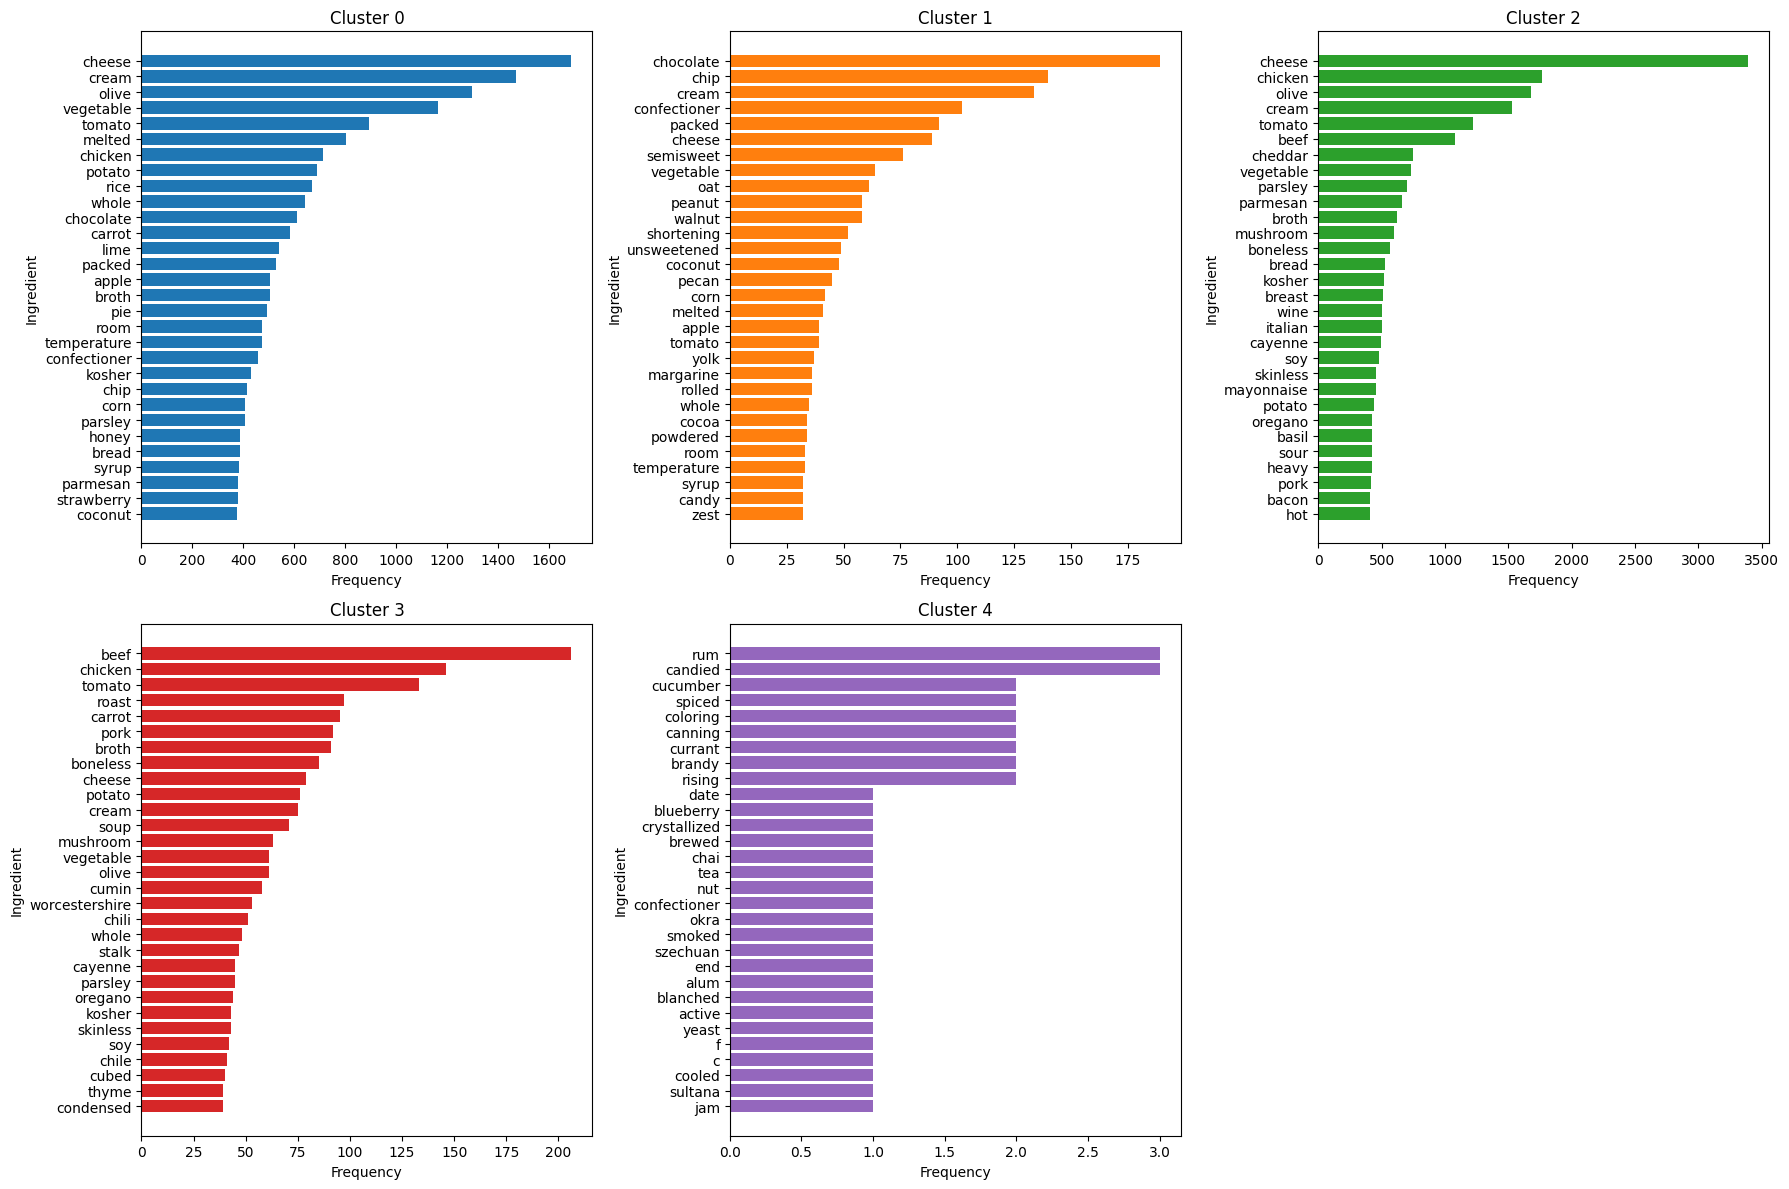

In [85]:
# plot the bar charts per cluster
clusters = sorted(df_ingredients['cluster'].unique())
num_clusters = len(clusters)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colours = plt.cm.tab10.colors

for i, cluster in enumerate(clusters):
    ax = axes[i]
    
    subset = df_ingredients[df_ingredients['cluster'] == cluster].sort_values(by='frequency', ascending=False)

    # numeric positions for y
    y_pos = np.arange(len(subset))

    # horizontal bars: y = positions, width = counts
    ax.barh(y_pos, subset['frequency'], color=colours[i])

    # set y tick positions and labels to the words
    ax.set_yticks(y_pos)
    ax.set_yticklabels(subset['ingredient'])

    # Titles and axis labels
    ax.set_title(f"Cluster {cluster}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Ingredient")

    # most frequent at top
    ax.invert_yaxis()

# Hide unused axes (e.g., the 6th one)
for j in range(num_clusters, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

***
<br>

#### 8.4 Ingredients Interpretation and Theme Development.

**Frequency Scales:** Cluster **4** frequency maxes out at **3**. This cluster is very small in comparison to the others, with **0.1%** of the recipes (only **14** recipes) therefore it is logical that ingredients will appear fewer times and the list will be smaller. Clusters **0** and **2** have much larger freqnuency scales than the others which is to be expected since they contain **53.3%** and **38.7%** respectively. Clusters **1** and **3** have similar sized scales and contain **4.8%** and **3.2%** of the total recipes.


| Cluster | Top Ingredients | Interpretation |
|---------|-----------------|----------------|
| 0 | cheese, cream, olive, vegetable, tomato, chicken, potato, rice, chocolate, carrot, apple, broth, honey | Comfort foods, casseroles, creamy pastas, general simple baking, soups and stews. <br><br> This cluster looks like general, everyday home‑cooking, home baking, family‑friendly mains. <br><br> The presence of chocolate, apple, and syrup hints at dessert overlap with weekday comfort meals. |
| 1 | chocolate, chip, cream, confectioner, packed, semisweet, oat, peanut, walnut, coconut, pecan, cocoa, powdered, syrup, zest | Baking and desserts, cookies, brownies, cakes, sweet breads, dessert bars. <br><br> The dominance of chocolate, nuts, confectioner’s sugar, cocoa, and syrups makes this cluster the sweet‑baking hub. |
| 2 | cheese, chicken, olive, cream, tomato, beef, vegetable, parsley, broth, mushroom, bread, kosher, wine, cayenne, soy, oregano, basil |  Italian‑style or Mediterranean‑style savoury dishes, creamy chicken pastas, tomato‑based chicken or beef dishes, mushroom sauces, herb‑heavy meals (oregano, basil, parsley), dishes using wine, broth, olive oil. <br><br> It’s a protein‑rich, herb‑forward, savoury main‑meal cluster. |
| 3 | beef, chicken, tomato, roast, carrot, pork, broth, boneless, potato, mushroom, olive, cumin, chili, thyme, oregano, soy, wine | Slow‑cooked hearty stew‑style dishes, beef stews, pot roasts, chili, braised meats, hearty soups. <br><br> The combination of beef, pork, broth, carrots, potatoes, cumin, chili, thyme, and wine is classic comfort‑food stew territory. |
| 4 | rum, candied, cucumber, spiced, coloring, canning, currant, brandy, rising, date, blueberry, crystallized, brewed, chai, tea, nut, okra, smoked, alum, blanched, yeast, cooled, sultana, jam, marzipan, fondant | Preserving/canning recipes: classic for pickles, chutneys, relishes, fermented items (cucumber, canning, alum, okra, spiced, smoked). <br><br> Festive or speciality baking: Holiday breads, fruit cakes, enriched doughs, decorative baking (candied, currant, crystallized, sultana, marzipan, fondant, rising, yeast) <br><br> Alcohol‑infused or brewed items: Liqueur‑based desserts, fruitcakes, spiced drinks, home brewing, or infused syrups (rum, brandy, brewed, chai, tea. <br><br> These suggest a special‑occasion / preserving / brewing cluster. |

***
<br>

#### <center> Summary of the **5** clusters. <center/>

| Cluster | Key Words on Theme | Size |
|---------|--------------------|------|
| 0 | Everyday, quick, moderate-servings, high-carb, moderate-fat, moderate-protein, comfort foods, simple baking | Very Large Cluster |
| 1 | Long‑passive time, large‑batches, low-protein, moderate-fat, high‑carb, baking and desserts | Small Cluster |
| 2 | Everyday, quick, low-servings, low-carb, high‑fat, high‑protein, Italian/Mediterranean‑style, savoury | Very Large Cluster |
| 3 | Labour‑intensive, moderate-passive time, moderate-servings, moderate-fat, high-protein, moderate‑carb, slow‑cooked, hearty, stews | Small Cluster |
| 4 | Extreme-passive time, high-active time, large-batches, low-fat, low-protein, high‑carb, preserves, alcohol, holiday baking, speciality items | Extremely Small Cluster |

These cluster theme key words can then be attached to the dataframe, see below, and used for filtering by users of the website if a search tool was created.

In [86]:

# Use the map function to map cluster theme keywords to the dataframe.
cluster_keywords = {
    0: ["everyday", "quick", "moderate-servings", "high-carb", "moderate-fat", "moderate-protein", "comfort foods", "simple-baking"],
    1: ["long‑passive-time", "large‑batches", "low-protein", "moderate-fat", "high‑carb", "baking-and-desserts"],
    2: ["everyday", "quick", "low-servings", "low-carb", "high‑fat", "high‑protein", "italian-mediterranean", "savoury"],
    3: ["labour‑intensive", "moderate-passive-time", "moderate-servings", "moderate-fat", "high-protein", "moderate‑carb", "slow‑cooked", "hearty", "stews"],
    4: ["extreme-passive-time", "high-active-time", "large-batches", "low-fat", "low-protein", "high‑carb", "preserves", "alcohol", "holiday-baking", "speciality-items"]
}

df["cluster_theme_keywords"] = df["cluster"].map(cluster_keywords)

# Display the data with clickable links using the helper function 'display_html()' from utils.py, round numbers to 2.dp.
display_html(df.sort_values(["recipe_id"]).round(2), n=5, random=True, seed=42)

,recipe_id,name,url,ingredients,fat,carbs,protein,servings,active_time,passive_time,fat_pct,carbs_pct,protein_pct,cluster,cluster_theme_keywords
7275,7275,Peanut Butter Kiss Cookies,Peanut Butter Kiss Cookies,"1 cup white sugar, 1 cup creamy peanut butter, 1 large egg, 18 milk chocolate candy kisses, unwrapped",7.0,14.0,4.0,18.0,20,0,28.00,56.00,16.00,0,"[everyday, quick, moderate-servings, high-carb, moderate-fat, moderate-protein, comfort foods, simple-baking]"
12516,12516,Microwave Quesadilla,Microwave Quesadilla,"2 flour tortillas, ½ cup shredded sharp Cheddar cheese",15.0,37.0,13.0,2.0,3,0,23.08,56.92,20.00,0,"[everyday, quick, moderate-servings, high-carb, moderate-fat, moderate-protein, comfort foods, simple-baking]"
7607,7607,Baked Stuffed Brie with Cranberries & Walnuts,Baked Stuffed Brie with Cranberries & Walnuts,"1 small wheel of Brie (about 6 to 8 inches), chilled, ¼ cup dried cranberries, ¼ cup chopped walnuts, 1 sheet frozen puff pastry, thawed, plus extra for design, 1 large egg, 1 teaspoon water",22.0,17.0,9.0,8.0,40,60,45.83,35.42,18.75,2,"[everyday, quick, low-servings, low-carb, high‑fat, high‑protein, italian-mediterranean, savoury]"
12234,12234,Simple Beef-Flavored Gravy,Simple Beef-Flavored Gravy,"¼ cup butter, ¼ cup all-purpose flour, 1 onion, chopped, 1 ½ cups water, 3 teaspoons beef bouillon",8.0,6.0,1.0,6.0,15,0,53.33,40.00,6.67,2,"[everyday, quick, low-servings, low-carb, high‑fat, high‑protein, italian-mediterranean, savoury]"
7425,7425,One Pot Turmeric Chicken and Rice,One Pot Turmeric Chicken and Rice,"1 1/2 pounds skinless, boneless chicken breast, cut into 1 1/2-inch pieces, salt and freshly ground black pepper to taste, 1 tablespoon unsalted butter, 1 teaspoon ground turmeric, 1 cup chopped onion, 2 teaspoons peeled and minced fresh ginger, 2 cloves garlic, peeled and minced, 1 cup chopped tomato, 2 cups green beans, cut into 2-inch pieces, 1 teaspoon curry powder, 1 pinch ground cinnamon, 1/4 teaspoon ground cumin, 1 cup jasmine rice, 2 bay leaves, 2 teaspoons fish sauce, 1 1/2 cups chicken stock",11.0,28.0,59.0,4.0,60,0,11.22,28.57,60.20,2,"[everyday, quick, low-servings, low-carb, high‑fat, high‑protein, italian-mediterranean, savoury]"


***
<br>

## 9. External Validation of Cluster Themes.

I will choose a random sample of 5 recipes from each cluster and test whether they match the theme of the cluster.

In [87]:
# Random sample of 5 recipes per cluster (25 in total), using a random_state of 42 to ensure reproducibility
sampled_recipes = (
    df.sort_values(["cluster", "servings"])    # Sort the dataframe by the "cluster" and the "servings" to create an order for sampling.
      .groupby("cluster")                      # Group the data by cluster
      .sample(n=5, random_state=42)            # Sample 5 recipes per cluster, using a random_state of 42 for reproducibility
      .reset_index(drop=True)                  # Reset the index from 0 so the sampled rows form a clean dataframe
)[["url", "cluster"]]                          # Retain only the "url" and "cluster" column

# Take the sampled recipes, group by cluster, and place all the urls in one field separated by the " || " double pipe.
combined = (
    sampled_recipes                     # Take the sampled recipe dataset
    .groupby("cluster")["url"]          # Group the sampled recipe data by "cluster" and extract the "url" column for each cluster 
    .apply(lambda s: " || ".join(s))    # Join the 5 "url"s into a single string using the double pipe separator
    .reset_index(name="Sample")         # Name the column "Sample" and reset the index so it runs from 0 to match the cluster column
)

# Display the 5 sample recipe cluster groups for validation purposes
display_html(combined, n=5, random=False)

,cluster,Sample
0,0,Maple Walnut Scones || OREO Mini PHILLY Cheesecakes || Pear Upside-Down Graham Cake || Cracklin' Bread II || The Captain's Famous Jambalaya
1,1,Sweet and Mild Cooked Tomato Salsa || World's Best Peanut Butter Fudge || Chinese Cocktail Buns || Chocolate-Dipped Orange Shortbread Cookies || No-Bake Peanut Butter Cookies
2,2,Chicken and Mushroom Tetrazzini || Brad's Slow Cooker Chicken Parmesan || My Favorite Stuffed Green Peppers || Make Ahead Breakfast Casserole || Argentinean Potato Salad
3,3,Texas Pork Ribs || Slow Cooker Tacos al Pastor || Frijoles Refritos (Refried Beans) || Spicy Slow-Cooked Beanless Chili || Seafood Gumbo Stock
4,4,Sauerkraut for Canning || Pickled Garlic || Crisp Pickled Green Beans || Spicy Pickled Okra || Raw Fermented Beets


<br>

#### <center> Summary of the **5** clusters. <center/>
| Cluster | Key Words on Theme | Size | Reflective of Theme | External Validation |
|---------|--------------------|------|---------------------|---------------------|
| 0 | Everyday, quick, moderate-servings, high-carb, moderate-fat and moderate-protein, comfort foods, simple baking | Very Large Cluster | Yes | These five dishes mostly fit the “everyday, quick, moderate‑servings, high‑carb, moderate‑fat, moderate‑protein, comfort‑food, simple‑baking” profile, with cracklin’ bread, pear upside‑down cake, mini cheesecakes, and maple‑walnut scones all delivering straightforward, home‑style bakes with balanced macros and familiar flavours. The only negative is the jambalaya, which is savoury and hearty but not a simple bake, and its higher protein and lower fat profile make it less aligned with the cluster than the others. |
| 1 | Long‑passive time, large‑batches, low-protein, moderate-fat, high‑carb, baking and desserts | Small Cluster | Yes | These five recipes largely fit the “long‑passive time, large‑batch, low‑protein, moderate‑fat, high‑carb, baking and desserts” profile, with the fudge, no‑bake cookies, and shortbread cookies all producing high‑carb, moderate‑fat, low‑protein sweet bakes in big yields, and the Chinese cocktail buns adding a yeast‑raised, bakery‑style carbohydrate‑rich item. The only negative is the tomato salsa, which is savoury, low‑fat, and not a dessert, so it does not match the cluster, however earlier I noted there would be some overlapping recipes, |
| 2 | Everyday, quick, low-servings, low-carb, high‑fat, high‑protein, Italian/Mediterranean‑style, savoury | Very Large Cluster | Yes | These five dishes broadly match the “everyday, quick, low‑serving, low‑carb, high‑fat, high‑protein, Italian/Mediterranean‑style, savoury” profile, with chicken tetrazzini, slow‑cooker chicken Parmesan, stuffed peppers, and the breakfast casserole all delivering rich, protein‑heavy, creamy or tomato‑based Mediterranean‑leaning flavours in relatively small household portions. The only clear negative is the Argentinean potato salad, which is high‑carb, low‑protein, and not Mediterranean, so it does not fit the cluster, however earlier I stated that there would be some overlapping recipes. |
| 3 | Labour‑intensive, moderate-passive time, moderate-servings, moderate-fat, high-protein, moderate‑carb, slow‑cooked, hearty, stews | Small Cluster | Yes | These five dishes all share long, slow‑cooked, labour‑intensive preparation with moderate passive time and hearty, protein‑rich profiles, aligning well with a “slow‑cooked, stew‑like, moderate‑serving, moderate‑fat, moderate‑carb” cluster. The only mismatches are that the seafood gumbo stock is low‑protein and more of a base than a stew, and the Texas pork ribs skew higher‑fat and higher‑carb than the cluster’s typical nutritional balance. |
| 4 | Extreme-passive time, high-active time, large-batches, low-fat, low-protein, high‑carb, preserves, alcohol, holiday baking, speciality items | Extremely Small Cluster | Yes | These five recipes all fit the same pattern: long‑fermentation or multi‑week pickling processes that produce large‑batch, low‑fat, low‑protein, high‑carb preserved vegetables. Together they represent classic speciality preservation items with extreme passive time and modest active preparation. None of the sample involve alcohol or holiday baking, which was a sub‑theme to the broader cluster. |

<br>
<br>
The evidence above leads me to believe that the cluster descriptions adequately represent the population.

***
<br>

## 10. Summary of Findings and Potential Future Improvements

The aim of this project was to evaluate ***how effectively K‑Means clustering can be used to segment recipes based on macronutrient composition and total recreation time, with the goal of supporting time‑constrained individuals in making nutritionally informed choices***. Using a dataset of recipes scraped from Allrecipes.com by *[owlzeyes - Brian Mubia](https://github.com/owlzyseyes)*, I applied K‑Means to identify meaningful groupings that reflect both the nutritional structure and the behavioural demands of preparing each recipe. Clustering was an appropriate method for this task, as it groups items based on shared features within the dataset and therefore aligns naturally with the objective of categorising recipes into interpretable segments relevant to users of an online recipe platform like Allrecipes.com. The goal for this analysis was to uncover groupings that could be used for categorising recipes and labelling/tagging them based on the time it takes to recreate them, and the macronutrient content of the recipes.

I began the analysis by loading the data, loading the python libraries required for running the code and setting up some helper functions (**see *1. Libraries, Data Loading and Helper Functions***). I then conducted some exploratory data analysis (EDA), and data cleansing (**see *2. EDA - Basic***). I removed columns that were redundant to the analysis (*author, date_published, avg_rating, total_ratings and reviews*), and checked for any duplication that needed dealing with, finding no complete duplicates and justifying any duplication within the variables as acceptable to retain (*recipes sharing the same name were confirmed to represent distinct recipe entries*). I explored the distribution of the time based columns  (**see *3. Numeric Column EDA (Defining K-Means Variables)***), tested to ensure none of the time column pairings were highly correlated, which they weren't and I removed recipes where all time fields were **0**. When investigating time I discovered that not all time fields available on the website were contained within the dataset, therefore I conducted some feature engineering to create time columns that described energy-based behaviours (*passive_time and active_time*) as the amount of effort and non-effort based time may be a determining factor in whether or not a user chooses a recipe from the website. Implausible entries, such as negative passive time or zero active time were removed.

I explored the size based column (*servings*) and removed recipes with missing serving sizes as K-Means clustering cannot handle *NaN* values, and the serving size could not be determined from the other data within the dataset. I replaced all missing values within the nutritional variables with **0** and then removed recipes where all nutritional values were **0** as I reasoned that all recipes must have some form of nutritional value and if they remained then they would leave too much missing data to be useful, also the recipes would sit at the origin in the nutritional directional space skewing the results.

I conducted correlation analysis which showed that *calories* were almost entirely explained by *fat*, *protein*, and *carbohydrate* content via the **General Atwater Factors**, so I removed the *calories* column to avoid multicollinearity. Extreme macronutrient outliers above the **99.5th** percentile were also excluded and text fields (*name* and *ingredients*) were checked to ensure they contained sufficient information for later interpretation. I deduced that all recipes with a low number of characters in either the *name* or *ingredients* columns were acceptable (*see **4. Non-Numeric Column EDA (Exploring the Ingredients)***).

The numeric variables required scaling (**see *5. Defining The Number of Clusters***) to ensure that each feature variable had a mean of **0** and standard deviation of **1** to standardise their influence and restrict variables with large numeric ranges from dominating the clustering. I tested a variety of column combinations resulting in the feature engineering of the macronutrient columns into proportional nutritional percentage columns. I used the elbow method (Inertia), silhouette plots, and the silhouette scores to determine the optimum number for ***k*** and the best variables to use for the K-Means clustering. I concluded that, even though there were some options with better silhouette scores (***~-0.9***) they were unusable as they provided too few clusters (**2**) which would have been meaningless to the model, proven when viewing the PCA plots and observing that almost all recipes were in only one of the clusters. Therefore the optimal combination was ***k=5*** with **6** variables: **2** time-based (*passive time and active time*), **1** size based (*servings*) a **3** nutritional based (*fat percentage, carbs percentage and protein percentage*) as that gave enough clusters to answer the original question, with a silhouette score (**0.3679**) which was was the largest score from all the remaining tests.
- The time based columns described behaviours the recipe recreater would undergo when following the recipe, *active* and *passive*, reflecting the part of the original question surrounding time constrained individuals.
- The size based column reflected the number of servings that the recipe describes, which is an additional behavioural pattern beyond the original scope of the analysis.
- The macronutrient based columns were proportional distrubutions that reflect the part of the original question surrounding users making nutritionally informed choices.

After fitting the model to the Allrecipes.com scraped dataset using the chosen features and parameters (**see *6. Fit the Model***), I investigated the cluster profile using the feature means for each cluster and the distribution of each feature grouped by cluster (**see *7. Investigate the Cluster Profile and Distribution***). This enabled me to develop a clear characterisation of each cluster, composing a written breakdown of each variable within the clusters and developing a summary of key features for the **5** clusters based on the time, size and macronutrient composition of the recipes.

To enhance the cluster theme descriptions, I conducted text analysis for the recipe ingredients (**see *8. Cluster Interpretation Using Ingredients***). This involved cleansing the ingredients column by removing numbers and punctuation, tokenising and lemmatising the words within each recipe. Then removing words that appeared across every cluster as I decided that they wouldn't be a distinguishing factor and could cloud the interpretation of the clusters if the words featured heavily within the most frequent words for each cluster. Finally I removed stopwords, calculated the frequencies of the remaining words and plotted word frequency bar plots, these plots allowed me to further interpret the clusters and attach a cooking style/theme to each cluster, this theme was then attached to the dataset. The theme column could be used in many ways by Allrecipes.com to develop tools for users and by the marketing department as discussed below in **Practical Applications**.

To validate the thematic keywords derived for each cluster (**see *9. External Validation of Cluster Themes***), I randomly sampled **5** recipes per cluster and compared the cluster descriptions to the corresponding recipe pages on the Allrecipes.com website. This external validation confirmed that the clusters were coherrent and interpretable, with strong alignment between quantitive cluster profiles and qualitative characteristics of the sampled dishes. Some overlap between the clusters was expected given the silhouette score of **0.3679**, but overall the clusters were well-defined. Four clusters showed very strong agreement with their assigned theme, and even the smallest cluster demonstrated clear, distinctive patterns that were consistent with the underlying distributions of the feature variables within the cluster. This provided confidence that the cluster descriptions accurately represented the population and that the groupings produced by the model were not random.
<br><br>

**Cluster 0 - Everyday, quick, moderate-serving comfort foods:** A large cluster of simple, familiar, high-carbohydrate recipes with moderate fat and protein matching the "everyday baking and comfort foods" theme. Most sampled recipes aligned well, with Jambalaya diverging slightly due to its higher-protein profile.

**Cluster 1 - Long-passive, large-batch baking and desserts:** A small cluster of high-carb, moderate-fat, low-protein sweet bakes with long resting or cooling times and large yields. The only mismatch was the Tomato Salsa, which is savoury and low-fat but was expected given earlier observations regarding occasional cross-cluster overlap.

**Cluster 2 - Quick, low-carb, high-protein Mediterranean-style dishes.** A very large cluster of protein-heavy, low-carb, high-fat savoury meals with Mediterranean characteristics. Four of the five sampled recipes matched; the only exception was the Argentinean Potato Salad, which was high-carb and not Mediterranean, again reflecting minor expected overlap.

**Cluster 3 - Labour-intensive, slow-cooked hearty stews.** A small cluster of slow-cooked, high-protein, moderate-carb, moderate-fat dishes requiring substantial preparational effort. Most recipes fit the theme well, with two partial mismatches; Gumbo Stock (a base, not a stew) and Texas Ribs (higher fat and carbs than typical for the cluster).

**Cluster 4 - Extreme-passive time preserved foods.** An extremely small cluster which showed the strongest thematic purity of all the clusters with long-fermentation, multi-week pickling, large-batch preserved foods which contained very low fat and protein. All sampled recipes matched the cluster perfectly. The only minor deviation was the absence of alcohol or holiday-baking which were optional sub-themes rather than core features and which had been observed in the previous stages of the analysis but did not show through in the sampling.
<br><br>

**Strong Patterns - Across the validation exercise several clear patterns emerged:**
- Passive time was the strongest differentiator in the dataset, cleanly separating everyday meals from long-fermentation preserves and slow-cooked dishes.
- Macronutrient ratios aligned tightly with recipe type, particularly in the low-carb/high-protein Mediterranean cluster and the high-carb dessert cluster.
- Serving size was a reliable indicator of batch-style cooking, with preserves and desserts forming distinct large-batch groups, and was found to be a useful component despite not being part of the original intention of the analysis.
- Clusters with strong cullinary identities (Mediterranean, preserves and desserts) showed the highest internal consistency.
- The smallest clusters were the most thematically distinct, indicating that niche recipe types formed tight well-defined groups.
<br><br>

**Surprising or Non-Significant Results - A few of the findings stood out:**
- Some overlap occurred between savoury and sweet categories (e.g. the salsa appearing in the dessert cluster), confirming that K-Means groups recipes based on structural features rather than on cullinary intentions.
- Active time was less infuential than expected; labour-intensive recipes sometimes clusterd with the simpler dishes where their macronutrient profiles were similar.
- Some recipes with strong cultural identities (e.g. jambalaya, potato salad) did not always align with cluster themes because cuisine labels werent included within the set of columns used as feature variables.
- Cluster 4's purity was unexpectedly high, indicating that extreme passive time is a uniquely strong signal in this dataset.
<br><br>

**Significance of the Findings - The clustering revealed that recipes naturally group according to:**
- Time investment (quick vs slow vs multi-week)
- Batch/serving-size (everyday meals vs large-scale preserves)
- Macronutrient structure (low-carb/high-protein vs high-carb desserts)
- Cullinary style (Mediterranean foods, comfort foods and preserved foods)
This demonstrates that cooking patterns follow predictable structural and nutritional signatures rather than being random. The findings provide a data-driven clustering of recipe types, showing that everyday meals dominate the dataset, while preservation/fermentation and slow-cooked stews/Mediterranean dishes formed distinct niche clusters with baking and desserts also clustering tightly due to shared macronutrient and batch characteristics. This validates the feature engineering and confirms that the clustering captures meaningful cullinary behaviour.
<br><br>

**Practical Applications - The clusters generated in this analysis could have several practical applications for recipe platforms and users, which could support the development of systems that may be used by the marketing department of the platforms as well as by users themselves:**
- **Personalised recipe recommendation systems**, enabling suggestions such as *"show me more quick low-carb meals"* or *"find similar slow-cooked stews"*.
- The development of **meal planning tools**; because each cluster reflects a combination of time, effort, serving size and macronutrient structure. Therefore tools could be developed that help users choose recipes based on preparation time, nutritional balance, or cooking complexity.
- **Nutritional analysis and dietary guidance** could be provided, such as identifying *high-carb vs high-protein* recipe families or *high-carb dessert* families, or *high-protein Mediterranean-style* dishes, which in turn would facillitate **cullinary exploration** by helping users discover similar dishes within specific themes.
- Finally the clusters provide a foundation for **improved database organisation and tagging** of recipes on recipe platforms, allowing recipes to be grouped by behavioural and nutritional characteristics rather than user-submitted categories.

The external validation exercise also produced a set of reliable keywords that could be used as the tags, mentioned above, to enhance the user experience, which could enable platforms to support features such as:
- **Tailored recipe suggestions** to users for recipes within the same cluster as a recipes they have rated. Sending users messages such as *"since you like this creamy pasta dish you also may also like this recipe"*, or *"we know you didn't like this sticky spicy rice recipe, but how about trying this one instead?"*.
- Producing **dynamic pop-up recommendations** for users based on the profile of their saved recipe lists, similar to what Spotify does with users song playlists, and Amazon does when people view items or with their purchase history.
- **Automatic categorisation** of recipes based on content rather than on user-suggested categories when submitting a recipe.
Together, these applications demonstrate how the clustering results could meaningfully enhance recipe discovery, personalisation, and navigation on large cooking platforms.
<br><br>

**Limitations of the Model:**
- The *ingredients* text was messy with lots of repetition in words; removing keywords which were common to every cluster may have inadvertently removed key information from all clusters, however they were removed as they may have overpowered and hidden key differences between the clusters.
- Macronutrient percentages do not reflect absolute nutritional values, therefore a recipe with a *high-carb* percentage may have significantly less *carbs* than another recipe with the same *carb* percentage, meaning that the groupings are not necessarily comparable in terms of stating they are *high-carb* recipes as it is more realistic to state that they are a *high-carb-ratio* recipe.
- There was missing key information from the data; additional time fields were available on the website, and this information could have formed key drivers for clustering.
- K-means assumes spherical clusters *[(Geron, 2019)](https://learning.oreilly.com/library/view/hands-on-machine-learning/9798341607972/)*
- PCA reduces nuance in that it reduced my 7 dimensions down to 2 and 3 dimensions, therefore it removes some of the interpretation regarding the true clustering, *[(Baig et al.,2021)](https://learning.oreilly.com/library/view/data-science-for/9781800560475/)*
- Some clusters mix sweet recipes and savoury recipes
- Some clusters seem less clear cut than others with overlap in recipes between some clusters
- Ingredient frequency doesn't capture the cooking method or the time taken.
- *"The clusters, no matter how good statistically, are useless if they are not actionable by the business."* *[(Baig et al., 2021)]*(https://learning.oreilly.com/library/view/data-science-for/9781800560475/)
<br><br>

**Future Improvements:**
- Improving the underlying data could enable the formation of more clusters, with clearer separation between them which may ensure that suggestions were more defined for users.
- Developing more keywords for the clusters could be possible if the cooking instructions were available within the dataset and that could be incorporated into the text analysis section, or if I had also used the recipe names.
- Complexity scores could be generated for recipes by using information available on the webiste for example by calculating the *number of ingredients per recipe*, the *text length or number of steps per recipe*, the *amount of active time*. These elements could be used to develop an equation for calculating a complexity score which could then be used for banding recipes and making suggestions to users based on the complexity of the recipes they rated or saved.
- Interactive hover pop-up labels could be added to the PCA plots to display recipe names and other information when moving the mouse over the clustered recipe dots. Because using a small sample of recipes was enough to validate this analysis, and the interractive plots are not supported fully on Github, as proven in the **Atwater** plot earlier, I did not conduct this. I did create them but since the clusters were so close it didn't add any more value for this demonstration than the static plots with the sample and therefore they were not used.
- Another clustering method could be tested to see if better clusters can be generated, for example DBSCAN which according to [www.datasciencebase.com](https://www.datasciencebase.com/unsupervised-ml/algorithms/k-means-clustering/comparisin/) automatically handles outliers, and automatically determines the number of clusters itself based on density. 
<br><br>

Overall this project demonstrates that K-Means clustering can effectively segment recipes into meaningful groups based on time requirements and macronutrient composition, while also revealing an additional behavioural pattern in serving size that was not part of the original modelling intention but emerged as an important differentiator between clusters. The resulting clusters reflect a balance between everyday practicality, cultural cooking traditions, and occasional speciality or long-process recipes. These findings provide a strong foundation for personalised recipe recommendations and could improve user navigation on recipe platforms, showing how data-driven approaches can meaningfully enhance how individuals discover and select meals from large online recipe databases.

***
<br>

## 11. Reference List (Alphabetised Within Sections)

Note: Dates refer to date last accessed.
---

## **Books / E‑books (O’Reilly)**  
*(Alphabetised by author surname)*

Aggarwal, C.C. and Reddy, C.K. (2014) *Data Clustering: Algorithms and Applications*. CRC Press. Available at: `https://learning.oreilly.com/library/view/data-clustering/9781466558229/` (Accessed: 20 April 2026).

Avila, J. and Hauck, T. (2017) *Scikit‑Learn: Machine Learning in Python*. Packt Publishing. Available at: `https://learning.oreilly.com/library/view/scikit-learn-machine/9781788833479/` (Accessed: 20 April 2026).

Baig, M.R., Govindan, G. and Shrimali, V.R. (2021) *Data Science for Marketing Analytics*. Packt Publishing. Available at: `https://learning.oreilly.com/library/view/data-science-for/9781800560475/` (Accessed: 20 April 2026).

Brown, I. (2024) *Mastering Marketing Data*. Wiley. Available at: `https://learning.oreilly.com/library/view/mastering-marketing-data/9781394258710/` (Accessed: 20 April 2026).

Geron, A. (2019) *Hands‑On Machine Learning with Scikit‑Learn, Keras, and TensorFlow*. 2nd edn. O’Reilly Media. Available at: `https://learning.oreilly.com/library/view/hands-on-machine-learning/9798341607972/` (Accessed: 20 April 2026).

Massaron, L. and Mueller, J. (2025) *Machine Learning for Dummies*. Wiley. Available at: `https://learning.oreilly.com/library/view/machine-learning-for/9781394373222/` (Accessed: 21 April 2026).

---

## **Datasets and Data Sources**  
*(Alphabetised by organisation/author)*

Allrecipes.com (n.d.) *Allrecipes website*. Available at: <https://www.allrecipes.com/> (Accessed: 21 April 2026).

Brians.works (n.d.) *I scraped 14k recipes so you won’t have to*. Available at: `https://www.brians.works/i-scraped-14k-recipes-so-you-wont-have-to/` (Accessed: 21 April 2026).

Mubia, B. (owlzeyes) (n.d.) *tastyR: Allrecipes dataset (all_recipes.csv)*. GitHub. Available at: `https://github.com/owlzyseyes/tastyR/tree/main/data-raw` (Accessed: 21 April 2026).

---

## **Web Articles / Informational Pages**  
*(Alphabetised by organisation/author)*

Allrecipes (n.d.) *Recipe Approval and Testing*. Available at: `https://www.allrecipes.com/about-us-6648102#toc-recipe-approval-and-testing` (Accessed: 20 April 2026).

DataScienceBase (n.d.) *K‑Means Clustering Comparison*. Available at: `https://www.datasciencebase.com/unsupervised-ml/algorithms/k-means-clustering/comparisin/` (Accessed: 21 April 2026).

Diabetes UK (n.d.) *Carbohydrates and Diabetes*. Available at: `https://www.diabetes.org.uk/living-with-diabetes/eating/carbohydrates-and-diabetes` (Accessed: 20 April 2026).

Do It At Home (n.d.) *How Long Does It Take to Make Wine?* Available at: `https://doitathome.co.uk/en/how-long-does-it-take-to-make-wine-a-guide-for-home-brewers.htm` (Accessed: 20 April 2026).

FAO (n.d.) *Principles of Nutrition and Nutritive Value of Foods*. Available at: `https://www.fao.org/4/y5022e/y5022e04.htm` (Accessed: 20 April 2026).

Fermentations (n.d.) *How to Make Homemade Wine – Step by Step*. Available at: `https://fermentations.co.uk/how-to-make-homemade-wine-step-by-step/` (Accessed: 20 April 2026).

Harvard T.H. Chan School of Public Health (n.d.) *Ketogenic Diet – Diet Review*. Available at: `https://nutritionsource.hsph.harvard.edu/healthy-weight/diet-reviews/ketogenic-diet/` (Accessed: 20 April 2026).

MakeSauerkraut (n.d.) *How Long to Ferment Sauerkraut*. Available at: `https://www.makesauerkraut.com/how-long-to-ferment-sauerkraut/#h-how-long-to-ferment` (Accessed: 20 April 2026).

Nutracheck (n.d.) *Calories in Beef en Croute*. Available at: `https://www.nutracheck.co.uk/CaloriesIn/Product/Search?desc=beef+en+croute` (Accessed: 20 April 2026).

Nutracheck (n.d.) *Calories in Brownies*. Available at: `https://www.nutracheck.co.uk/CaloriesIn/Product/Search?desc=brownie` (Accessed: 20 April 2026).

PythonProg (2026) *Lemmatization Guide*. Available at: `https://www.pythonprog.com/lemmatization/` (Accessed: 21 April 2026).

---

## **Academic Articles**  
*(Alphabetised by author)*

Roberts, K.B. and Flaherman, V. (2023) *Dietary Energy*. *ScienceDirect*. Available at: `https://www.sciencedirect.com/science/article/pii/S2161831323000972` (Accessed: 21 April 2026). Note: This link must be copied and pasted into a browser.

---

## **Software / Libraries**  
*(Alphabetised by organisation)*

Natural Language Toolkit (NLTK) (n.d.) *NLTK Documentation*. Available at: <https://www.nltk.org/> (Accessed: 20 April 2026).